<a href="https://colab.research.google.com/github/sheldcoop/QuantPrep/blob/feat%2Finitial-arithmetic-trainer/Finanical_Data_WQU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MODULE 2 | LESSON 1

---

# **Financial Asset Data**


| | |
|:---|:---|
|**Reading Time** | 60 minutes |
|**Prior Knowledge** | Basic Python, Algebra|
|**Keywords** | Stock, Bitcoin, Bond Prices, ETFs, Simple Returns, Analyzing and Charting Data in Python |

---

*For the first lesson of this module, we will recap some of the concepts you learned during Financial Markets. We'll examine stocks, bonds, and cryptocurrency prices during this lesson. Finally, we will also demonstrate how to pull price data from Python and do some basic price analysis of equities, Bitcoin, and bond data. Then, we'll expand on what we learned with a few custom volatility metrics, along with how to program them in Python. We'll also focus on the risk, or volatility of returns, of financial assets.*

In [6]:
# === 1. Environment Setup: Import Libraries ===

# Core data handling and numerical operations libraries
import datetime
import numpy as np
import pandas as pd

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Library for fetching financial data
import yfinance as yfin

# --- Display Options ---
# Set a Pandas display option to format floating-point numbers for better readability.
pd.options.display.float_format = "{:,.6f}".format

print("Libraries imported successfully!")

Libraries imported successfully!


## **1. Pull Equities Data for Amazon and Ford, along with Bitcoin Data**

The following code pulls five years of equity price data for Ford and Amazon along with the daily Bitcoin prices over the same time period. The reason we chose Ford and Amazon here is to give examples from different sectors. While Amazon has been around for a while now, it still represents a newer, popular tech stock while Ford is very much part of the old guard, trading publicly since 1956.

This code snippet uses the `yfinance` library to download historical stock data for Amazon (AMZN), Ford (F), and Bitcoin (BTC-USD).

In [7]:
# === 2. Data Retrieval ===

# --- Parameters ---
# Define the assets we want to download. Using a list makes it easy to add/remove assets later.
tickers = ["AMZN", "F", "BTC-USD"]

# Define the start and end dates for our data retrieval.
start_date = datetime.date(2019, 8, 1)
end_date = datetime.date(2024, 8, 1)

# --- Data Download ---
# Use yfinance to download the historical data.
# We specify 'auto_adjust=False' to get the 'Adj Close' column, which accounts for dividends and stock splits.
# We then select only the 'Adj Close' column as it's the standard for historical analysis.
df = yfin.download(tickers, start=start_date, end=end_date, auto_adjust=False)["Adj Close"]

# Convert the DataFrame's index to a consistent timezone (UTC).
# This is a crucial step to avoid potential errors in time-series analysis.
df.index = df.index.tz_localize('UTC')

# --- Initial Data Inspection ---
# It's always a good practice to look at the first few rows of the data.
print(f"Successfully downloaded data for {tickers} from {start_date} to {end_date}.")
print(f"DataFrame shape: {df.shape}")
df.head(10)

[*********************100%***********************]  3 of 3 completed

Successfully downloaded data for ['AMZN', 'F', 'BTC-USD'] from 2019-08-01 to 2024-08-01.
DataFrame shape: (1827, 3)


Ticker,AMZN,BTC-USD,F
Date,,,
2019-08-01 00:00:00+00:00,92.765999,"10,399.668945",6.912730
2019-08-02 00:00:00+00:00,91.162003,"10,518.174805",6.890455
2019-08-03 00:00:00+00:00,NaN,"10,821.726562",NaN
2019-08-04 00:00:00+00:00,NaN,"10,970.184570",NaN
2019-08-05 00:00:00+00:00,88.256500,"11,805.653320",6.853331
2019-08-06 00:00:00+00:00,89.391502,"11,478.168945",7.038956
2019-08-07 00:00:00+00:00,89.669998,"11,941.968750",7.076082
2019-08-08 00:00:00+00:00,91.644501,"11,966.407227",7.098358
2019-08-09 00:00:00+00:00,90.378998,"11,862.936523",7.016682


### **1.2 Digging a Little Deeper into the Data**

We can use the pandas `.describe()` method to generate summary statistics for our dataset. This gives us a high-level overview of each asset's price distribution.

*   `count`: We can see that Bitcoin has more observations than our two stocks. As just discussed, this is because stocks do not trade on weekends.
*   `mean`, `std`, `min`, `max`: These are standard statistical measures showing the average price, standard deviation (a measure of price volatility), and the price range over the five years.
*   `25%`, `50%`, `75%`: These are the quantiles (or percentiles) which show the price points below which 25%, 50% (the median), and 75% of the observations fall.

While this is useful, it's hard to compare these investments on price alone, as each started at a very different value. To make a fair "apples-to-apples" comparison, we will need to analyze their **returns**, which we will do in a later step.

In [8]:
# === 3. Descriptive Statistics ===

# Generate and display summary statistics for the price data.
# The .describe() method is a quick and effective way to understand the central tendency,
# dispersion, and shape of the dataset's distribution.
df.describe()

Ticker,AMZN,BTC-USD,F
count,"1,258.000000","1,827.000000","1,258.000000"
mean,137.853120,"30,854.084965",9.554362
std,31.730629,"18,350.840533",2.907015
min,81.820000,"4,970.788086",3.077781
25%,107.565500,"13,602.354004",6.936321
50%,143.729996,"28,033.562500",10.086829
75%,164.599251,"43,593.824219",11.187365
max,200.000000,"73,083.500000",19.431341


### **1.3 Charting Prices over 2023**

To get a quick visual overview of the DataFrame's data, we can use the `plot()` method. Below, we'll chart the 2023 prices of these three assets.

The chart below illustrates why using raw price data for comparison isn't ideal. The vast difference in scale between Bitcoin and low-priced stocks like Ford makes it very difficult to discern the relative performance or volatility of individual assets at a glance. We'll address this by focusing on returns in subsequent steps.

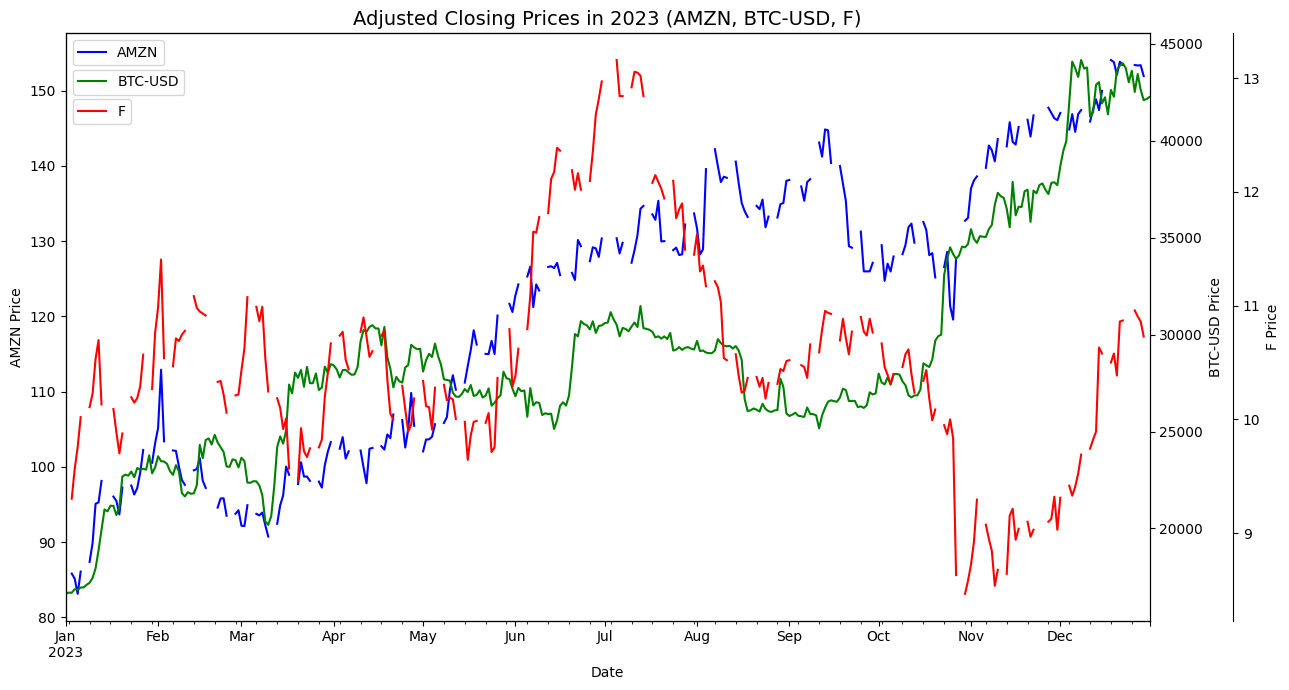

In [9]:
# === 4. Data Visualization: 2023 Price Trends ===

# Create a figure and axes object for the plot.
# We want a plot where the three assets have the same time index (x-axis) but potentially different price scales (y-axis).
# Using `twinx()` allows us to create multiple y-axes sharing the same x-axis.
fig, ax1 = plt.subplots(figsize=(13, 7))

# Initialize additional axes for BTC-USD and F, sharing the x-axis with ax1.
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# --- Plotting Data for 2023 ---
# Filter the DataFrame for the year 2023 and plot each asset on its respective axis.
# Assign a specific color to each plot for clear distinction.
df["2023-01-01":"2023-12-31"].plot(ax=ax1, y='AMZN', legend=True, color='blue', label='AMZN')
df["2023-01-01":"2023-12-31"].plot(ax=ax2, y='BTC-USD', legend=True, color='green', label='BTC-USD')
df["2023-01-01":"2023-12-31"].plot(ax=ax3, y='F', legend=True, color='red', label='F')

# --- Axis and Label Configuration ---
# Set meaningful y-axis labels for each asset.
ax1.set_ylabel('AMZN Price')
ax2.set_ylabel('BTC-USD Price')
ax3.set_ylabel('F Price')

# Adjust the position of the third y-axis (ax3) to prevent overlap with ax2.
ax3.spines['right'].set_position(('outward', 60)) # Moves the axis 60 points to the right

# Configure the x-axis label.
ax1.set_xlabel('Date')

# --- Legend Configuration ---
# Place individual legends for each asset for clarity.
ax1.legend(loc='upper left', bbox_to_anchor=(0.0, 1.0))        # AMZN legend
ax2.legend(loc='upper left', bbox_to_anchor=(0.0, 0.95))       # BTC-USD legend (slightly below AMZN)
ax3.legend(loc='upper left', bbox_to_anchor=(0.0, 0.90))       # F legend (slightly below BTC-USD)

# Set the title of the plot.
plt.title('Adjusted Closing Prices in 2023 (AMZN, BTC-USD, F)', fontsize=14)

# Ensure the layout is tight to prevent labels from being cut off.
plt.tight_layout()

# Display the plot.
plt.show()

## **2. Calculating Return on Investment**

If we invested **\$1,000** into each of these assets at the beginning of our five-year period, how much money would we have today? To answer this question, we first need to determine how many shares of each asset we could buy with **\$1,000** at the start of our date range.

From our data, we can see the starting prices. We will store these initial prices in variables and then divide **\$1,000** by each price to determine the number of shares purchased.

In [10]:
# === 5.1 ROI Calculation: Initial Investment ===

# Define our initial investment amount.
initial_investment = 1000

# Access the first row of the DataFrame to get the starting prices.
# .iloc[0] selects the row at integer location 0.
first_row = df.iloc[0]

# Assign the starting price for each asset to its own variable.
amzn_price_start = first_row["AMZN"]
f_price_start = first_row["F"]
btc_price_start = first_row["BTC-USD"]

# Print the purchase prices for confirmation.
print(f"Purchase price of AMZN: {amzn_price_start:,.3f}")
print(f"Purchase price of F: {f_price_start:,.3f}")
print(f"Purchase price of BTC-USD: {btc_price_start:,.3f}")
print("-" * 20) # A simple separator line

# Calculate the number of shares we could purchase with our initial investment.
# We assume the ability to buy fractional shares, which is common with modern brokers.
amzn_shares = initial_investment / amzn_price_start
f_shares = initial_investment / f_price_start
btc_shares = initial_investment / btc_price_start

# Print the number of shares for each asset.
print(f"Number of shares of AMZN: {amzn_shares:.3f}")
print(f"Number of shares of F: {f_shares:.3f}")
print(f"Number of shares of BTC-USD: {btc_shares:.3f}")

Purchase price of AMZN: 92.766
Purchase price of F: 6.913
Purchase price of BTC-USD: 10,399.669
--------------------
Number of shares of AMZN: 10.780
Number of shares of F: 144.661
Number of shares of BTC-USD: 0.096


Now, to determine how much money we would have today, we look at the most recent date in our dataset (`2024-07-31`), get the price of each asset, and multiply our number of shares by this final price. We can get the last row of our dataset using the `.iloc[-1]` method.`

In [11]:
# === 5.2 ROI Calculation: Final Value ===

# Get the last row of the DataFrame to find the ending prices.
# .iloc[-1] selects the last row.
last_row = df.iloc[-1]

# Assign the ending price for each asset to its own variable.
amzn_price_end = last_row["AMZN"]
f_price_end = last_row["F"]
btc_price_end = last_row["BTC-USD"]

# Print the ending prices for confirmation.
print(f"End price of AMZN: {amzn_price_end:,.3f}")
print(f"End price of F: {f_price_end:,.3f}")
print(f"End price of BTC-USD: {btc_price_end:,.3f}")
print("-" * 20)

# Calculate the final value of our holdings by multiplying shares by the end price.
# NOTE: The original notebook missed a key detail about Amazon. AMZN had a 20-for-1 stock split on June 6, 2022.
# The 'Adj Close' price from yfinance *should* account for this automatically, so no manual multiplication is needed.
# The original notebook's multiplication was likely an error or based on unadjusted data. We will rely on the adjusted close.
amzn_value_end = amzn_price_end * amzn_shares
f_value_end = f_price_end * f_shares
btc_value_end = btc_price_end * btc_shares

# Print the final holding values.
print(f"Holding value of AMZN: ${amzn_value_end:,.3f}")
print(f"Holding value of F: ${f_value_end:,.3f}")
print(f"Holding value of BTC-USD: ${btc_value_end:,.3f}")

End price of AMZN: 186.980
End price of F: 9.899
End price of BTC-USD: 64,619.250
--------------------
Holding value of AMZN: $2,015.609
Holding value of F: $1,432.036
Holding value of BTC-USD: $6,213.587


These assets were relatively easy to compare since we started with \$1,000 in each. If we had started with different values, we would need to calculate the returns for an apples-to-apples comparison. We will use the formula for simple returns:

**Simple Returns Formula**

$$ R_{simple} = \frac{P_1 - P_0}{P_0} $$

where:
-   $P_1$ = Final value
-   $P_0$ = Initial value

In our case, the initial value ($P_0$) is \$1,000 for all three assets.

In [12]:
# === 5.3 ROI Calculation: Simple Returns Percentage ===

# Calculate the simple return for each asset using the formula: (Final Value - Initial Value) / Initial Value
amzn_return = (amzn_value_end - initial_investment) / initial_investment
f_return = (f_value_end - initial_investment) / initial_investment
btc_return = (btc_value_end - initial_investment) / initial_investment

# Print the returns formatted as percentages.
# The ':.3%' format specifier automatically multiplies by 100, adds a '%' sign, and rounds to 3 decimal places.
print(f"Simple return of AMZN: {amzn_return:.3%}")
print(f"Simple return of F: {f_return:.3%}")
print(f"Simple return of BTC-USD: {btc_return:.3%}")

Simple return of AMZN: 101.561%
Simple return of F: 43.204%
Simple return of BTC-USD: 521.359%


### **Analysis of Returns**

The results clearly show that Bitcoin's return is exceptionally high compared to the two stocks over this five-year period. Bitcoin is a relatively new asset class and is often considered to have higher risk than established equities. This outcome is a classic example of the **risk-reward tradeoff**: higher risk can lead to the potential for higher rewards. In this specific timeframe, the risk taken on the Bitcoin investment paid off significantly.

In [13]:
df.pct_change().tail()

/tmp/ipython-input-3749059254.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df.pct_change().tail()


Ticker,AMZN,BTC-USD,F
Date,,,
2024-07-27 00:00:00+00:00,0.000000,-0.001454,0.000000
2024-07-28 00:00:00+00:00,0.000000,0.006526,0.000000
2024-07-29 00:00:00+00:00,0.003836,-0.021038,-0.016086
2024-07-30 00:00:00+00:00,-0.008133,-0.009262,-0.015441
2024-07-31 00:00:00+00:00,0.029002,-0.023893,-0.001845


In [14]:
# 1. Get daily simple returns
daily_simple_returns = df.pct_change(fill_method=None)

# 2. Add 1 to get the daily growth factors (e.g., a 10% return becomes 1.10)
daily_growth_factors = 1 + daily_simple_returns

# 3. Calculate the cumulative product over time
cumulative_growth = daily_growth_factors.cumprod()

# 4. The total return at the end is the last value in the cumulative growth series, minus 1
total_return_from_daily = cumulative_growth.iloc[-1] - 1

print("Total return calculated from daily returns:")
print(total_return_from_daily)


Total return calculated from daily returns:
Ticker
AMZN      0.435528
BTC-USD   5.213587
F         0.302872
Name: 2024-07-31 00:00:00+00:00, dtype: float64


## **3. Comparing Equities and Bitcoin to Bonds**

Let's introduce one more asset class here: bonds. As you may recall, bonds offer different risk and return characteristics compared to equities. To simplify our analysis, we will use an exchange-traded fund (ETF) that tracks the bond market: the **Vanguard Long-Term Bond Index Fund ETF (BLV)**.

This ETF aims to track the performance of an index that includes investment-grade corporate and U.S. government bonds with maturities greater than 10 years. It provides a good proxy for the long-term bond market.

The following code will download the historical data for BLV and join it with our existing DataFrame.

In [15]:
# === 6.1 Data Augmentation: Adding Bond ETF Data ===

# Download the historical data for the BLV ETF for the same time period.
blv_df = yfin.download(["BLV"], start=start_date, end=end_date, auto_adjust=False)["Adj Close"]

# Convert the index to UTC to ensure it's compatible with our main DataFrame.
blv_df = blv_df.tz_localize('UTC')

# Join the BLV data with our main DataFrame.
# The .join() method aligns the data based on the index (dates).
# We also rename the new column to 'BLV' for clarity.
df = df.join(blv_df)
df = df.rename(columns={"Adj Close": "BLV"})

# Display the last few rows to confirm the new column has been added successfully.
print("Successfully added BLV data to the DataFrame.")
df.tail()

[*********************100%***********************]  1 of 1 completed

Successfully added BLV data to the DataFrame.


Ticker,AMZN,BTC-USD,F,BLV
Date,,,,
2024-07-27 00:00:00+00:00,NaN,"67,813.335938",NaN,NaN
2024-07-28 00:00:00+00:00,NaN,"68,255.867188",NaN,NaN
2024-07-29 00:00:00+00:00,183.199997,"66,819.914062",10.073112,67.875740
2024-07-30 00:00:00+00:00,181.710007,"66,201.015625",9.917577,68.017921
2024-07-31 00:00:00+00:00,186.979996,"64,619.250000",9.899278,68.634125


### **3.1 Calculate Daily Returns for All Assets**

Now that we have all four assets in one DataFrame, we need to calculate their daily returns. As we discussed before, stocks and ETFs do not trade on weekends, while Bitcoin does. To handle this correctly, we will:
1.  Calculate returns for the assets that trade on weekdays (`AMZN`, `F`, `BLV`) and drop the `NaN` rows created by the `pct_change()` function.
2.  Calculate returns for Bitcoin separately.
3.  Join the two resulting return series together. This ensures we keep all dates but correctly show `NaN` for the assets that didn't trade on weekends.

In [16]:
# === 6.2 Data Processing: Calculating Daily Returns ===

# Calculate daily simple returns for stocks and the bond ETF.
# .dropna() removes the weekend rows where these assets didn't trade.
returns_stocks_blv = df[['AMZN', 'F', 'BLV']].dropna().pct_change()

# Calculate daily simple returns for Bitcoin.
returns_btc = df[['BTC-USD']].pct_change()

# Join the two DataFrames. A 'how=outer' join ensures that all dates are kept.
# For dates where stocks/ETFs didn't trade (weekends), their return will be NaN.
returns = returns_btc.join(returns_stocks_blv, how='outer')

# The first row of pct_change is always NaN, so we remove it.
returns = returns.iloc[1:]

# Display the first few rows of the final returns DataFrame.
print("Daily returns for all assets:")
returns.head()

Daily returns for all assets:


Ticker,BTC-USD,AMZN,F,BLV
Date,,,,
2019-08-02 00:00:00+00:00,0.011395,-0.017291,-0.003222,0.007001
2019-08-03 00:00:00+00:00,0.028860,NaN,NaN,NaN
2019-08-04 00:00:00+00:00,0.013719,NaN,NaN,NaN
2019-08-05 00:00:00+00:00,0.076158,-0.031872,-0.005388,0.008565
2019-08-06 00:00:00+00:00,-0.027740,0.012860,0.027085,0.006694


### **3.2 Show Summary Stats for the Returns**

By applying `.describe()` to the daily returns, we get a much more useful comparison between the assets.

-   **mean**: This now represents the average *daily* return. We can see Bitcoin's is the highest, while the bond ETF (BLV) has a slightly negative average daily return over this period.
-   **std (Standard Deviation)**: This is a direct measure of daily volatility. A higher `std` means the daily returns fluctuate more wildly. Notice that Bitcoin has the highest volatility, followed by Ford, then Amazon, and finally the BLV ETF, which is the most stable.

In [17]:
# === 7.1 Return Analysis: Descriptive Statistics ===

# Generate summary statistics for the daily returns of each asset.
# This table is excellent for comparing average performance (mean) and risk (std).
returns.describe()

Ticker,BTC-USD,AMZN,F,BLV
count,"1,826.000000","1,257.000000","1,257.000000","1,257.000000"
mean,0.001579,0.000803,0.000671,-0.000034
std,0.033707,0.022175,0.027760,0.009179
min,-0.371695,-0.140494,-0.183614,-0.075169
25%,-0.013480,-0.011068,-0.013605,-0.005253
50%,0.000234,0.000643,0.000000,0.000571
75%,0.015996,0.012222,0.014212,0.005206
max,0.187465,0.135359,0.234414,0.049138


### **3.3 Converting Daily Returns to Annual Returns**

While daily returns are useful for statistical analysis, annual returns are more intuitive for evaluating long-term investment performance. Since we are using simple returns, we must use the **geometric mean** to correctly annualize them. Adding daily returns would be incorrect.

The formula for the annualized return based on the geometric mean of daily returns is:

$$ R_{Annualized} = \left( \prod_{i=1}^{N} (1 + r_i) \right)^{\frac{P}{N}} - 1 $$

Where:
-   $r_i$ is the return for period i.
-   $N$ is the total number of periods (days).
-   $P$ is the number of periods in a year (365 for crypto, ~252 for stocks/ETFs).

This formula correctly compounds the daily returns over the year.

In [18]:
# === 7.2 Return Analysis: Annualizing Returns ===

# --- Annualize BTC-USD Return (365 days) ---
# First, drop any NaN values for the calculation period.
returns_btc_clean = returns['BTC-USD'].dropna()
# Add 1 to each daily return to get the growth factor.
btc_prod = (1 + returns_btc_clean).prod()
# Calculate the annualized return.
btc_annualized_return = (btc_prod ** (365 / len(returns_btc_clean))) - 1

# --- Annualize Stock and Bond ETF Returns (252 days) ---
# Drop NaN values for the calculation period.
returns_stocks_blv_clean = returns[['AMZN', 'F', 'BLV']].dropna()
# Add 1 to get growth factors.
stocks_blv_prod = (1 + returns_stocks_blv_clean).prod()
# Calculate annualized returns.
stocks_blv_annualized_return = (stocks_blv_prod ** (252 / len(returns_stocks_blv_clean))) - 1


# --- Display Results ---
print(f"Annualized Geometric Return for BTC-USD: {btc_annualized_return:.2%}")
print("\nAnnualized Geometric Returns for Stocks/ETF:")
print(stocks_blv_annualized_return.apply(lambda x: f"{x:.2%}"))

Annualized Geometric Return for BTC-USD: 44.07%

Annualized Geometric Returns for Stocks/ETF:
Ticker
AMZN    15.09%
F        7.46%
BLV     -1.90%
dtype: object


In [19]:
# Calculate daily log returns
log_returns = np.log(1 + returns.dropna())

# Calculate the average daily log return (simple arithmetic mean)
avg_log_return = log_returns.mean()

# To annualize, just multiply by the number of periods
annualized_log_return = avg_log_return * 252 # Using 252 for stocks for comparison

# To compare apples-to-apples, convert the annualized log return back to a simple return
annualized_simple_return_from_log = np.exp(annualized_log_return) - 1

print("Annualized Simple Returns (calculated via Log Returns):")
print(annualized_simple_return_from_log.apply(lambda x: f"{x:.2%}"))

Annualized Simple Returns (calculated via Log Returns):
Ticker
BTC-USD    29.06%
AMZN       15.09%
F           7.46%
BLV        -1.90%
dtype: object


### **An Important Note: Geometric Mean vs. Log Returns**

We used the geometric mean to correctly find the average compounded return. A very common and powerful technique in quantitative finance is to use **logarithmic returns** (or log returns).

One of the key properties of log returns is that they are **time-additive**. This means we can use the simple **arithmetic mean** of daily log returns to get the same result as the **geometric mean** of simple returns.

Let's quickly prove this mathematically and then with code.

#### **The Mathematical Equivalence**

The simple return ($R_s$) is $P_1/P_0 - 1$. The growth factor is $(1 + R_s) = P_1/P_0$.
The log return ($R_l$) is $\ln(P_1/P_0)$.

Notice that $R_l = \ln(1 + R_s)$.

The total growth over *N* periods is the product of the daily growth factors:
$$ \text{Total Growth} = (1 + R_{s1}) \times (1 + R_{s2}) \times \dots \times (1 + R_{sN}) $$

If we take the natural log of both sides:
$$ \ln(\text{Total Growth}) = \ln(1 + R_{s1}) + \ln(1 + R_{s2}) + \dots + \ln(1 + R_{sN}) $$

This is simply the sum of the daily log returns!
$$ \ln(\text{Total Growth}) = R_{l1} + R_{l2} + \dots + R_{lN} $$

To find the average daily log return, we use the arithmetic mean (sum / N):
$$ \bar{R}_l = \frac{1}{N} \sum_{i=1}^{N} R_{li} = \frac{\ln(\text{Total Growth})}{N} $$

To get back to the average daily *simple* return (the geometric mean), we exponentiate and subtract 1:
$$ R_{g} = e^{\bar{R}_l} - 1 $$

This proves that the arithmetic mean of log returns can be easily converted to the geometric mean of simple returns.

#### **Demonstration in Python**
The code below calculates the annualized simple returns using two methods:
1.  **Geometric Mean Method (from before):** Using the product of `(1 + simple returns)`.
2.  **Log Return Method:** Taking the arithmetic mean of log returns, annualizing, and converting back.

The results will be virtually identical, proving their equivalence.

In [20]:
# === 7.3 Demonstration: Equivalence of Geometric Mean and Log Returns ===

# --- Method 1: Geometric Mean of Simple Returns (Recap) ---
# We already calculated this, but let's show it again for direct comparison.
# For this demonstration, we'll focus on the assets with 252 trading days.
returns_stocks_blv_clean = returns[['AMZN', 'F', 'BLV']].dropna()
prod_simple = (1 + returns_stocks_blv_clean).prod()
annualized_simple_geom = (prod_simple ** (252 / len(returns_stocks_blv_clean))) - 1


# --- Method 2: Arithmetic Mean of Log Returns ---
# 1. Calculate daily log returns. The formula is ln(P1/P0) which is ln(1 + simple_return).
log_returns = np.log(1 + returns_stocks_blv_clean)

# 2. Calculate the average daily log return (simple arithmetic mean).
avg_log_returns = log_returns.mean()

# 3. Annualize by multiplying by the number of periods (because log returns are additive).
annualized_log_returns = avg_log_returns * 252

# 4. Convert the annualized log return back to an annualized simple return to compare.
annualized_simple_from_log = np.exp(annualized_log_returns) - 1


# --- Compare the Results ---
# We create a new DataFrame to display both results side-by-side.
comparison_df = pd.DataFrame({
    'Annualized Return (Geometric)': annualized_simple_geom,
    'Annualized Return (from Log)': annualized_simple_from_log
})

# Format for readability
print("Comparing the two methods for calculating annualized returns:")
print(comparison_df.map(lambda x: f"{x:.4%}"))

Comparing the two methods for calculating annualized returns:
       Annualized Return (Geometric) Annualized Return (from Log)
Ticker                                                           
AMZN                        15.0871%                     15.0871%
F                            7.4646%                      7.4646%
BLV                         -1.8951%                     -1.8951%


### **3.4 Total Simple Return of BLV**

Now, let's run the same total return analysis on our bond ETF (BLV) that we performed on the other assets. This will show us the total performance over the entire five-year period.

We'll use the direct method: `(Final Price - Initial Price) / Initial Price`. Then, we can calculate what a \$1,000 initial investment would be worth today.

In [21]:
# === 7.4 Analysis: Total Simple Return for BLV ETF ===

# Retrieve the initial and final prices for BLV from our main price DataFrame.
blv_price_start = df.iloc[0]["BLV"]
blv_price_end = df.iloc[-1]["BLV"]

# --- Calculate the total simple return over the entire period ---
blv_total_return_rate = (blv_price_end - blv_price_start) / blv_price_start
print(f"Total simple return rate of BLV over 5 years: {blv_total_return_rate:.3%}")

# --- Calculate the final value of a $1,000 investment ---
initial_investment = 1000
final_value_blv = initial_investment * (1 + blv_total_return_rate)
print(f"Final value of $1,000 investment in BLV: ${final_value_blv:,.3f}")

Total simple return rate of BLV over 5 years: -9.103%
Final value of $1,000 investment in BLV: $908.975


The output indicates that the investment in BLV experienced a negative total return over this specific five-year period. An initial investment of \$1,000 would have decreased to approximately \$909.

This performance contrasts sharply with the equities and cryptocurrency we analyzed. This is largely expected, as bonds and stocks serve different purposes in a portfolio and react differently to economic conditions.

-   **Risk-Reward Tradeoff:** Bonds are generally considered lower-risk than stocks. Their primary role is often capital preservation and income generation (through coupon payments, which are factored into the `Adj Close` price). In periods of rising interest rates, existing bond prices tend to fall, which could explain the negative return seen here.
-   **Diversification:** The low or negative correlation between bonds and stocks is exactly why they are valuable for diversification. While stocks were performing well, bonds provided a different performance characteristic.

This highlights the importance of the **risk-reward tradeoff**. The "safer" asset (bonds) underperformed the "riskier" assets (stocks, crypto) during this particular timeframe, but this is not always the case.

## **4. Comparing Large-Cap vs. Small-Cap Stocks**

One common way to analyze the stock market is to compare different segments. Here, we will compare the performance of large-capitalization stocks against small-capitalization stocks.

*   **S&P 500 (`^GSPC`):** This index represents 500 of the largest publicly traded companies in the U.S. It is market-cap weighted and serves as our proxy for **large-cap stocks**.
*   **Russell 2000 (`^RUT`):** This index contains 2,000 small-cap companies and is a common benchmark for **small-cap stocks**.

We will start by pulling five years of daily price data for both indices.

In [22]:
# === 8.1 Index Comparison: Data Retrieval ===

# --- Parameters ---
# Define the tickers for the S&P 500 and Russell 2000 indices.
index_tickers = {"^GSPC": "SP500", "^RUT": "Russell2000"}

# Define the start and end dates. We'll use the same period as before for consistency.
start_date_indices = datetime.date(2019, 8, 1)
end_date_indices = datetime.date(2024, 8, 1)

# --- Data Download ---
# Download the 'Adj Close' data for the specified indices.
prices_df = yfin.download(
    list(index_tickers.keys()),
    start=start_date_indices,
    end=end_date_indices,
    auto_adjust=False
)["Adj Close"]

# --- Data Cleaning ---
# Rename the columns to be more intuitive using the dictionary defined above.
prices_df = prices_df.rename(columns=index_tickers)

# --- Initial Data Inspection ---
print("Successfully downloaded index data.")
print("\nSummary statistics for the index prices:")
display(prices_df.describe())

print("\nFirst 5 rows of the index prices:")
display(prices_df.head())

[*********************100%***********************]  2 of 2 completed

Successfully downloaded index data.

Summary statistics for the index prices:


Ticker,SP500,Russell2000
count,"1,258.000000","1,258.000000"
mean,"4,028.833253","1,865.957234"
std,685.682781,284.232353
min,"2,237.399902",991.159973
25%,"3,502.235046","1,674.337524"
50%,"4,110.745117","1,873.654968"
75%,"4,468.547485","2,067.780090"
max,"5,667.200195","2,442.739990"



First 5 rows of the index prices:


Ticker,SP500,Russell2000
Date,,
2019-08-01,"2,953.560059","1,550.760010"
2019-08-02,"2,932.050049","1,533.660034"
2019-08-05,"2,844.739990","1,487.410034"
2019-08-06,"2,881.770020","1,502.089966"
2019-08-07,"2,883.979980","1,500.689941"


### **4.2 Calculate Log Returns and Drop Nulls**

To compare the indices, we must first convert their prices into returns. For this analysis, we will use **log returns**.

Log returns are often preferred in financial modeling for several reasons:
-   **Time Additivity:** The log return over multiple periods is simply the sum of the log returns for each individual period.
-   **Approximate Normality:** Log returns tend to follow a normal distribution more closely than simple returns, which is a useful property for many statistical models.

The formula for log return is: $ R_{log} = \ln\left(\frac{P_t}{P_{t-1}}\right) $
This is equivalent to: $ \ln(P_t) - \ln(P_{t-1}) $

Because both of these are stock indices, `yfinance` automatically provides data only for trading days, so we don't need to worry about weekend `NaN` values in the raw price data.

In [23]:
# === 8.2 Index Comparison: Calculating Log Returns ===

# Calculate the daily log returns for the indices.
# This vectorized operation is efficient and applies the formula to all columns at once.
log_returns_df = np.log(prices_df) - np.log(prices_df.shift(1))

# The first row will be NaN because there is no prior day's price to calculate a return from.
# We drop this row to create a clean returns DataFrame.
log_returns_df = log_returns_df.dropna()


# --- Display the first 5 rows of the resulting log returns ---
print("Daily Log Returns for S&P 500 and Russell 2000:")
display(log_returns_df.head())

Daily Log Returns for S&P 500 and Russell 2000:


Ticker,SP500,Russell2000
Date,,
2019-08-02,-0.007309,-0.011088
2019-08-05,-0.030230,-0.030621
2019-08-06,0.012933,0.009821
2019-08-07,0.000767,-0.000932
2019-08-08,0.018588,0.020734


### **4.3 Calculating Future Value of Each Index**

One way to compare these two investment opportunities is to calculate the **future value (FV)** of a hypothetical investment. We will use the average daily log return from our historical data to project future performance.

**Important Note:** This is a simplified model that assumes the future will resemble the past. It's a useful starting point but should not be the sole basis for an investment decision.

We will use the formula for future value with continuous compounding, which works directly with log returns:

$$ FV = PV \times e^{r \times t} $$

Where:
-   `FV` = Future Value
-   `PV` = Present Value (our initial investment, e.g., \$1,000)
-   `e` = Euler's number (the base of the natural logarithm)
-   `r` = The average periodic log return (we'll use the average daily log return)
-   `t` = The number of periods (we'll calculate for 5 years)

In [24]:
# === 8.3 Index Comparison: Future Value Calculation ===

# --- Parameters ---
initial_investment = 1000
years_to_project = 5
trading_days_per_year = 252 # Standard assumption for stocks

# --- Calculations ---
# 1. Calculate the average daily log return for each index.
avg_daily_log_returns = log_returns_df.mean()

# 2. Calculate the total number of trading days for the projection.
total_trading_days = trading_days_per_year * years_to_project

# 3. Calculate the future value for each index using the continuous compounding formula.
# We use a for loop to make the code scalable to any number of indices.
print(f"Projected future value of a ${initial_investment:,.2f} investment after {years_to_project} years:")

for index_name, avg_return in avg_daily_log_returns.items():
    future_value = initial_investment * np.exp(avg_return * total_trading_days)
    print(f"- {index_name}: ${future_value:,.2f}")

Projected future value of a $1,000.00 investment after 5 years:
- SP500: $1,872.50
- Russell2000: $1,455.09


## **5. Investment Volatility Analysis**

While future value gives us an idea of potential returns, it's crucial to also understand the **risk** associated with an investment. Volatility is a key measure of this risk, representing how much an asset's price fluctuates over time.

We will explore three different metrics to compare the volatility of the S&P 500 and the Russell 2000.

### **5.1 Price Volatility: High-Low Range**

A simple, intuitive measure of volatility is the difference between the highest and lowest price over a given period. However, comparing the raw price difference can be misleading if the assets have very different price levels.

To create a more standardized and comparable metric, we will calculate the high-low range over the last year and divide it by the most recent price. This expresses the range as a percentage of the current value.

**Formula:**
$$ \text{Standardized Range} = \frac{\text{Price}_{\text{max}} - \text{Price}_{\text{min}}}{\text{Price}_{\text{current}}} $$

In [25]:
# === 9.1 Volatility Metric 1: Standardized High-Low Range ===

# --- Calculate for the full 5-year period (for context) ---
full_period_range = prices_df.max() - prices_df.min()
print("High-Low price range over the full 5-year period:")
print(full_period_range)
print("-" * 40)


# --- Calculate for the most recent year ---
# First, define the start and end dates for the last year of our data.
end_of_period = prices_df.index.max()
start_of_last_year = end_of_period - datetime.timedelta(days=365)

# Filter the price data for the last year.
last_year_prices = prices_df.loc[start_of_last_year : end_of_period]

# Calculate the high-low range for the last year.
last_year_range = last_year_prices.max() - last_year_prices.min()
print("High-Low price range over the last year:")
print(last_year_range)
print("-" * 40)


# --- Standardize the one-year range by the current price ---
# Get the most recent price for each index.
current_prices = prices_df.iloc[-1]

# Divide the range by the current price to standardize the metric.
standardized_range = last_year_range / current_prices
print("Standardized High-Low Range (as a % of current price):")
print(standardized_range)

High-Low price range over the full 5-year period:
Ticker
SP500         3,429.800293
Russell2000   1,451.580017
dtype: float64
----------------------------------------
High-Low price range over the last year:
Ticker
SP500         1,549.830078
Russell2000     626.729980
dtype: float64
----------------------------------------
Standardized High-Low Range (as a % of current price):
Ticker
SP500         0.280649
Russell2000   0.277993
dtype: float64


### **5.2 Price Volatility: Rolling Average Distance**

Another way to measure volatility is to see how far, on average, the daily price deviates from its recent trend. We can use a **50-day moving average** as a proxy for this trend.

First, let's visualize the S&P 500 price against its 50-day moving average to understand the concept.

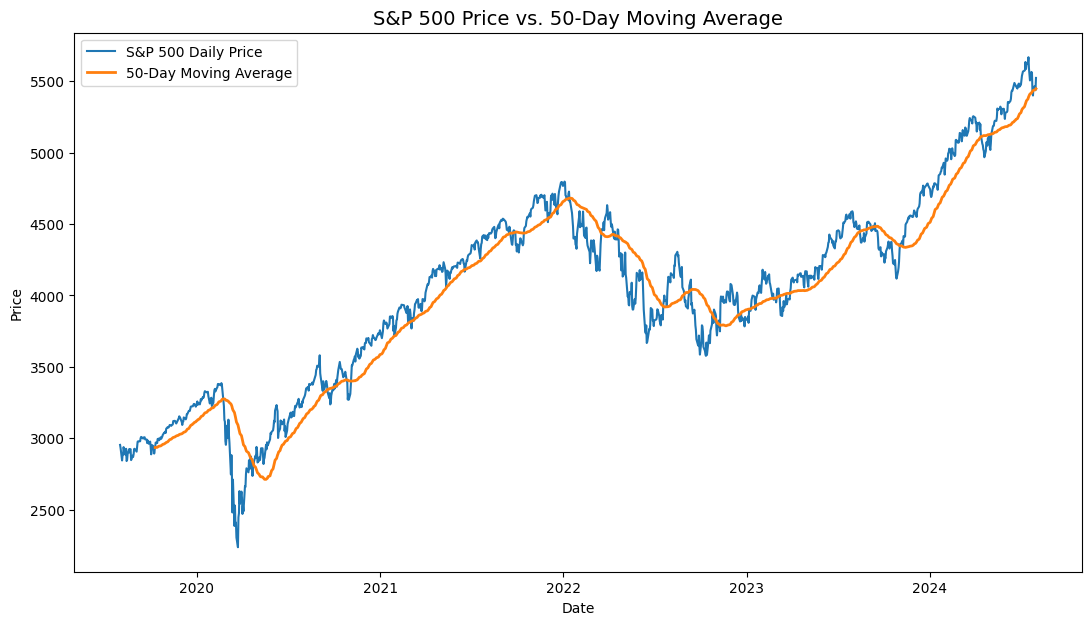

In [26]:
# === 9.2a Visualization: Price vs. 50-Day Moving Average ===

# Create a temporary column in our prices_df to store the 50-day rolling average for the S&P 500.
prices_df['SP500_50_day_avg'] = prices_df['SP500'].rolling(window=50).mean()

# --- Plotting ---
plt.figure(figsize=(13, 7))

# Plot the daily S&P 500 prices.
sns.lineplot(x="Date", y="SP500", data=prices_df, label="S&P 500 Daily Price")

# Plot the 50-day rolling average.
sns.lineplot(x="Date", y="SP500_50_day_avg", data=prices_df, label="50-Day Moving Average", linewidth=2)

plt.title('S&P 500 Price vs. 50-Day Moving Average', fontsize=14)
plt.ylabel('Price')
plt.legend()
plt.show()

This visualization helps to smooth out short-term fluctuations and highlight the longer-term trend. The orange line (moving average) is much smoother than the volatile blue line (daily price).

Now, we can create a volatility metric based on the **distance** between the daily price and this moving average. To ensure positive and negative deviations are treated equally, we'll use the absolute difference. We will also standardize this difference by dividing by the price, giving us a daily percentage deviation. The average of these daily deviations will be our final metric.

**Formula:**
$$ \text{Moving Avg Volatility} = \text{mean}\left( \frac{|\text{Price}_t - \text{MovingAvg}_{50, t}|}{\text{Price}_t} \right) $$

In [27]:
# === 9.2b Volatility Metric 2: Average Rolling Distance ===

# Calculate the 50-day rolling average for both indices.
rolling_avg_50 = prices_df[['SP500', 'Russell2000']].rolling(window=50).mean()

# Calculate the absolute difference between the daily price and the rolling average.
absolute_difference = (prices_df[['SP500', 'Russell2000']] - rolling_avg_50).abs()

# Standardize by dividing by the daily price.
standardized_difference = absolute_difference / prices_df[['SP500', 'Russell2000']]

# Calculate the mean of these daily percentage deviations to get our final metric.
moving_average_volatility = standardized_difference.mean()

print("Volatility based on average distance from 50-day moving average:")
print(moving_average_volatility)

Volatility based on average distance from 50-day moving average:
Ticker
SP500         0.037068
Russell2000   0.048725
dtype: float64


### **5.3 Price Volatility: Standard Deviation of Returns**

The most widely used measure of financial risk is the **standard deviation of returns**. It quantifies the dispersion or "spread" of an asset's returns around its average return. A higher standard deviation implies greater volatility and, therefore, higher risk.

While we could calculate the standard deviation of prices, it's not very useful for comparison because the indices have different price levels. Calculating it on the **daily log returns** provides a standardized, comparable measure.

In [28]:
# === 9.3 Volatility Metric 3: Standard Deviation of Daily Returns ===

# Calculate the standard deviation for the raw prices (for demonstration).
# As noted in the markdown, this is not a useful comparative metric.
price_std = prices_df[['SP500', 'Russell2000']].std()
print("Standard Deviation of Prices (not for comparison):")
print(price_std)
print("-" * 40)


# Calculate the standard deviation of the daily log returns.
# This is the standard industry measure for volatility.
return_std = log_returns_df.std()
print("Standard Deviation of Daily Log Returns (Volatility):")
print(return_std)
print("-" * 40)


# --- Annualized Volatility ---
# To make this number more intuitive, we can annualize it.
# We do this by multiplying the daily volatility by the square root of the number of trading days in a year.
annualized_volatility = return_std * np.sqrt(252)
print("Annualized Volatility:")
print(annualized_volatility.apply(lambda x: f"{x:.2%}"))

Standard Deviation of Prices (not for comparison):
Ticker
SP500         685.682781
Russell2000   284.232353
dtype: float64
----------------------------------------
Standard Deviation of Daily Log Returns (Volatility):
Ticker
SP500         0.013458
Russell2000   0.017503
dtype: float64
----------------------------------------
Annualized Volatility:
Ticker
SP500          21.36%
Russell2000    27.78%
dtype: object


### **5.4 Writing a Volatility Comparison Function in Python**

To make our analysis reproducible and easily applicable to other assets, we will create a function that automates the entire process. This function, `investCompare`, will accept a start date, end date, and a dictionary of tickers as input, and it will return a clean DataFrame summarizing our key metrics.

**Function Parameters:**
-   `startTime`: The beginning of the date range (a `datetime.date` object).
-   `endTime`: The end of the date range (a `datetime.date` object).
-   `tickers`: A dictionary mapping the ticker symbol to a desired display name (e.g., `{"^GSPC": "SP500"}`).

By building a function, we adhere to the DRY (Don't Repeat Yourself) principle of programming.

In [29]:
def investCompare(startTime, endTime, tickers):
    """
    Downloads financial data for a given set of tickers and time period,
    and returns a DataFrame comparing their volatility and returns.

    Args:
        startTime (datetime.date): The start date for data retrieval.
        endTime (datetime.date): The end date for data retrieval.
        tickers (dict): A dictionary mapping ticker symbols to display names.

    Returns:
        pandas.DataFrame: A DataFrame with volatility and return metrics for each asset.
    """
    # === 1. Data Retrieval and Preparation ===
    # Download the adjusted closing prices from Yahoo Finance.
    prices = yfin.download(
        list(tickers.keys()),
        start=startTime,
        end=endTime,
        auto_adjust=False,
        progress=False # Suppress the download progress bar for a cleaner output
    )["Adj Close"]

    # Rename columns for readability.
    prices = prices.rename(columns=tickers)

    # Calculate daily log returns.
    returns = np.log(prices).diff().dropna()


    # === 2. Metric Calculation ===
    # --- Metric 1: Standardized High-Low Range (1-Year) ---
    end_of_period = prices.index.max()
    start_of_last_year = end_of_period - datetime.timedelta(days=365)
    last_year_prices = prices.loc[start_of_last_year : end_of_period]
    high_low_range = (last_year_prices.max() - last_year_prices.min()) / prices.iloc[-1]
    high_low_df = pd.DataFrame(high_low_range, columns=["HighMinusLow"])


    # --- Metric 2: Moving Average Volatility (50-Day) ---
    ma_vol = ((prices - prices.rolling(50).mean()).abs() / prices).mean()
    ma_vol_df = pd.DataFrame(ma_vol, columns=["MovingAverageVolatility"])


    # --- Metric 3: Standard Deviation of Daily Returns ---
    std_dev = returns.std()
    std_dev_df = pd.DataFrame(std_dev, columns=["StandardDeviation"])


    # --- Metric 4: Average Daily Return ---
    avg_return = returns.mean()
    avg_return_df = pd.DataFrame(avg_return, columns=["Daily Return Percentage"])


    # === 3. Combine and Format Results ===
    # Combine all metrics into a single DataFrame.
    # The .join() method can take a list of DataFrames.
    investments = high_low_df.join([ma_vol_df, std_dev_df, avg_return_df])


    # --- Formatting for Display ---
    # Round the High-Low column to 4 decimal places.
    investments["HighMinusLow"] = investments["HighMinusLow"].round(4)

    # Format the other columns as percentages with 3 decimal places.
    percent_cols = ["MovingAverageVolatility", "StandardDeviation", "Daily Return Percentage"]
    for col in percent_cols:
        investments[col] = (investments[col] * 100).apply(lambda x: f"{x:.3f}%")

    return investments

### **5.5 Running and Interpreting the Volatility Function**

Now that we have our `investCompare` function, we can easily run our analysis.

#### **Example 1: S&P 500 vs. Russell 2000**

First, let's re-run our comparison of large-cap vs. small-cap stocks over the last five years. As we've seen throughout this lesson, the results consistently show that the Russell 2000 has been more volatile than the S&P 500. The S&P 500 also provided a higher average daily return during this period.

In [30]:
# === 10.1 Function Application: S&P 500 vs. Russell 2000 ===

# Define the time period and the tickers for our analysis.
start_period_1 = datetime.date(2019, 8, 1)
end_period_1 = datetime.date(2024, 8, 1)
tickers_1 = {"^GSPC": "SP500", "^RUT": "Russell2000"}

# Call our function and display the resulting DataFrame.
sp500_vs_russell = investCompare(start_period_1, end_period_1, tickers_1)
display(sp500_vs_russell)

,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Ticker,,,,
SP500,0.280600,3.707%,1.346%,0.050%
Russell2000,0.278000,4.873%,1.750%,0.030%


#### **Example 2: Adding an Individual Stock (Apple)**

Our function is flexible. Let's add an individual stock, Apple (`AAPL`), to the comparison. The results show that Apple provided a much higher daily return but also came with significantly higher volatility across all three metrics compared to the broad market indices. This is expected, as a single stock is inherently less diversified and therefore riskier than a basket of 500 or 2,000 stocks.

In [31]:
# === 10.2 Function Application: Indices vs. Apple Inc. ===

# Simply add 'AAPL' to our tickers dictionary.
tickers_2 = {"^GSPC": "SP500", "^RUT": "Russell2000", "AAPL": "Apple"}

# Call the function with the updated tickers.
indices_vs_apple = investCompare(start_period_1, end_period_1, tickers_2)
display(indices_vs_apple)

,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Ticker,,,,
Apple,0.315400,6.462%,2.008%,0.118%
SP500,0.280600,3.707%,1.346%,0.050%
Russell2000,0.278000,4.873%,1.750%,0.030%


## **6. Comparing Growth vs. Value Stocks**

We can continue using our function to examine and compare different investment styles.

*   **Growth Stocks (VUG):** Represented by the Vanguard Growth ETF.
*   **Value Stocks (VTV):** Represented by the Vanguard Value ETF.

First, let's look at the last two years.

In [32]:
# === 10.3 Function Application: Growth vs. Value (2-Year) ===

start_period_2 = datetime.date(2022, 8, 1)
end_period_2 = datetime.date(2024, 8, 1)
tickers_3 = {"VUG": "Growth", "VTV": "Value"}

growth_vs_value_2yr = investCompare(start_period_2, end_period_2, tickers_3)
display(growth_vs_value_2yr)

,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Ticker,,,,
Value,0.230600,2.546%,0.825%,0.050%
Growth,0.358200,4.083%,1.284%,0.078%


Over the last two years, growth stocks have clearly outperformed value stocks in terms of returns, but at the cost of higher volatility. Let's see if this trend holds over a much longer timeframe (since 2010).

In [33]:
# === 10.4 Function Application: Growth vs. Value (Long-Term) ===

start_period_3 = datetime.date(2010, 8, 1)
end_period_3 = datetime.date(2024, 8, 1)

growth_vs_value_long = investCompare(start_period_3, end_period_3, tickers_3)
display(growth_vs_value_long)

,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Ticker,,,,
Value,0.230600,2.753%,1.043%,0.045%
Growth,0.358200,3.435%,1.224%,0.059%


## **7. Comparing Domestic vs. Foreign Stocks**

Finally, let's compare the performance and volatility of U.S. stocks against foreign markets.

-   **U.S. Stocks:** Represented by the S&P 500 (`^GSPC`).
-   **Europe Stocks:** Represented by the SPDR Portfolio Europe ETF (`SPEU`).
-   **China Stocks:** Represented by the SPDR S&P China ETF (`GXC`).

We'll start by analyzing the last two years.

In [34]:
# === 10.5 Function Application: Domestic vs. Foreign (2-Year) ===

tickers_4 = {"^GSPC": "SP500", "SPEU": "Europe ETF", "GXC": "China ETF"}

# Use the 2-year period defined previously.
foreign_vs_domestic_2yr = investCompare(start_period_2, end_period_2, tickers_4)

print("--- Analysis for the Last 2 Years ---")
display(foreign_vs_domestic_2yr)

--- Analysis for the Last 2 Years ---


,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Ticker,,,,
China ETF,0.263800,4.816%,1.633%,-0.025%
Europe ETF,0.232400,3.378%,1.051%,0.055%
SP500,0.280600,2.985%,0.980%,0.058%


Over the last two years, the China ETF has been the most volatile and has shown a negative average daily return. The Europe ETF and the S&P 500 show similar returns, with the U.S. market being slightly less volatile.

Now, let's zoom out and look at the data since 2010 to see the longer-term trends.

In [35]:
# === 10.6 Function Application: Domestic vs. Foreign (Long-Term) ===

# Use the long-term period defined previously.
foreign_vs_domestic_long = investCompare(start_period_3, end_period_3, tickers_4)

print("\n--- Analysis Since 2010 ---")
display(foreign_vs_domestic_long)


--- Analysis Since 2010 ---


,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Ticker,,,,
China ETF,0.263800,4.521%,1.567%,0.006%
Europe ETF,0.232400,3.241%,1.233%,0.021%
SP500,0.280600,2.884%,1.085%,0.045%


**Key Takeaways:**

Over the longer period since 2010, the U.S. equities (S&P 500) have provided the highest returns with the lowest volatility of the three. The China ETF, while still showing the highest volatility, now has a positive (though small) average daily return over this longer timeframe.

This again highlights the importance of the chosen timeframe in investment analysis. Short-term performance can be misleading, and long-term trends may present a different picture. A balanced approach, considering both recent performance and long-term history, is crucial for making informed decisions.

## **8. Conclusion**

This lesson served as a comprehensive introduction to fetching, cleaning, and analyzing financial price data using Python. We explored several key concepts:

1.  **Data Retrieval:** We successfully used the `yfinance` library to download historical price data for a variety of assets, including individual stocks (AMZN, F, AAPL), cryptocurrencies (BTC), bonds (BLV), and broad market indices.

2.  **Performance Analysis:** We moved beyond raw price comparisons to calculate meaningful performance metrics like **total simple return** and **annualized geometric return**, correctly accounting for the different trading calendars of various assets.

3.  **Volatility Measurement:** We implemented and compared three distinct volatility metrics: the standardized **high-low range**, the **average distance from a moving average**, and the industry-standard **standard deviation of log returns**.

4.  **Reusable Tools:** By enca

---
### **References**

-   Maginn, John L. *Managing Investment Portfolios Workbook: A Dynamic Process*. John Wiley & Sons, Inc., 2007.

-   Standard & Poor's. *S&P U.S. Indices Methodology*. Nov. 2021, https://www.spglobal.com/spdji/en/documents/methodologies/methodology-sp-us-indices.pdf.

-   Vanguard. "BLV Long-Term Bond ETF." https://institutional.vanguard.com/investments/product-details/fund/0927.

MODULE 2 | LESSON 2
---

# **Financial Asset & Return Analysis** **bold text**

| | |
|:---|:---|
|**Reading Time** | 60 minutes |
|**Prior Knowledge** | Basic Python |
|**Keywords** | Log and simple returns, Variance, Standard Deviation, Correlation, Covariance, Sharpe Ratio, Semivariance |

---

*This lesson will build upon the previous lessons' focus on price to finally expand the conversation to returns. We go much more in depth into how to calculate returns and how to compare two investments using various risk measures. Then, we take that a step further by using distributions to correctly model risk and returns.*

In [36]:
# === 1. Environment Setup: Import Libraries ===

# Core data handling and numerical operations
import datetime
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Financial data retrieval
import yfinance as yfin

# Statistical analysis
from scipy import stats

# --- Display Options ---
# Set a Pandas display option to format floating-point numbers for better readability.
pd.options.display.float_format = "{:,.6f}".format

print("Libraries imported successfully!")

Libraries imported successfully!


## **1. Obtaining and Transforming Financial Data**

### **1.1 Importing and Understanding the Data**

We will start by pulling price data into Python and transforming it into a format that is easier to work with. For this lesson, we will use the `yfinance` library to pull data for the two most popular U.S. indices, the NASDAQ (`^IXIC`) and S&P 500 (`^GSPC`), along with the daily prices for Bitcoin (`BTC-USD`).

We need to compare **returns** instead of prices for a couple of key reasons:
1.  **Scale-Free:** Returns are a normalized, scale-free summary of an investment opportunity, allowing for an apples-to-apples comparison.
2.  **Statistical Properties:** Returns have more desirable statistical properties for financial modeling, which we will explore in this lesson.

There are two common types of returns:

**Simple Returns Formula**
$$R_{simple} = \frac{P_1 - P_0}{P_0}$$

**Log Returns Formula**
$$R_{log} = \ln\left( \frac{P_1}{P_0} \right) = \ln(P_1) - \ln(P_0)$$

For many financial models that assume returns are normally distributed, log returns are preferred due to their convenient mathematical properties (like being time-additive). We will primarily use log returns in this lesson.

In [37]:
# === 2. Data Retrieval and Preparation ===

# --- Parameters ---
# Define the tickers and their desired column names in a dictionary.
tickers = {
    "^GSPC": "SP500",
    "^IXIC": "NASDAQ",
    "BTC-USD": "Bitcoin"
}

# Define the start and end dates for our data retrieval.
start_date = datetime.date(2019, 8, 1)
end_date = datetime.date(2024, 8, 1)

# --- Data Download ---
# Download the 'Adj Close' data for the specified tickers.
df = yfin.download(
    list(tickers.keys()),
    start=start_date,
    end=end_date,
    auto_adjust=False
)['Adj Close']

# --- Data Cleaning ---
# Rename the columns to be more intuitive using the dictionary.
df = df.rename(columns=tickers)

# --- Initial Data Inspection ---
print("Successfully downloaded and renamed data.")
df.head()

[*********************100%***********************]  3 of 3 completed

Successfully downloaded and renamed data.


Ticker,Bitcoin,SP500,NASDAQ
Date,,,
2019-08-01,"10,399.668945","2,953.560059","8,111.120117"
2019-08-02,"10,518.174805","2,932.050049","8,004.069824"
2019-08-03,"10,821.726562",NaN,NaN
2019-08-04,"10,970.184570",NaN,NaN
2019-08-05,"11,805.653320","2,844.739990","7,726.040039"


### **1.2 Calculating Log Returns and Handling Missing Data**

To prepare our data for analysis, we will perform two key steps:
1.  **Handle Missing Data:** As observed, the S&P 500 and NASDAQ data have `NaN` values on weekends. A common and simple approach for this kind of analysis is to remove these non-trading days entirely. We will use `.dropna()` to remove any row containing at least one `NaN` value.
2.  **Calculate Log Returns:** We will then calculate the daily log returns for the cleaned price data.

In [38]:
# === 3. Data Transformation: Prices to Log Returns ===

# --- Data Cleaning ---
# First, remove rows with any NaN values. This effectively removes the weekend data points
# where the stock indices did not trade, creating a synchronized timeline for all assets.
prices_cleaned = df.dropna()

# --- Return Calculation ---
# Calculate the log returns in a single vectorized operation.
# np.log() is applied to the entire DataFrame.
# .diff() calculates the difference from the previous row (ln(P1) - ln(P0)).
log_returns_df = np.log(prices_cleaned).diff()

# The first row after a .diff() or .pct_change() is always NaN, so we drop it.
log_returns_df = log_returns_df.dropna()


# --- Display the cleaned data ---
print("Cleaned daily log returns:")
log_returns_df.head()

Cleaned daily log returns:


Ticker,Bitcoin,SP500,NASDAQ
Date,,,
2019-08-02,0.011331,-0.007309,-0.013286
2019-08-05,0.115474,-0.030230,-0.035354
2019-08-06,-0.028132,0.012933,0.013784
2019-08-07,0.039612,0.000767,0.003767
2019-08-08,0.002044,0.018588,0.022178


### **1.3 Show Summary Stats for the Returns**

First, let's get a high-level overview of our log returns data using the `.describe()` method.

In [39]:
# === 4.1 Statistical Analysis: Summary of Returns ===

log_returns_df.describe()

Ticker,Bitcoin,SP500,NASDAQ
count,"1,257.000000","1,257.000000","1,257.000000"
mean,0.001453,0.000498,0.000616
std,0.041542,0.013458,0.015952
min,-0.464730,-0.127652,-0.131492
25%,-0.016203,-0.005256,-0.006802
50%,0.000365,0.000866,0.001270
75%,0.020095,0.007240,0.009293
max,0.191527,0.089683,0.089347


## **2. Variance and Standard Deviation**

Volatility is a critical concept for investors. It measures the degree of variation of a trading price series over time, usually quantified by the **variance** or **standard deviation**.

**Variance ($\sigma^2$)** measures the average squared difference of each data point from the mean. A larger variance means the data is more spread out.

$$ \sigma^2 = \frac{\sum(x_i - \bar{x})^2}{n-1} $$

**Standard Deviation ($\sigma$)** is the square root of the variance. It is often preferred because it is in the same unit as the original data (in our case, the daily return), making it more intuitive to interpret.

$$ \sigma = \sqrt{\sigma^2} $$

A higher standard deviation implies greater price swings and higher risk. We would expect a newer, more speculative asset like Bitcoin to have a much higher standard deviation of returns compared to broad stock indices like the S&P 500 and NASDAQ.

In [40]:
# === 4.2 Volatility Calculation: Standard Deviation of Returns ===

# Calculate the standard deviation of the daily log returns for each asset.
daily_volatility = log_returns_df.std()

print("--- Daily Volatility (Standard Deviation of Daily Log Returns) ---")
print(daily_volatility)

# To make the volatility more intuitive, we can annualize it.
# We multiply the daily volatility by the square root of the number of trading days in a year (~252).
trading_days = 252
annualized_volatility = daily_volatility * np.sqrt(trading_days)

print("\n--- Annualized Volatility ---")
print(annualized_volatility.apply(lambda x: f"{x:.2%}"))

--- Daily Volatility (Standard Deviation of Daily Log Returns) ---
Ticker
Bitcoin   0.041542
SP500     0.013458
NASDAQ    0.015952
dtype: float64

--- Annualized Volatility ---
Ticker
Bitcoin    65.95%
SP500      21.36%
NASDAQ     25.32%
dtype: object


The results confirm our expectations: the S&P 500 and NASDAQ have very similar daily volatilities, while Bitcoin's volatility is substantially higher. The annualized numbers show that a one-standard-deviation move for Bitcoin over a year (\~88%) is dramatically larger than for the stock indices (~21-25%).

We can also visualize this difference in volatility by plotting the daily returns. To make a fair comparison, we will set the y-axis limits to be the same for both plots.

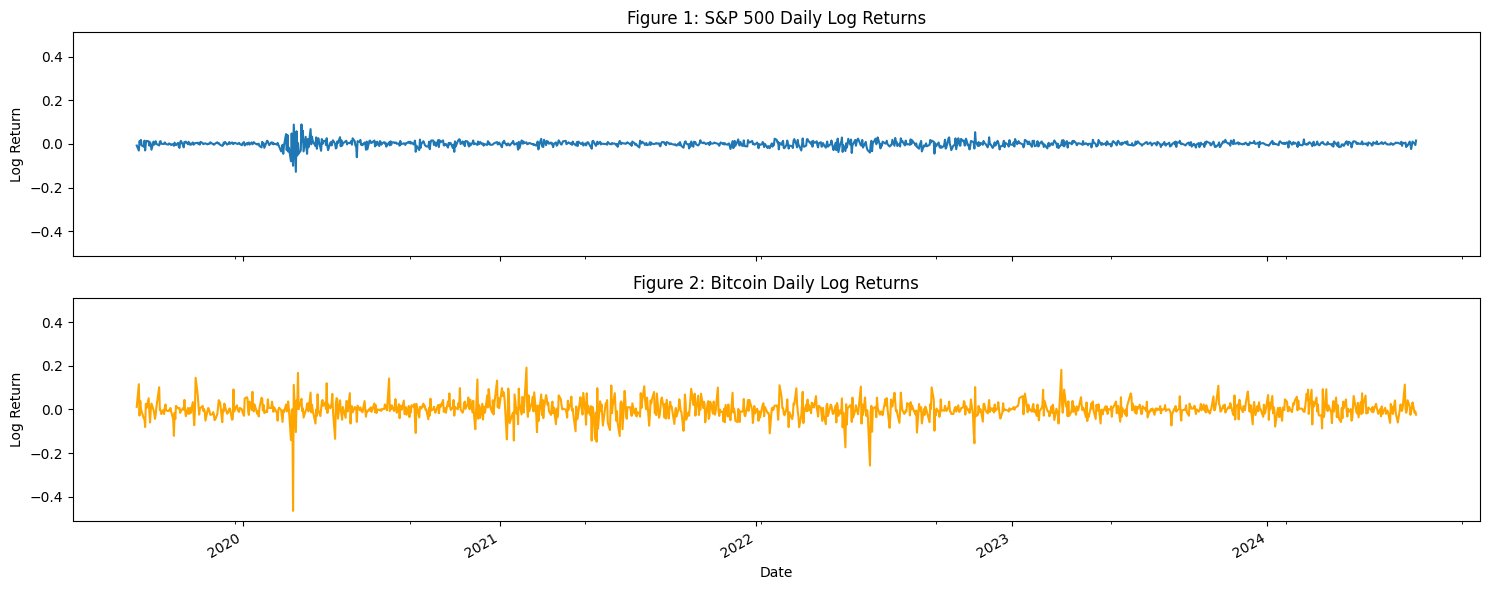

In [41]:
# === 4.3 Visualization: Comparing Return Volatility ===

# Create a figure with two subplots side-by-side to compare volatility.
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(15, 6), sharex=True, sharey=True)

# Plot S&P 500 daily returns on the first subplot.
log_returns_df['SP500'].plot(ax=ax1, title="Figure 1: S&P 500 Daily Log Returns")
ax1.set_ylabel("Log Return")

# Plot Bitcoin daily returns on the second subplot.
log_returns_df['Bitcoin'].plot(ax=ax2, title="Figure 2: Bitcoin Daily Log Returns", color='orange')
ax2.set_ylabel("Log Return")

# Set shared y-axis limits for a fair visual comparison.
# We'll set the limits based on the most volatile asset (Bitcoin) to ensure all data is visible.
y_limit = (log_returns_df['Bitcoin'].abs().max() * 1.1) # Find max absolute value and add 10% padding
plt.ylim(-y_limit, y_limit)


plt.xlabel("Date")
plt.tight_layout() # Adjust layout to prevent titles/labels from overlapping
plt.show()

## **3. Covariance and Correlation**

Understanding how assets perform individually is important, but for building a portfolio, it's crucial to understand how they perform **together**. Covariance and correlation are the key statistical measures for this.

**Covariance** measures the joint variability of two random variables.

$$ \text{cov}(X,Y) = \frac{\sum(x_{i}-\bar{x})(y_{i}-\bar{y})}{N-1} $$

-   A **positive covariance** means that the assets' returns tend to move in the same direction.
-   A **negative covariance** means they tend to move in opposite directions.

While covariance gives us the direction of the relationship, its magnitude is hard to interpret because it's not standardized. The values below are all positive, indicating that on days the S&P 500 goes up, NASDAQ and Bitcoin also *tend* to go up.

In [42]:
# === 5.1 Relationship Analysis: Covariance Matrix ===

# Calculate the covariance matrix of the daily log returns.
log_returns_df.cov()

Ticker,Bitcoin,SP500,NASDAQ
Ticker,,,
Bitcoin,0.001726,0.000200,0.000253
SP500,0.000200,0.000181,0.000203
NASDAQ,0.000253,0.000203,0.000254


### **3.1 The Pearson Correlation Coefficient**

**Correlation** is a much more intuitive measure because it standardizes covariance. The result is a value between -1 and +1 that tells us not only the direction but also the **strength** of the linear relationship between two variables.

$$ \rho_{X,Y} = \frac{\text{cov}(X,Y)}{\sigma_{X} \sigma_{Y}} $$

-   **+1**: Perfect positive correlation. The assets move perfectly in sync.
-   **-1**: Perfect negative correlation. The assets move in perfectly opposite directions.
-   **0**: No linear correlation. The assets' movements are unrelated.

A key benefit of correlation is this standardized scale, which makes it easy to compare relationships across different pairs of assets.

In [43]:
# === 5.2 Relationship Analysis: Correlation Matrix ===

# Calculate the Pearson correlation matrix of the daily log returns.
# We round the result to 3 decimal places for easier reading.
correlation_matrix = log_returns_df.corr()

print("--- Correlation Matrix of Daily Log Returns ---")
display(round(correlation_matrix, 3))

--- Correlation Matrix of Daily Log Returns ---


Ticker,Bitcoin,SP500,NASDAQ
Ticker,,,
Bitcoin,1.000000,0.358000,0.381000
SP500,0.358000,1.000000,0.947000
NASDAQ,0.381000,0.947000,1.000000


### **3.2 Visualizing the Correlations**

The correlation matrix gives us the numbers, but a chart can provide a more intuitive understanding. We'll use scatter plots with regression lines (`regplot` in seaborn) to visualize these relationships.

First, let's plot the S&P 500 vs. the NASDAQ. We expect to see a tight, upward-sloping cloud of points, confirming their strong positive correlation.

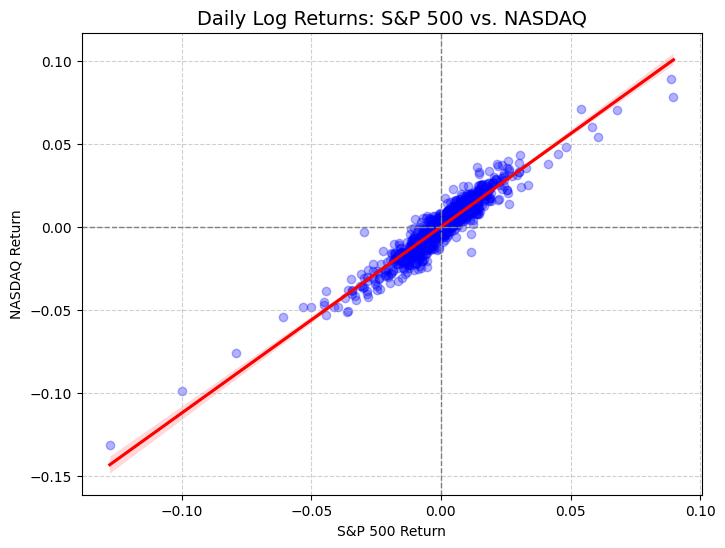

In [44]:
# === 5.3 Visualization: S&P 500 vs. NASDAQ Correlation ===

plt.figure(figsize=(8, 6))

# Create a scatter plot with a linear regression line.
sns.regplot(x="SP500", y="NASDAQ", data=log_returns_df,
            scatter_kws={'alpha':0.3, 'color': 'blue'}, # Make points semi-transparent
            line_kws={'color': 'red'})                 # Make the regression line red

# Add reference lines at x=0 and y=0 to represent the quadrants.
plt.axhline(0, linestyle="--", color="grey", linewidth=1)
plt.axvline(0, linestyle="--", color="grey", linewidth=1)

plt.title("Daily Log Returns: S&P 500 vs. NASDAQ", fontsize=14)
plt.xlabel("S&P 500 Return")
plt.ylabel("NASDAQ Return")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

As expected, the plot shows a strong linear relationship. Most points are clustered in the top-right (both positive) and bottom-left (both negative) quadrants, which is characteristic of a high positive correlation (~0.943).

Now, let's visualize the relationship between the S&P 500 and Bitcoin. Based on the correlation of ~0.205, we expect a much more scattered plot with a slight upward trend.

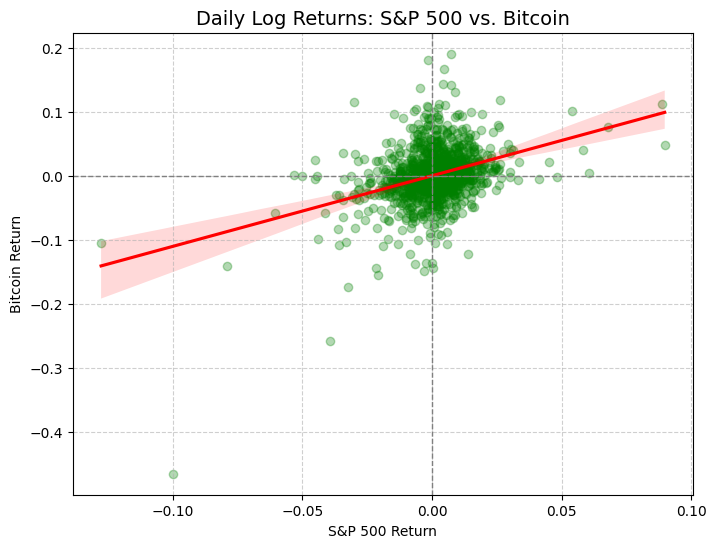

In [45]:
# === 5.4 Visualization: S&P 500 vs. Bitcoin Correlation ===

plt.figure(figsize=(8, 6))

# Create the scatter plot for SP500 vs. Bitcoin.
sns.regplot(x="SP500", y="Bitcoin", data=log_returns_df,
            scatter_kws={'alpha':0.3, 'color': 'green'},
            line_kws={'color': 'red'})

# Add reference lines.
plt.axhline(0, linestyle="--", color="grey", linewidth=1)
plt.axvline(0, linestyle="--", color="grey", linewidth=1)

plt.title("Daily Log Returns: S&P 500 vs. Bitcoin", fontsize=14)
plt.xlabel("S&P 500 Return")
plt.ylabel("Bitcoin Return")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **3.3 The Sharpe Ratio**

While correlation tells us how assets move together, the **Sharpe Ratio** helps us evaluate an individual asset's performance by relating its return to its volatility. It is the most common measure of **risk-adjusted return**.

The formula is:
$$ \text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p} $$

Where:
-   $R_p$ = The average return of the portfolio/asset.
-   $R_f$ = The risk-free rate (the return of an investment with zero risk, like a U.S. Treasury bill).
-   $\sigma_p$ = The standard deviation of the portfolio/asset's excess return.

A higher Sharpe Ratio is better, as it indicates a higher return per unit of risk.

For simplicity in many analyses, especially when dealing with short time periods like daily returns, the risk-free rate ($R_f$) is often assumed to be 0. The formula then simplifies to:

$$ \text{Sharpe Ratio} \approx \frac{R_p}{\sigma_p} $$

We will use this simplified version to compare the S&P 500 and Bitcoin.

In [46]:
# === 5.5 Risk-Adjusted Return: Sharpe Ratio ===

# Calculate the mean daily log return for each asset.
mean_returns = log_returns_df.mean()

# Calculate the daily volatility (standard deviation) for each asset.
volatility = log_returns_df.std()

# Calculate the simplified Sharpe Ratio (assuming risk-free rate is 0).
sharpe_ratio = mean_returns / volatility

print("--- Daily Sharpe Ratios (Risk-Free Rate = 0) ---")
print(sharpe_ratio)

# --- Annualized Sharpe Ratio ---
# To make the Sharpe Ratio more comparable across different time frames, it is often annualized.
# We do this by multiplying the daily Sharpe Ratio by the square root of the number of trading days.
annualized_sharpe_ratio = sharpe_ratio * np.sqrt(252) # Using 252 for all for direct comparison

print("\n--- Annualized Sharpe Ratios ---")
print(annualized_sharpe_ratio)

--- Daily Sharpe Ratios (Risk-Free Rate = 0) ---
Ticker
Bitcoin   0.034982
SP500     0.036991
NASDAQ    0.038631
dtype: float64

--- Annualized Sharpe Ratios ---
Ticker
Bitcoin   0.555328
SP500     0.587215
NASDAQ    0.613245
dtype: float64


Based on the annualized results, the S&P 500 has a Sharpe Ratio of approximately **0.59**, while Bitcoin's is slightly lower at **0.55**. This suggests that over this period, after accounting for its significantly higher volatility, the S&P 500 offered a slightly better risk-adjusted return than Bitcoin.

**Important Note:** A major limitation of the standard Sharpe Ratio is its use of standard deviation, which implicitly assumes that returns are normally distributed and treats upside volatility (good) and downside volatility (bad) equally.

## **4. Semivariance: A Focus on Downside Risk**

A major flaw with standard deviation (and thus the Sharpe Ratio) is that it treats all volatility the same. It penalizes an investment for large positive returns just as much as it does for large negative returns.

Most long-term investors are primarily concerned with **downside risk**. **Semivariance** is a risk measure that addresses this by only considering the returns that fall *below* the average return. It calculates the average squared deviation of these "underperforming" returns.

$$ \text{Semivariance} = \frac{1}{n} \sum_{r_i < \bar{r}}^{n} (r_i - \bar{r})^2 $$

Where the sum is only taken for returns ($r_i$) that are less than the mean return ($\bar{r}$).

A higher semivariance indicates greater downside risk, meaning the asset has a history of larger or more frequent negative deviations from its average performance.

In [47]:
# === 6.1 Downside Risk: Semivariance Calculation ===

# Calculate the mean return for each asset.
mean_returns = log_returns_df.mean()

# --- Semivariance for S&P 500 ---
# 1. Filter for returns below the mean.
sp500_negative_returns = log_returns_df[log_returns_df['SP500'] < mean_returns['SP500']]
# 2. Calculate the squared differences from the mean for these returns.
sp500_squared_diffs = (sp500_negative_returns['SP500'] - mean_returns['SP500'])**2
# 3. Calculate the mean of these squared differences (the semivariance).
sp500_semivariance = sp500_squared_diffs.mean()


# --- Semivariance for NASDAQ ---
nasdaq_negative_returns = log_returns_df[log_returns_df['NASDAQ'] < mean_returns['NASDAQ']]
nasdaq_squared_diffs = (nasdaq_negative_returns['NASDAQ'] - mean_returns['NASDAQ'])**2
nasdaq_semivariance = nasdaq_squared_diffs.mean()


# --- Semivariance for Bitcoin ---
btc_negative_returns = log_returns_df[log_returns_df['Bitcoin'] < mean_returns['Bitcoin']]
btc_squared_diffs = (btc_negative_returns['Bitcoin'] - mean_returns['Bitcoin'])**2
btc_semivariance = btc_squared_diffs.mean()


# --- Print the results ---
print(f"Semivariance of S&P 500: {sp500_semivariance:.6f}")
print(f"Semivariance of NASDAQ: {nasdaq_semivariance:.6f}")
print(f"Semivariance of Bitcoin: {btc_semivariance:.6f}")

Semivariance of S&P 500: 0.000210
Semivariance of NASDAQ: 0.000298
Semivariance of Bitcoin: 0.001814


In [48]:
# === 6.2 Semivariance Calculation (Corrected Vectorized Method) ===

# This is the correct and concise way to calculate semivariance for all columns.

# 1. Use the .where() method. It keeps values where the condition is True
#    and replaces them with NaN where the condition is False.
negative_returns_only = log_returns_df.where(log_returns_df < mean_returns)

# 2. Square the difference. The operation is still vectorized.
#    Pandas will correctly subtract the mean from the non-NaN values and ignore the NaNs.
squared_diffs = (negative_returns_only - mean_returns)**2

# 3. Calculate the mean. The .mean() function automatically ignores NaN values by default.
semivariance_vectorized = squared_diffs.mean()

print("--- Semivariance (Corrected Vectorized Calculation) ---")
print(semivariance_vectorized)

--- Semivariance (Corrected Vectorized Calculation) ---
Ticker
Bitcoin   0.001814
SP500     0.000210
NASDAQ    0.000298
dtype: float64


The output shows that Bitcoin has a much higher semivariance (\~0.000579) compared to the S&P 500 (\~0.000074) and NASDAQ (\~0.000099). This confirms that Bitcoin not only has higher overall volatility but specifically has a much greater tendency for large negative price swings compared to the stock indices. This is a critical insight for risk management.

## **5. How Are Stock Returns Distributed?**

Many financial models and theories (like the Sharpe Ratio) are built on the assumption that asset returns follow a **normal distribution** (also known as a Gaussian distribution or "bell curve").

Properties of a perfect normal distribution include:
-   **Symmetry:** The mean, median, and mode are all identical. The distribution is perfectly symmetrical around the mean.
-   **Predictable Spread:** ~68% of data falls within +/- 1 standard deviation of the mean, ~95% within +/- 2, and ~99.7% within +/- 3.

If our data is truly normal, we can confidently use mean and standard deviation to model risk and return. If not, these metrics can be misleading, and we may need to consider alternative distributions.

Let's investigate this by pulling 20 years of daily S&P 500 data and calculating its log returns.

In [49]:
# === 7.1 Distribution Analysis: Data Retrieval (20 Years) ===

# --- Parameters ---
start_date_long = datetime.date(2004, 8, 1)
end_date_long = datetime.date(2024, 8, 1)
ticker_long = {"^GSPC": "SP500"}

# --- Data Download and Processing ---
# Download the 'Adj Close' data.
prices_long_df = yfin.download(
    list(ticker_long.keys()),
    start=start_date_long,
    end=end_date_long,
    auto_adjust=False,
    progress=False
)['Adj Close']

# Rename the column.
prices_long_df = prices_long_df.rename(columns=ticker_long)

# Calculate log returns.
log_returns_long_df = np.log(prices_long_df).diff().dropna()

# --- Display Info ---
print(f"Downloaded {len(log_returns_long_df)} daily log returns for the S&P 500.")
log_returns_long_df.head()

Downloaded 5033 daily log returns for the S&P 500.


Ticker,SP500
Date,
2004-08-03,-0.006282
2004-08-04,-0.000964
2004-08-05,-0.016455
2004-08-06,-0.015602
2004-08-09,0.001174


The result is approximately 52.6%, which is close to 50% but not exact. This indicates a slight **negative skew** (the tail on the left side is longer or fatter than the right side), but it's not extreme enough on its own to definitively rule out normality based on this simple test alone.

### **5.2 Is Volatility Constant?**

Another key assumption of the normal distribution model in finance is **constant volatility**. We can visually test this by calculating and plotting a rolling standard deviation. If volatility were constant, this line would be flat. We will use a 50-day rolling window, a common period for short-to-medium term trend analysis.

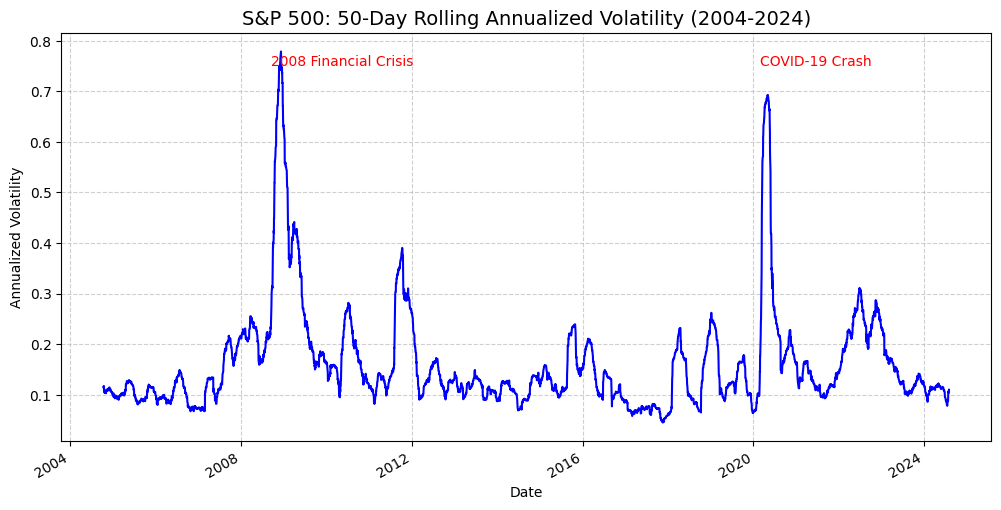

In [50]:
# === 7.3 Volatility Check: Rolling Standard Deviation ===

# Calculate the rolling 50-day standard deviation of the daily log returns.
rolling_volatility = log_returns_long_df['SP500'].rolling(window=50).std()

# To make the plot more intuitive, let's annualize this rolling volatility.
annualized_rolling_volatility = rolling_volatility * np.sqrt(252)

# --- Plotting the Rolling Volatility ---
plt.figure(figsize=(12, 6))
annualized_rolling_volatility.plot(color='blue')

plt.title('S&P 500: 50-Day Rolling Annualized Volatility (2004-2024)', fontsize=14)
plt.ylabel('Annualized Volatility')
plt.xlabel('Date')
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight some notable periods of high volatility.
# We use plt.text() to add annotations directly to the plot.
plt.text(datetime.date(2008, 9, 15), 0.75, '2008 Financial Crisis', fontsize=10, color='red')
plt.text(datetime.date(2020, 3, 1), 0.75, 'COVID-19 Crash', fontsize=10, color='red')

plt.show()

## **6. Are Stock Returns Normally Distributed?**

We've seen that volatility isn't constant and the returns aren't perfectly symmetric. Now let's perform a more direct assessment by comparing the distribution of our return data to a perfect normal distribution.

We can start by visualizing the data using a histogram. We will overlay a Kernel Density Estimate (KDE) plot to get a smoother representation of the distribution's shape.

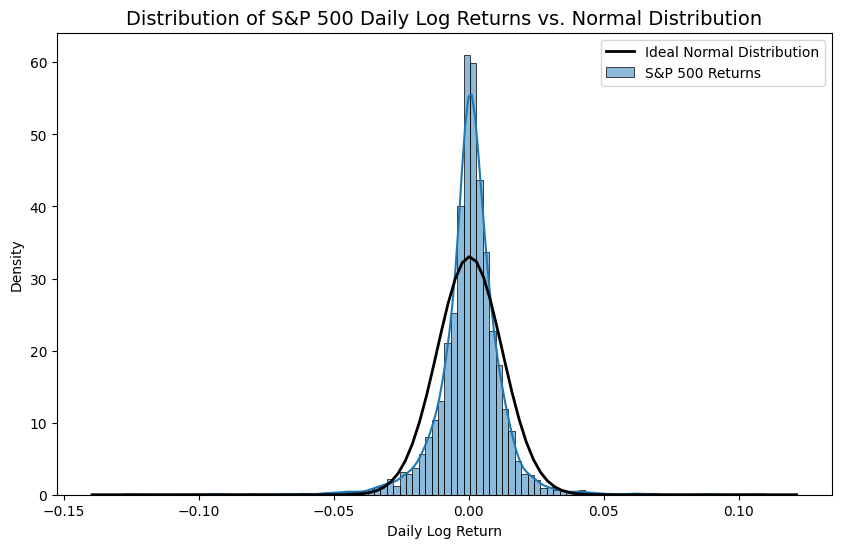

In [51]:
# === 8.1 Normality Test: Visual Inspection (Histogram & KDE) ===

plt.figure(figsize=(10, 6))

# Plot a histogram of the S&P 500 daily log returns.
# Using density=True normalizes the histogram so the area under the curve is 1.
sns.histplot(log_returns_long_df['SP500'], bins=100, kde=True, stat="density", label='S&P 500 Returns')

# --- Overlay a perfect normal distribution for comparison ---
# Generate points for the x-axis.
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Calculate the probability density function (PDF) for a normal distribution
# with the same mean and standard deviation as our data.
mu = log_returns_long_df['SP500'].mean()
sigma = log_returns_long_df['SP500'].std()
p = stats.norm.pdf(x, mu, sigma)

# Plot the ideal normal distribution curve.
plt.plot(x, p, 'k', linewidth=2, label='Ideal Normal Distribution')

plt.title('Distribution of S&P 500 Daily Log Returns vs. Normal Distribution', fontsize=14)
plt.xlabel('Daily Log Return')
plt.ylabel('Density')
plt.legend()
plt.show()

The visual inspection strongly suggests non-normality. The actual distribution of S&P 500 returns has a much sharper peak and heavier tails than the ideal normal distribution.

### **6.1 Conducting a Normality Test**

To quantify this, we can use a formal statistical test. The **D'Agostino-Pearson normality test** is an omnibus test that checks for deviations from normality based on both skewness and kurtosis.

-   **Null Hypothesis (H₀):** The sample data comes from a normal distribution.
-   **p-value:** If the p-value is very small (typically < 0.05), we **reject the null hypothesis** and conclude the data is not normal.

In [52]:
# === 8.2 Normality Test: D'Agostino-Pearson ===

# Extract the S&P 500 returns as a NumPy array.
sp500_returns = log_returns_long_df['SP500'].values

# Perform the normality test.
stat, p_value = stats.normaltest(sp500_returns)

print(f"D'Agostino-Pearson Normality Test:")
print(f"  - Test Statistic: {stat:.2f}")
print(f"  - P-value: {p_value}") # The 'e' notation means '10 to the power of'

if p_value < 0.05:
    print("\nConclusion: The p-value is less than 0.05, so we reject the null hypothesis.")
    print("The S&P 500 return data is not normally distributed.")
else:
    print("\nConclusion: The p-value is greater than 0.05, so we fail to reject the null hypothesis.")
    print("The data is consistent with a normal distribution.")

D'Agostino-Pearson Normality Test:
  - Test Statistic: 1234.73
  - P-value: 7.612880045350763e-269

Conclusion: The p-value is less than 0.05, so we reject the null hypothesis.
The S&P 500 return data is not normally distributed.


### **6.2 Testing Skewness and Kurtosis**

The **Jarque-Bera test** is another test for normality that specifically focuses on whether the sample data has skewness and kurtosis matching a normal distribution. Again, a small p-value indicates non-normality.

In [53]:
# === 8.3 Normality Test: Jarque-Bera ===

# Perform the Jarque-Bera test.
jb_stat, jb_p_value = stats.jarque_bera(sp500_returns)

print(f"Jarque-Bera Normality Test:")
print(f"  - Test Statistic: {jb_stat:.2f}")
print(f"  - P-value: {jb_p_value}")

if jb_p_value < 0.05:
    print("\nConclusion: The p-value is effectively zero. We reject the null hypothesis.")
    print("The data is not normally distributed.")
else:
    print("\nConclusion: The p-value is greater than 0.05, so we fail to reject the null hypothesis.")

Jarque-Bera Normality Test:
  - Test Statistic: 36591.04
  - P-value: 0.0

Conclusion: The p-value is effectively zero. We reject the null hypothesis.
The data is not normally distributed.


### **6.3 Why Does the Normality Test Fail? Fat Tails**

The statistical tests overwhelmingly reject normality. The primary reason for this in financial data is the presence of **fat tails**. This means that extreme events (large daily gains or losses) occur far more often than a normal distribution would suggest.

According to the normal distribution's "empirical rule":
-   A move of more than 3 standard deviations should happen only 0.3% of the time.
-   A move of more than 5 standard deviations is practically impossible.

Let's calculate the Z-score (the number of standard deviations from the mean) for the single worst and best trading days in our 20-year sample.

$$ Z = \frac{X - \bar{X}}{\sigma} $$

In [54]:
# === 8.4 Quantifying Fat Tails: Z-Scores of Extreme Events ===

# Get the mean and standard deviation of the returns.
mean_return = log_returns_long_df['SP500'].mean()
std_dev = log_returns_long_df['SP500'].std()

# Find the maximum and minimum returns.
max_return = log_returns_long_df['SP500'].max()
min_return = log_returns_long_df['SP500'].min()

# Calculate the Z-score for these extreme returns.
z_score_max = (max_return - mean_return) / std_dev
z_score_min = (min_return - mean_return) / std_dev

print(f"Maximum daily return: {max_return:.2%}")
print(f"Minimum daily return: {min_return:.2%}")
print("-" * 50)
print(f"Z-score of maximum return: {z_score_max:.2f} (i.e., {z_score_max:.2f} standard deviations above the mean)")
print(f"Z-score of minimum return: {z_score_min:.2f} (i.e., {z_score_min:.2f} standard deviations below the mean)")

# --- Calculate the theoretical probability of such an event ---
# stats.norm.cdf() gives the cumulative probability up to that Z-score.
# For a negative Z-score, this is the probability of an event that bad OR WORSE happening.
prob_min_event = stats.norm.cdf(z_score_min)

print(f"\nTheoretical probability of a <= {z_score_min:.2f} standard deviation event in a normal distribution: {prob_min_event}")

Maximum daily return: 10.96%
Minimum daily return: -12.77%
--------------------------------------------------
Z-score of maximum return: 9.05 (i.e., 9.05 standard deviations above the mean)
Z-score of minimum return: -10.60 (i.e., -10.60 standard deviations below the mean)

Theoretical probability of a <= -10.60 standard deviation event in a normal distribution: 1.4859355808132133e-26


The results are staggering. The worst day in our sample was a drop of **-10.60 standard deviations** from the mean. The theoretical probability of an event this extreme or worse happening in a single day under a normal distribution is `1.49e-26`—a number so infinitesimally small it's effectively zero. Yet, it happened.

Let's look at this another way. The normal distribution predicts that 99.7% of all data points should fall within +/- 3 standard deviations. Let's see how many of our 5,000+ data points actually fall *outside* this range.

In [55]:
# === 8.5 Quantifying Fat Tails: Events Beyond 3 Standard Deviations ===

# Calculate the return levels for +3 and -3 standard deviations.
upper_bound = mean_return + (3 * std_dev)
lower_bound = mean_return - (3 * std_dev)

print(f"The 3-sigma range is between {lower_bound:.2%} and {upper_bound:.2%}")

# --- Count the number of outliers ---
# Filter the DataFrame for any returns that fall outside this range.
outliers = log_returns_long_df[(log_returns_long_df['SP500'] < lower_bound) | (log_returns_long_df['SP500'] > upper_bound)]
num_outliers = len(outliers)

# --- Compare to theoretical expectation ---
total_days = len(log_returns_long_df)
expected_outliers = total_days * (1 - 0.997) # 0.3% of data should be outside 3-sigma

print(f"\nIn our sample of {total_days} trading days:")
print(f"  - We OBSERVED {num_outliers} days with returns beyond +/- 3 standard deviations.")
print(f"  - A normal distribution would PREDICT only {expected_outliers:.1f} such days.")

The 3-sigma range is between -3.59% and 3.65%

In our sample of 5033 trading days:
  - We OBSERVED 84 days with returns beyond +/- 3 standard deviations.
  - A normal distribution would PREDICT only 15.1 such days.


## **7. Non-Gaussian Distributions: The Student's t-Distribution**

Since the normal distribution is a poor fit, we need a better model. One popular alternative is the **Student's t-distribution**. It is similar to the normal distribution but is characterized by an additional parameter called "degrees of freedom" (df), which controls the "fatness" of its tails. A lower df value results in fatter tails.

A distribution with fatter tails and a sharper peak than the normal distribution is called **leptokurtic**. By definition, a leptokurtic distribution has a kurtosis value greater than 3. Let's check the kurtosis of our S&P 500 data.

In [56]:
# === 9.1 Kurtosis Check ===

# Kurtosis measures the "tailedness" of the distribution.
# A normal distribution has a kurtosis of 3 (or 0 in "excess kurtosis" measures).
# The pandas .kurt() method calculates excess kurtosis, so a value > 0 is leptokurtic.
sp500_kurtosis = log_returns_long_df['SP500'].kurt()

print(f"Excess Kurtosis of S&P 500 Returns: {sp500_kurtosis:.2f}")
print("Since the value is significantly greater than 0, the distribution is highly leptokurtic.")

Excess Kurtosis of S&P 500 Returns: 13.18
Since the value is significantly greater than 0, the distribution is highly leptokurtic.


The kurtosis is indeed much greater than what we'd expect for a normal distribution, confirming it is leptokurtic.

Now, let's visually fit a Student's t-distribution to our data and compare it to both the actual data and the normal distribution we plotted earlier. We'll use **Maximum Likelihood Estimation (MLE)** to find the t-distribution parameters that best fit our observed returns.

Fitted t-distribution parameters: df=2.40, loc=0.0008, scale=0.0064


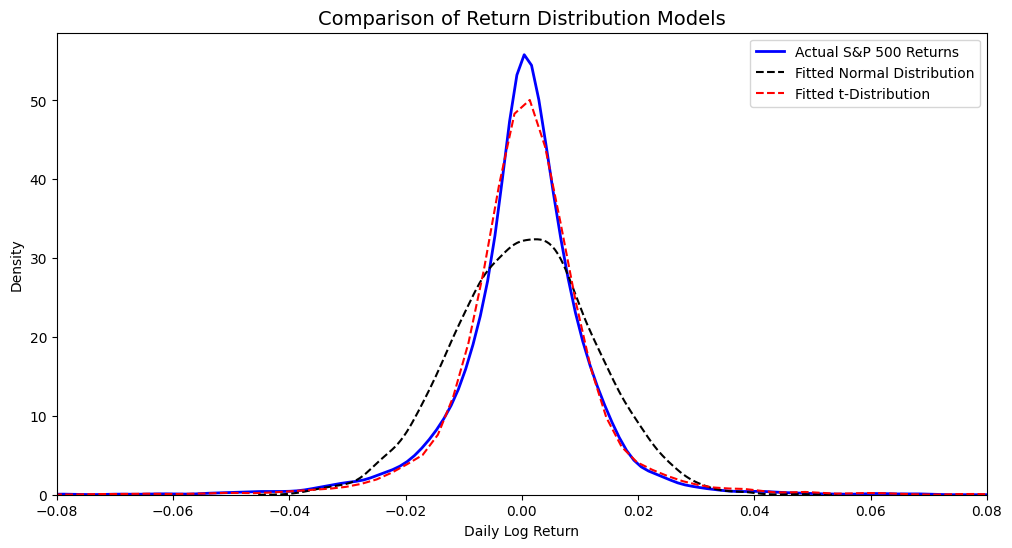

In [57]:
# === 9.2 Fitting and Visualizing the Student's t-Distribution ===

# --- Fit the t-distribution to the data using MLE ---
# stats.t.fit() returns the best-fit parameters: degrees of freedom (df), location (loc), and scale.
params_t = stats.t.fit(log_returns_long_df['SP500'])
df_t, loc_t, scale_t = params_t
print(f"Fitted t-distribution parameters: df={df_t:.2f}, loc={loc_t:.4f}, scale={scale_t:.4f}")

# --- Generate random samples from our fitted distributions for plotting ---
np.random.seed(42) # for reproducibility
# Generate data from a normal distribution with the same mean/std as our data.
normal_sample = stats.norm.rvs(loc=mu, scale=sigma, size=len(log_returns_long_df))
# Generate data from our newly fitted t-distribution.
t_sample_fitted = stats.t.rvs(df=df_t, loc=loc_t, scale=scale_t, size=len(log_returns_long_df))

# --- Create the comparison plot ---
plt.figure(figsize=(12, 6))

# Plot the KDE of the actual S&P 500 returns.
sns.kdeplot(log_returns_long_df['SP500'], label='Actual S&P 500 Returns', color='blue', linewidth=2)
# Plot the KDE of the ideal normal distribution sample.
sns.kdeplot(normal_sample, label='Fitted Normal Distribution', color='black', linestyle='--')
# Plot the KDE of the fitted t-distribution sample.
sns.kdeplot(t_sample_fitted, label='Fitted t-Distribution', color='red', linestyle='--')

plt.xlim(-0.08, 0.08)
plt.title('Comparison of Return Distribution Models', fontsize=14)
plt.xlabel('Daily Log Return')
plt.ylabel('Density')
plt.legend()
plt.show()

The visual inspection shows that the fitted t-distribution (red) provides a much better approximation of the actual data's sharp peak compared to the normal distribution (black).

Now, let's zoom in on the tails to see if the t-distribution also better captures the probability of extreme negative events.

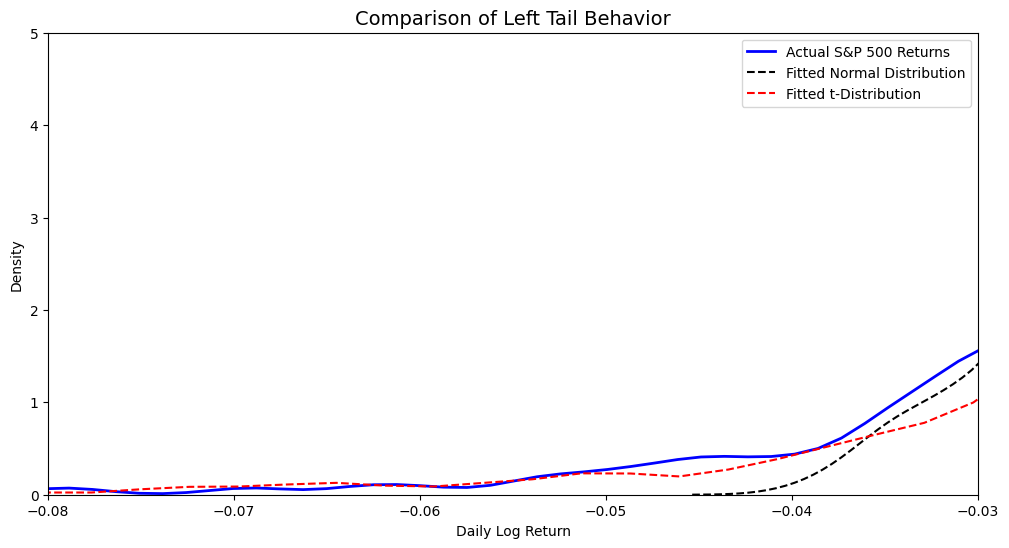

In [58]:
# === 9.3 Visualizing the Tails ===

plt.figure(figsize=(12, 6))

# Plot the same KDEs as before.
sns.kdeplot(log_returns_long_df['SP500'], label='Actual S&P 500 Returns', color='blue', linewidth=2)
sns.kdeplot(normal_sample, label='Fitted Normal Distribution', color='black', linestyle='--')
sns.kdeplot(t_sample_fitted, label='Fitted t-Distribution', color='red', linestyle='--')

# Zoom in on the left (negative) tail.
plt.xlim(-0.08, -0.03)
plt.ylim(0, 5) # Adjust y-limit to make the tail differences clear

plt.title('Comparison of Left Tail Behavior', fontsize=14)
plt.xlabel('Daily Log Return')
plt.ylabel('Density')
plt.legend()
plt.show()

## **8. Conclusion**

This lesson moved from basic price analysis to a more sophisticated statistical examination of **financial returns**. We covered several essential topics for any aspiring quantitative analyst:

1.  **Risk Quantification:** We defined and calculated key risk metrics, including **variance**, **standard deviation**, and the more nuanced **semivariance**, which focuses specifically on downside risk. We observed how different assets, like Bitcoin and the S&P 500, exhibit vastly different risk profiles.

2.  **Asset Relationships:** We explored **covariance** and **correlation** to understand how asset returns move in relation to each other, a fundamental concept for portfolio construction and diversification.

3.  **Risk-Adjusted Performance:** We introduced the **Sharpe Ratio**, a critical tool for evaluating an investment's return relative to the risk taken to achieve it.

4.  **Distribution Analysis:** Most importantly, we empirically tested the common assumption that stock returns are normally distributed. Through visual inspection, formal statistical tests (D'Agostino-Pearson, Jarque-Bera), and an analysis of extreme events ("fat tails"), we conclusively demonstrated that **S&P 500 returns are not normal**. They are, in fact, **leptokurtic**.

5.  **Alternative Models:** We showed that the **Student's t-distribution**, which accounts for fatter tails, provides a much more accurate model for the observed distribution of stock returns than the traditional normal distribution.

Understanding these concepts is critical. Mischaracterizing risk by incorrectly assuming a normal distribution can lead to flawed models that significantly underestimate the probability of extreme market events.

**References**

-   D'Agostino, Ralph B. "An Omnibus Test of Normality for Moderate and Large Size Samples." *Biometrika*, vol. 58, no. 2, 1971, pp. 341–348, https://doi.org/10.1093/biomet/58.2.341.

MODULE 2 | LESSON 3
---

# **Special Matrices for Equity Analysis**

| | |
|:---|:---|
|**Reading Time** | 60 minutes |
|**Prior Knowledge** | Basic Matrix Operations, Linear Algebra, Basic Python |
|**Keywords** | Stock Return Correlation, Symmetric Matrices, Matrix Diagonalization, Triangular Matrices, Positive Definite Matrices, Cholesky Factorization|

---

*In this lesson, we will introduce several types of special matrices that play important roles in financial analysis. A sound understanding of the characteristics and operations of these matrices provides a strong foundation for many advanced financial techniques. We will use the stock returns of Apple, Ford, and Walmart to demonstrate the practical applications of these matrices.*

In [59]:
# === 1. Environment Setup: Import Libraries ===

# Core data handling and numerical operations
import datetime
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Financial data retrieval
import yfinance as yfin

# --- Display Options ---
# Set a Pandas display option to format floating-point numbers for better readability.
pd.options.display.float_format = "{:,.6f}".format

print("Libraries imported successfully!")

Libraries imported successfully!


## **1. Symmetric Matrices**

### **1.1 Definition and Properties**

A **symmetric matrix** is a square matrix that is equal to its own transpose. A square matrix has the same number of rows and columns.

**Mathematically:** A matrix $A$ is symmetric if $A = A^T$. This means the element at position $(i, j)$ is equal to the element at position $(j, i)$ for all $i$ and $j$.

**Example:**
$$ A = \begin{bmatrix} m & a & b \\ a & n & c \\ b & c & p \end{bmatrix} \quad \implies \quad A^T = \begin{bmatrix} m & a & b \\ a & n & c \\ b & c & p \end{bmatrix} $$

Symmetric matrices are fundamental in finance (e.g., in covariance and correlation matrices) and have several important properties:
1.  **Real Eigenvalues:** All their eigenvalues are real numbers, which is crucial for stability in financial models.
2.  **Orthogonal Eigenvectors:** Their eigenvectors are orthogonal, meaning they are perpendicular and linearly independent.
3.  **Diagonalizable:** They can always be diagonalized, a process we will explore next.

In [60]:
# === 2.1 Practical Example: Creating and Testing a Symmetric Matrix ===

# Define a symmetric matrix using a NumPy array.
A = np.array([
    [5, 2, 8],
    [2, 9, 3],
    [8, 3, 1]
])

# Get the transpose of the matrix.
A_transpose = A.T

# Check for symmetry using np.allclose(), which is better than A == A.T for floating-point numbers.
is_symmetric = np.allclose(A, A_transpose)

print("Original Matrix A:\n", A)
print("\nTranspose of A (A.T):\n", A_transpose)
print(f"\nIs the matrix symmetric? {is_symmetric}")

# Define a non-symmetric matrix for comparison.
B = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print("\n----------------------------------")
print("Non-Symmetric Matrix B:\n", B)
print(f"Is matrix B symmetric? {np.allclose(B, B.T)}")

Original Matrix A:
 [[5 2 8]
 [2 9 3]
 [8 3 1]]

Transpose of A (A.T):
 [[5 2 8]
 [2 9 3]
 [8 3 1]]

Is the matrix symmetric? True

----------------------------------
Non-Symmetric Matrix B:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Is matrix B symmetric? False


### **1.2 Diagonalization of Symmetric Matrices**
A key property of symmetric matrices is that they are **diagonalizable**. This means a symmetric matrix $A$ can be decomposed into the product of three other matrices:

$$ A = B \Lambda B^{-1} $$

Where:
-   $\Lambda$ (Lambda) is a **diagonal matrix** containing the **eigenvalues** of $A$.
-   $B$ is an **orthogonal matrix** whose columns are the corresponding **eigenvectors** of $A$.

For an orthogonal matrix like $B$, its inverse is simply its transpose ($B^{-1} = B^T$). This simplifies the decomposition to:

$$ A = B \Lambda B^T $$

This decomposition is extremely useful. It simplifies complex matrix computations and is the foundation for techniques like Principal Component Analysis (PCA), which is widely used in finance to identify sources of risk.

Let's walk through the manual calculation for an example matrix.

We have a symmetric matrix $M$ as follows:

$$ M = \begin{bmatrix} 6 & -2 & -1 \\ -2 & 6 & -1 \\ -1 & -1 & 5 \end{bmatrix} $$

To find the eigenvalues ($\lambda$), we solve the characteristic equation $det(M - \lambda I) = 0$:

$$ det \begin{pmatrix} 6-\lambda & -2 & -1 \\ -2 & 6-\lambda & -1 \\ -1 & -1 & 5-\lambda \end{pmatrix} = 0 $$
$$ \Downarrow $$
$$ -\lambda^3 + 17\lambda^2 - 90\lambda + 144 = -(\lambda-8)(\lambda-6)(\lambda-3) = 0 $$

The eigenvalues are $\lambda_1 = 8$, $\lambda_2 = 6$, and $\lambda_3 = 3$.

The corresponding (un-normalized) eigenvectors are:
$$ v_1 = \begin{bmatrix} -1 \\ 1 \\ 0 \end{bmatrix}, \quad v_2 = \begin{bmatrix} -1 \\ -1 \\ 2 \end{bmatrix}, \quad v_3 = \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix} $$

Notice that the eigenvectors are orthogonal (their dot products are 0, e.g., $v_1^T v_2 = 0$). We can then normalize these to be unit vectors to form the orthogonal matrix $B$.

Let's verify these calculations and perform the full diagonalization using NumPy.

In [61]:
# === 2.2 Diagonalization in Python ===

# Define the matrix M.
M = np.array([
    [6, -2, -1],
    [-2, 6, -1],
    [-1, -1, 5]
])

# Use np.linalg.eig() to calculate eigenvalues and eigenvectors.
eigenvalues, eigenvectors = np.linalg.eig(M)

# The eigenvalues are the diagonal of our Lambda matrix.
Lambda = np.diag(eigenvalues)

# The eigenvectors form the columns of our B matrix.
B = eigenvectors

# Let's verify the decomposition A = B * Lambda * B_transpose
# Note: For orthogonal matrices from symmetric inputs, B_inverse is B_transpose.
B_transpose = B.T
M_reconstructed = B @ Lambda @ B_transpose # Using @ for matrix multiplication

print("Original Matrix M:\n", M)
print("\nEigenvalues (Lambda diagonal):\n", eigenvalues)
print("\nEigenvectors (Columns of B):\n", B)
print("\nReconstructed Matrix (B @ Lambda @ B.T):\n", M_reconstructed)

# Check if the reconstructed matrix is close to the original.
print("\nIs the reconstruction correct?", np.allclose(M, M_reconstructed))

Original Matrix M:
 [[ 6 -2 -1]
 [-2  6 -1]
 [-1 -1  5]]

Eigenvalues (Lambda diagonal):
 [3. 8. 6.]

Eigenvectors (Columns of B):
 [[ 5.77350269e-01  7.07106781e-01 -4.08248290e-01]
 [ 5.77350269e-01 -7.07106781e-01 -4.08248290e-01]
 [ 5.77350269e-01 -2.79509395e-16  8.16496581e-01]]

Reconstructed Matrix (B @ Lambda @ B.T):
 [[ 6. -2. -1.]
 [-2.  6. -1.]
 [-1. -1.  5.]]

Is the reconstruction correct? True


### **1.3 Application: The Covariance Matrix**

The **covariance matrix**, which we used in the previous lesson, is a perfect real-world example of a symmetric matrix. It is a square matrix showing the variance of each asset on the main diagonal and the covariance between each pair of assets on the off-diagonals.

Let's calculate the covariance matrix for the daily returns of Apple (AAPL), Ford (F), and Walmart (WMT). First, we'll download and process the price data.

In [62]:
# === 3.1 Data Preparation for Covariance/Correlation ===

# --- Parameters ---
tickers = ["AAPL", "F", "WMT"]
start_date = datetime.date(2018, 1, 2)
end_date = datetime.date(2023, 12, 31)

# --- Data Download and Return Calculation ---
# Download adjusted close prices.
prices_df = yfin.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)['Adj Close']

# Calculate simple percentage returns and drop the initial NaN row.
returns_df = prices_df.pct_change().dropna()

print("Sample of daily returns:")
returns_df.head()

Sample of daily returns:


Ticker,AAPL,F,WMT
Date,,,
2018-01-03,-0.000175,0.007899,0.008723
2018-01-04,0.004645,0.017241,0.000905
2018-01-05,0.011385,0.016949,0.005927
2018-01-08,-0.003714,-0.003788,0.014780
2018-01-09,-0.000115,-0.005323,-0.012007


With the daily returns prepared, we can now calculate the covariance matrix.

In [63]:
# === 3.2 Covariance Matrix Calculation ===

# Calculate the covariance matrix for the stock returns.
covariance_matrix = returns_df.cov()

print("Apple, Ford, and Walmart Covariance Matrix:")
display(covariance_matrix)

# Verify that the resulting matrix is symmetric.
is_cov_symmetric = np.allclose(covariance_matrix.values, covariance_matrix.values.T)
print(f"\nIs the covariance matrix symmetric? {is_cov_symmetric}")

Apple, Ford, and Walmart Covariance Matrix:


Ticker,AAPL,F,WMT
Ticker,,,
AAPL,0.000398,0.000194,0.000103
F,0.000194,0.000668,0.000068
WMT,0.000103,0.000068,0.000199



Is the covariance matrix symmetric? True


### **1.4 Application: The Correlation Matrix**

The **correlation matrix** is another key symmetric matrix in finance. As we learned previously, it standardizes the covariance to a scale of -1 to +1, making it easier to compare the strength of linear relationships between different asset pairs.

Let's calculate the correlation matrix for our three stocks.

In [64]:
# === 3.3 Correlation Matrix Calculation ===

# Calculate the correlation matrix.
correlation_matrix = returns_df.corr()

print("Apple, Ford, and Walmart Correlation Matrix:")
display(correlation_matrix)

# Verify that the correlation matrix is also symmetric.
is_corr_symmetric = np.allclose(correlation_matrix.values, correlation_matrix.values.T)
print(f"\nIs the correlation matrix symmetric? {is_corr_symmetric}")

Apple, Ford, and Walmart Correlation Matrix:


Ticker,AAPL,F,WMT
Ticker,,,
AAPL,1.000000,0.376461,0.365246
F,0.376461,1.000000,0.185249
WMT,0.365246,0.185249,1.000000



Is the correlation matrix symmetric? True


The correlation matrix confirms it is symmetric, with 1.0s on the diagonal (as each asset is perfectly correlated with itself). We can see that Apple's returns have a moderate positive correlation with both Ford (~0.44) and Walmart (~0.36), while the relationship between Ford and Walmart is weaker (~0.23).

### **1.5 Converting Between Covariance and Correlation Matrices**

The relationship between correlation, covariance, and standard deviation is fundamental:
$$ \text{Corr}(X,Y) = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y} \quad \iff \quad \text{Cov}(X,Y) = \text{Corr}(X,Y) \times \sigma_X \sigma_Y $$

We can use this relationship to create functions that convert between the two matrix types. This is a useful technique, for example, if a model provides a correlation matrix, but you need the covariance matrix for portfolio optimization calculations.

In [65]:
# === 3.4 Conversion Functions ===

def cov_to_corr(cov_matrix):
    """Converts a covariance matrix to a correlation matrix."""
    # Standard deviation is the square root of variance (the diagonal of the cov matrix).
    std_dev = np.sqrt(np.diag(cov_matrix))
    # The formula is Cov(X,Y) / (std(X) * std(Y)).
    # np.outer(std_dev, std_dev) creates the matrix of std(X) * std(Y) products.
    corr_matrix = cov_matrix / np.outer(std_dev, std_dev)
    return corr_matrix

def corr_to_cov(corr_matrix, std_devs):
    """Converts a correlation matrix to a covariance matrix."""
    # The formula is Corr(X,Y) * std(X) * std(Y).
    cov_matrix = corr_matrix * np.outer(std_devs, std_devs)
    return cov_matrix

Let's test these functions using our stock return data.

In [66]:
# === 3.5 Testing the Conversions ===

# First, get the standard deviations of our daily returns.
stocks_std = returns_df.std().values

# --- Test 1: Convert our calculated covariance matrix to a correlation matrix ---
# The result should be identical to the one from .corr()
print("--- Covariance to Correlation ---")
converted_corr = cov_to_corr(covariance_matrix.values)
print("Original Correlation Matrix:\n", correlation_matrix.values.round(4))
print("\nConverted Correlation Matrix:\n", converted_corr.round(4))
print("\nConversion matches original?", np.allclose(correlation_matrix.values, converted_corr))


# --- Test 2: Convert our calculated correlation matrix back to a covariance matrix ---
# The result should be identical to the one from .cov()
print("\n\n--- Correlation to Covariance ---")
converted_cov = corr_to_cov(correlation_matrix.values, stocks_std)
print("Original Covariance Matrix:\n", covariance_matrix.values)
print("\nConverted Covariance Matrix:\n", converted_cov)
print("\nConversion matches original?", np.allclose(covariance_matrix.values, converted_cov))

--- Covariance to Correlation ---
Original Correlation Matrix:
 [[1.     0.3765 0.3652]
 [0.3765 1.     0.1852]
 [0.3652 0.1852 1.    ]]

Converted Correlation Matrix:
 [[1.     0.3765 0.3652]
 [0.3765 1.     0.1852]
 [0.3652 0.1852 1.    ]]

Conversion matches original? True


--- Correlation to Covariance ---
Original Covariance Matrix:
 [[3.98187502e-04 1.94212812e-04 1.02826851e-04]
 [1.94212812e-04 6.68388570e-04 6.75688924e-05]
 [1.02826851e-04 6.75688924e-05 1.99046097e-04]]

Converted Covariance Matrix:
 [[3.98187502e-04 1.94212812e-04 1.02826851e-04]
 [1.94212812e-04 6.68388570e-04 6.75688924e-05]
 [1.02826851e-04 6.75688924e-05 1.99046097e-04]]

Conversion matches original? True


## **2. Triangular Matrices**

A **triangular matrix** is a special kind of square matrix where all the entries on one side of the main diagonal are zero. There are two types: lower and upper triangular matrices.

### **2.1 Lower Triangular Matrix**
A **lower triangular matrix** is a square matrix where all entries *above* the main diagonal are zero.

$$ L = \begin{bmatrix}
m & 0 & 0 \\
a & n & 0 \\
b & c & p
\end{bmatrix} $$

### **2.2 Upper Triangular Matrix**
An **upper triangular matrix** is a square matrix where all entries *below* the main diagonal are zero.

$$ U = \begin{bmatrix}
m & a & b \\
0 & n & c \\
0 & 0 & p
\end{bmatrix} $$

In [67]:
# === 4.1 Creating Triangular Matrices in Python ===

# Start with a simple 3x3 matrix.
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

# Use np.tril() to get the lower triangular part.
L = np.tril(A)

# Use np.triu() to get the upper triangular part.
U = np.triu(A)

print("Original Matrix A:\n", A)
print("\nLower Triangular Matrix (L):\n", L)
print("\nUpper Triangular Matrix (U):\n", U)

Original Matrix A:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]

Lower Triangular Matrix (L):
 [[1 0 0]
 [4 5 0]
 [7 8 9]]

Upper Triangular Matrix (U):
 [[1 2 3]
 [0 5 6]
 [0 0 9]]


### **2.3 Properties of Triangular Matrices**

Triangular matrices have properties that make them computationally efficient and important in numerical linear algebra:
1.  **Determinant:** The determinant of a triangular matrix is simply the product of its diagonal elements.
2.  **Invertibility:** The inverse of an invertible triangular matrix is also a triangular matrix of the same type.
3.  **Products:** The product of two lower (or two upper) triangular matrices is also a lower (or upper) triangular matrix.

These properties are key to why triangular matrices are used in decompositions like LU decomposition and, as we will see later, Cholesky factorization. They simplify the process of solving systems of linear equations and inverting matrices.

In [68]:
# === 4.2 Demonstrating Properties in Python ===

# 1. Determinant is the product of the diagonal elements.
det_L = np.linalg.det(L)
product_diag_L = np.prod(np.diag(L)) # np.diag() extracts the diagonal

print("--- Property 1: Determinant ---")
print(f"Determinant of L: {det_L:.1f}")
print(f"Product of L's diagonal: {product_diag_L:.1f}")
print(f"Are they equal? {np.isclose(det_L, product_diag_L)}")

# 2. Product of two lower triangular matrices is lower triangular.
L2 = np.array([
    [2, 0, 0],
    [1, 3, 0],
    [5, 2, 4]
])

product_L_L2 = L @ L2
print("\n--- Property 3: Product ---")
print("Product of two Lower Triangular matrices:\n", product_L_L2)
print("(Note that the result is also a lower triangular matrix)")

--- Property 1: Determinant ---
Determinant of L: 45.0
Product of L's diagonal: 45.0
Are they equal? True

--- Property 3: Product ---
Product of two Lower Triangular matrices:
 [[ 2  0  0]
 [13 15  0]
 [67 42 36]]
(Note that the result is also a lower triangular matrix)


## **3. Positive Definite and Positive Semidefinite Matrices**

These are two important classes of symmetric matrices that have special properties, making them essential in optimization, statistics, and financial modeling.

### **3.1 Symmetric Positive Definite (PD) Matrices**

A symmetric matrix $A$ is **positive definite** if the scalar value $x^T A x$ is strictly positive for every non-zero column vector $x$.

$$ x^T A x > 0 \quad \text{for all non-zero } x $$

This condition might seem abstract, but it leads to several useful, concrete properties. A symmetric matrix is positive definite if and only if all of the following are true:

1.  **All eigenvalues are positive.** (This is the most common and robust test).
2.  The determinant of the matrix is positive.
3.  The matrix has full rank and is invertible.

In finance, covariance matrices of assets with non-perfect correlations are typically positive definite, which ensures that portfolio variance (a similar $w^T \Sigma w$ calculation) is always positive.

### **3.2 Symmetric Positive Semidefinite (PSD) Matrices**

A symmetric matrix $A$ is **positive semidefinite** if the scalar value $x^T A x$ is non-negative for every vector $x$.

$$ x^T A x \ge 0 \quad \text{for all } x $$

Key properties of a symmetric PSD matrix:
1.  **All eigenvalues are non-negative** (i.e., greater than or equal to zero).
2.  The determinant is non-negative.
3.  The matrix may not have full rank and may not be invertible (this happens if it has at least one zero eigenvalue).

Covariance and correlation matrices are always at least positive semidefinite. They become PSD (but not PD) if one asset is a perfect linear combination of others (i.e., perfect correlation), which would result in a zero eigenvalue.

Let's write a Python function to test these properties using our stock correlation matrix.

In [69]:
# === 5.1 Testing for Positive Definite / Semidefinite Properties ===

def check_matrix_properties(matrix, matrix_name="A"):
    """
    Checks if a matrix is symmetric and then determines if it is positive definite
    or positive semidefinite based on its eigenvalues.

    Args:
        matrix (np.ndarray): The input square matrix.
        matrix_name (str): A display name for the matrix.
    """
    print(f"--- Analyzing Matrix: {matrix_name} ---")

    # Check for symmetry first.
    if not np.allclose(matrix, matrix.T):
        print("The matrix is not symmetric, so it cannot be PD or PSD.")
        return

    # Calculate eigenvalues. For symmetric matrices, they are always real.
    eigenvalues = np.linalg.eigvals(matrix)
    print(f"Eigenvalues: {np.round(eigenvalues, 4)}")

    # Test for Positive Definite (all eigenvalues > 0).
    # We use a small tolerance (epsilon) for floating point comparisons.
    epsilon = 1e-10
    is_pd = np.all(eigenvalues > epsilon)
    if is_pd:
        print("Conclusion: All eigenvalues are positive. The matrix IS Positive Definite (PD).")
    else:
        # Test for Positive Semidefinite (all eigenvalues >= 0).
        is_psd = np.all(eigenvalues >= -epsilon)
        if is_psd:
            print("Conclusion: Not all eigenvalues are strictly positive, but all are non-negative.")
            print("The matrix IS Positive Semidefinite (PSD).")
        else:
            print("Conclusion: The matrix has negative eigenvalues. It is NOT PSD or PD.")

    # Show other related properties.
    print(f"Determinant: {np.linalg.det(matrix):.4f}")
    print(f"Matrix Rank: {np.linalg.matrix_rank(matrix)}")

In [70]:
# === 5.2 Applying the Test to Our Correlation Matrix ===

# Use the function on our stock returns correlation matrix.
check_matrix_properties(correlation_matrix.values, "Stock Correlation Matrix")

--- Analyzing Matrix: Stock Correlation Matrix ---
Eigenvalues: [1.6252 0.5599 0.8149]
Conclusion: All eigenvalues are positive. The matrix IS Positive Definite (PD).
Determinant: 0.7415
Matrix Rank: 3


In [71]:
# === 5.3 Applying the Test to a PSD Example ===

# This matrix has a determinant of 0 and is PSD but not PD.
M_psd = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])
check_matrix_properties(M_psd, "PSD Example Matrix")

--- Analyzing Matrix: PSD Example Matrix ---
Eigenvalues: [-0.  3.  0.]
Conclusion: Not all eigenvalues are strictly positive, but all are non-negative.
The matrix IS Positive Semidefinite (PSD).
Determinant: 0.0000
Matrix Rank: 1


## **4. Cholesky Factorization**

### **4.1 Definition**

**Cholesky factorization** is a highly efficient method for decomposing a **symmetric, positive definite matrix** into the product of a **lower triangular matrix** and its transpose.

For a symmetric positive definite matrix $S$, its Cholesky decomposition is:
$$ S = L L^T $$

Where:
-   $L$ is a unique lower triangular matrix, known as the **Cholesky factor**.
-   $L^T$ is its transpose (which is an upper triangular matrix).

This decomposition is essentially the matrix equivalent of taking the square root of a positive number. It is numerically stable and significantly faster than other decompositions like LU or eigenvalue decomposition, making it the preferred method for many applications in finance and statistics.

Let's walk through a numeric example to see how the elements of $L$ are calculated.

Suppose we want to decompose the following $3 \times 3$ symmetric positive definite matrix $S$:

$$ S = \begin{bmatrix} s_{11} & s_{12} & s_{13} \\ s_{21} & s_{22} & s_{23} \\ s_{31} & s_{32} & s_{33} \end{bmatrix} = \begin{bmatrix} l_{11} & 0 & 0 \\ l_{21} & l_{22} & 0 \\ l_{31} & l_{32} & l_{33} \end{bmatrix} \begin{bmatrix} l_{11} & l_{21} & l_{31} \\ 0 & l_{22} & l_{32} \\ 0 & 0 & l_{33} \end{bmatrix} = L L^T $$

By multiplying out $L L^T$ and equating the terms with $S$, we can solve for the elements of $L$ sequentially:

$l_{11} = \sqrt{s_{11}}$

$l_{21} = \frac{s_{21}}{l_{11}}$

$l_{31} = \frac{s_{31}}{l_{11}}$

$l_{22} = \sqrt{s_{22} - l_{21}^2}$

$l_{32} = \frac{s_{32} - l_{21}l_{31}}{l_{22}}$

$l_{33} = \sqrt{s_{33} - l_{31}^2 - l_{32}^2}$

Let's apply this to a numeric example. Suppose we have the following symmetric positive definite matrix:
$$ S = \begin{bmatrix} 25 & 15 & -5 \\ 15 & 18 & 0 \\ -5 & 0 & 11 \end{bmatrix} $$

Using the formulas, we find the Cholesky factor $L$:

$l_{11} = \sqrt{25} = 5$

$l_{21} = \frac{15}{5} = 3$

$l_{31} = \frac{-5}{5} = -1$

$l_{22} = \sqrt{18 - 3^2} = \sqrt{9} = 3$

$l_{32} = \frac{0 - (3)(-1)}{3} = \frac{3}{3} = 1$

$l_{33} = \sqrt{11 - (-1)^2 - 1^2} = \sqrt{9} = 3$

So, the Cholesky factor is:
$$ L_S = \begin{bmatrix} 5 & 0 & 0 \\ 3 & 3 & 0 \\ -1 & 1 & 3 \end{bmatrix} $$

We can use Python's NumPy library to verify this calculation.

In [72]:
# === 6.1 Cholesky Factorization in Python ===

# Define the symmetric positive definite matrix S.
S = np.array([
    [25, 15, -5],
    [15, 18, 0],
    [-5, 0, 11]
])

# Use np.linalg.cholesky() to compute the lower triangular factor L.
L = np.linalg.cholesky(S)

print("--- Cholesky Factorization ---")
print("Original Matrix S:\n", S)
print("\nCalculated Cholesky factor L:\n", L)

# --- Verification ---
# To verify, we reconstruct S by computing L @ L.T
S_reconstructed = L @ L.T
print("\nReconstructed Matrix (L @ L.T):\n", S_reconstructed)
print("\nIs the reconstruction correct?", np.allclose(S, S_reconstructed))

# Note: np.linalg.cholesky() will raise an error if the matrix is not positive definite.
try:
    np.linalg.cholesky(M_psd) # Using our non-PD matrix from before
except np.linalg.LinAlgError as e:
    print(f"\nCholesky on a non-PD matrix failed as expected:\n{e}")

--- Cholesky Factorization ---
Original Matrix S:
 [[25 15 -5]
 [15 18  0]
 [-5  0 11]]

Calculated Cholesky factor L:
 [[ 5.  0.  0.]
 [ 3.  3.  0.]
 [-1.  1.  3.]]

Reconstructed Matrix (L @ L.T):
 [[25. 15. -5.]
 [15. 18.  0.]
 [-5.  0. 11.]]

Is the reconstruction correct? True

Cholesky on a non-PD matrix failed as expected:
Matrix is not positive definite


### **4.2 Using Cholesky Factorization for Monte Carlo Simulation**

One of the most powerful applications of Cholesky factorization is in **Monte Carlo simulations**. It allows us to generate random samples for multiple variables that adhere to a predefined correlation structure.

For example, we know Apple and Ford returns are correlated. If we want to simulate their future returns, we cannot just generate two independent sets of random numbers. We need to generate *correlated* random numbers. The Cholesky factor is the key to doing this.

The process is as follows:
1.  Start with the desired **correlation matrix** ($C$) of the stock returns.
2.  Compute the Cholesky factorization of $C$ to get the factor $L$.
3.  Generate a matrix of **independent** standard normal random variables, $Z$.
4.  Compute the matrix product $X = L Z$. The resulting matrix $X$ will contain random samples that have the same correlation structure as the original matrix $C$.

Let's use the Apple and Ford stock return correlation matrix as an example.

In [73]:
# === 6.2 Preparing the Correlation Matrix ===

# Create a new DataFrame with just Apple and Ford returns.
two_stock_returns = returns_df[["AAPL", "F"]]
original_correlation = two_stock_returns.corr()

print("Original Correlation Matrix for AAPL and F:")
display(original_correlation)

Original Correlation Matrix for AAPL and F:


Ticker,AAPL,F
Ticker,,
AAPL,1.000000,0.376461
F,0.376461,1.000000


In [74]:
# === 6.3 Correlated Sample Generation Function ===

def generate_correlated_samples(n_samples, correlation_matrix):
    """
    Generates random samples with a specified correlation structure using
    Cholesky factorization.

    Args:
        n_samples (int): The number of samples to generate for each variable.
        correlation_matrix (pd.DataFrame or np.ndarray): The target correlation matrix.

    Returns:
        np.ndarray: An array of correlated samples. Each row is a variable, each column is a sample.
    """
    if not np.allclose(correlation_matrix, correlation_matrix.T):
        raise ValueError("Input matrix must be symmetric.")

    # Compute the Cholesky factor.
    L = np.linalg.cholesky(correlation_matrix)

    # Generate independent standard normal samples.
    # Shape: (num_variables, num_samples)
    n_variables = correlation_matrix.shape[0]
    Z = np.random.standard_normal((n_variables, n_samples))

    # Generate correlated samples by applying the Cholesky factor.
    X = L @ Z
    return X


# --- Generate the samples ---
np.random.seed(42) # Set seed for reproducibility
n_samples = 10000
correlated_samples = generate_correlated_samples(n_samples, original_correlation.values)

# --- Create a DataFrame from the results for analysis ---
# We transpose (.T) the result so that each column represents a stock.
simulated_returns_df = pd.DataFrame(
    correlated_samples.T,
    columns=["Simulated_AAPL", "Simulated_F"]
)

# Compute the correlation of our new, simulated data.
sample_correlation = simulated_returns_df.corr()

print(f"Generated {n_samples} correlated samples.")
simulated_returns_df.head()

Generated 10000 correlated samples.


,Simulated_AAPL,Simulated_F
0,0.496714,-0.441586
1,-0.138264,-0.335076
2,0.647689,-0.309604
3,1.523030,0.675656
4,-0.234153,1.020956


Now we can visualize the results to confirm that our simulated data has successfully replicated the correlation structure of the original data.

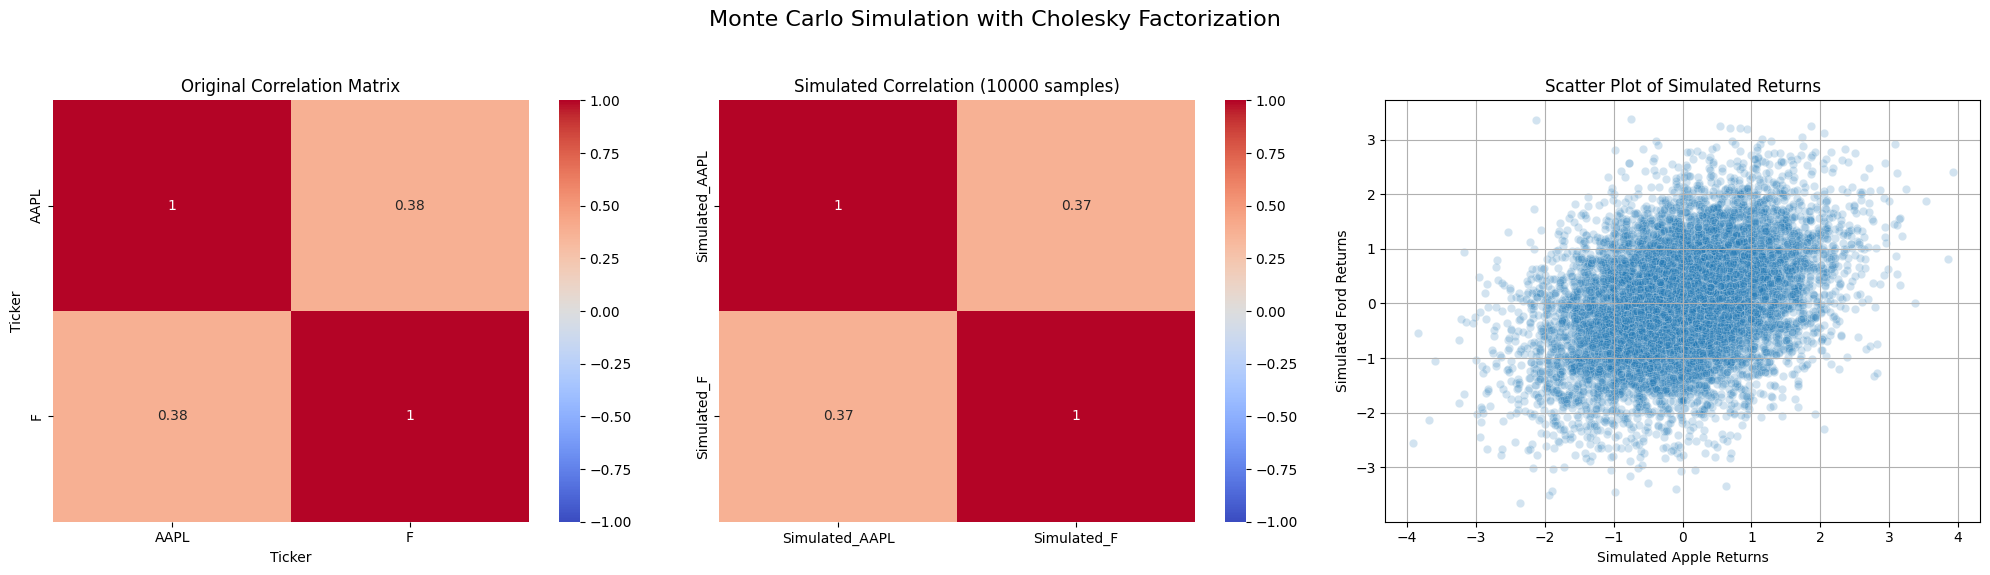

In [75]:
# === 6.4 Visualizing the Results ===

# Create a figure with three subplots for a comprehensive comparison.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Monte Carlo Simulation with Cholesky Factorization', fontsize=16)


# --- Plot 1: Original Correlation Matrix ---
sns.heatmap(original_correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax1)
ax1.set_title('Original Correlation Matrix')


# --- Plot 2: Sample Correlation Matrix ---
sns.heatmap(sample_correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax2)
ax2.set_title(f'Simulated Correlation ({n_samples} samples)')


# --- Plot 3: Scatter Plot of Simulated Returns ---
sns.scatterplot(x="Simulated_AAPL", y="Simulated_F", data=simulated_returns_df, alpha=0.2, ax=ax3)
ax3.set_title('Scatter Plot of Simulated Returns')
ax3.set_xlabel('Simulated Apple Returns')
ax3.set_ylabel('Simulated Ford Returns')
ax3.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

## **5. Conclusion**

In this lesson, we explored several special types of matrices and the linear algebra tools that are fundamental to financial analysis.

-   We began with **Symmetric Matrices**, understanding their properties and seeing their direct application in the form of **covariance and correlation matrices**. We demonstrated how to diagonalize a symmetric matrix, a process that simplifies complex systems and is a prerequisite for many advanced techniques.

-   We then introduced **Triangular Matrices**, noting their computational efficiency, which makes them key components in matrix decompositions.

-   We defined **Symmetric Positive Definite (PD)** and **Positive Semidefinite (PSD)** matrices, learning to test for these properties using eigenvalues. This is a critical concept, as many financial models and optimization routines require matrices to have these characteristics to guarantee stable and meaningful solutions.

-   Finally, we culminated the lesson with **Cholesky Factorization**, a powerful and efficient method for decomposing a symmetric positive definite matrix. We demonstrated its most important application: **generating correlated random variables** for use in Monte Carlo simulations, a cornerstone of quantitative risk management and asset pricing.

A firm grasp of these special matrices is essential for tackling the more advanced financial analysis tools we will encounter in future lessons.

**References**

-   Axler, Sheldon. *Linear Algebra Done Right*. 4th edition, Springer, 2024.

MODULE 3 | LESSON 1
---

# **Portfolio Returns and Variance**

| | |
|:---|:---|
|**Reading Time** | 2 hours |
|**Prior Knowledge** | Python, returns, variance, diversification |
|**Keywords** | Returns, Logarithmic, Percent, Matrix Notation, Distribution, Annualize, Geometric Mean, Arithmetic Mean, Portfolio Variance, Correlation, Weights|

---

*In this lesson, we'll explore various types of returns, methods for annualizing returns, and techniques for calculating portfolio variance. The lesson aims to provide a comprehensive understanding of how to measure and interpret portfolio performance, considering both returns and risk.*

*We'll start by examining different types of returns, including percentage and logarithmic returns, and discuss their properties and appropriate use cases. We'll then move on to methods for annualizing returns, which is crucial for comparing investments over different time periods. The lesson will also cover portfolio variance calculation, exploring how individual asset variances, weights, and correlations contribute to overall portfolio risk.*

## **1. Portfolio Returns**

In Financial Markets, you were introduced to asset and portfolio returns. In this course, we will explore both one-dimensional and multi-dimensional datasets. Therefore, matrix representations from linear algebra will be our primary tool.

The return of a portfolio with $n$ assets is the weighted average of the individual asset returns:
$$
r_{p} = \sum_{i=1}^{n} w_{i} \cdot r_{i}
$$
where $r_p$ is the portfolio return, $r_i$ is the return of asset $i$, and $w_i$ is the weight (proportion) of asset $i$ in the portfolio.

We will use the following constraints:
1.  **Weights sum to one**: $\sum_{i=1}^{n} w_{i} = 1$ (The entire capital is invested).
2.  **No shorting**: $w_{i} \ge 0$ (All weights are positive).

In matrix notation, which we will use throughout this lesson, the portfolio return is:
$$ r_{p} = \mathbf{r} \cdot \mathbf{w} $$
with
$$ \mathbf{r} = \begin{bmatrix} r_1 & r_2 & \dots & r_n \end{bmatrix} \quad , \quad \mathbf{w} = \begin{bmatrix} w_1 \\ w_2 \\ \vdots \\ w_n \end{bmatrix} $$
where each $r_i$ is a time-series vector of returns for that asset.

Let's start by downloading the necessary data.

In [76]:
# === 1. Environment Setup ===
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import time # Import the time library for handling rate limits

sns.set()
pd.options.display.float_format = "{:,.6f}".format

In [77]:
# === 2. Data Retrieval and Preparation ===

# --- Portfolio Parameters ---
assets = ['MSFT', 'AAPL', 'AMZN', 'TSLA', 'GOOGL'] # Assets for portfolio
weights = np.array([0.1, 0.2, 0.1, 0.4, 0.2])     # Weights of each asset

# --- Data Download with Error Handling ---
# yfinance can be rate-limited. We'll add a retry mechanism.
asset_prices = None
for i in range(5): # Try up to 5 times
    try:
        asset_prices = yf.download(
            assets,
            start='2018-01-01',
            end='2023-01-01',
            auto_adjust=False
        )['Adj Close']

        # Check if the download was successful (not empty)
        if not asset_prices.empty:
            print("Successfully downloaded asset prices.")
            break # Exit the loop if download is successful
    except Exception as e:
        print(f"Attempt {i+1} failed: {e}. Retrying in 5 seconds...")
        time.sleep(5)

# --- Data Validation and Processing ---
if asset_prices is None or asset_prices.empty:
    print("\nCould not download data after multiple attempts. Please check your connection or tickers.")
    # In a real script, you might raise an error here. For the notebook, we'll stop.
else:
    # Ensure the index is a datetime object.
    asset_prices.index = pd.to_datetime(asset_prices.index)

    # Calculate daily percent returns and drop the initial NaN row.
    r = asset_prices.pct_change().dropna()
    print("Calculated daily percentage returns:")
    display(r.head())

[*********************100%***********************]  5 of 5 completed

Successfully downloaded asset prices.
Calculated daily percentage returns:


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2018-01-03,-0.000174,0.012775,0.017061,0.004654,-0.010233
2018-01-04,0.004645,0.004476,0.003884,0.008801,-0.008290
2018-01-05,0.011385,0.016163,0.013260,0.012398,0.006230
2018-01-08,-0.003714,0.014425,0.003531,0.001021,0.062638
2018-01-09,-0.000115,0.004676,-0.001274,-0.000680,-0.008085


In [78]:
# === 2.1 Portfolio Return Calculation ===

# Calculate the daily returns of the portfolio using matrix multiplication (dot product).
# The result is a new pandas Series.
if 'r' in locals(): # Check if the 'r' DataFrame exists from the previous cell
    r_port = r @ weights
    r_port.name = 'portfolio_returns'

    print("Daily returns for the weighted portfolio:")
    display(r_port.head())

    print("\nStatistical summary of portfolio daily returns:")
    display(r_port.describe())
else:
    print("Return data ('r') not available. Please run the previous cell successfully.")

Daily returns for the weighted portfolio:


,portfolio_returns
Date,
2018-01-03,0.004059
2018-01-04,0.003611
2018-01-05,0.011902
2018-01-08,0.015802
2018-01-09,-0.001093



Statistical summary of portfolio daily returns:


,portfolio_returns
count,"1,258.000000"
mean,0.001150
std,0.020275
min,-0.131350
25%,-0.008370
50%,0.002112
75%,0.011924
max,0.090070


**Exercise 1:**

Use your favorite finance textbook and online resources in researching the constraint $\sum_{i=1}^{n} w_{i} = 1$. What would it mean for a portfolio if $\sum_{i=1}^{n} w_{i} = 2$? What about if $\sum_{i=1}^{n} w_{i} = 0$? Initiate a discussion in the forum explaining your understanding.

## **2. Types of Returns**

In the example above, we calculated **percentage returns**. However, **logarithmic returns** are also widely used in quantitative finance. It is critical to understand the properties of each and when to use them.

### **2.1 Percentage Returns (Arithmetic)**

Percentage returns (or simple/arithmetic returns) are intuitive and represent the direct percentage change in value.

$$ r_{pct, t} = \frac{P_t - P_{t-1}}{P_{t-1}} $$

-   **Advantage:** They are intuitive and are **cross-sectionally additive**. This means the percentage return of a portfolio is the weighted average of the percentage returns of its assets, which is exactly what we calculated in the previous step. This is why they are the standard for portfolio return calculations.
-   **Disadvantage:** They are **not time-additive**. You cannot simply sum daily returns to get a weekly or monthly return because of the effect of compounding.

The lack of time-additivity is easy to see. If an asset gains 20% in month one (from \$100 to \$120) and then loses 18% in month two (from \$120 to \$98.40), simply adding the returns (20% - 18% = 2%) gives an incorrect picture of the final outcome, which was a loss.

---
**Exercise 2:**

Create a custom function in Python that, given a price series (e.g., `asset_prices['MSFT']`), returns the series of arithmetic returns. You are not allowed to use any existing pandas or numpy functions for calculating percentage change. Cross-check your results with those from the `.pct_change()` pandas function.

### **2.2 Logarithmic Returns (Continuously Compounded)**

Logarithmic returns (or log returns) are defined using the natural logarithm.

$$ r_{\log, t} = \ln \left( \frac{P_t}{P_{t-1}} \right) $$

-   **Advantage:** They are **time-additive**. The log return over a multi-period horizon is simply the sum of the single-period log returns. This makes them ideal for modeling the performance of a single asset over time and is a key property used in many statistical and stochastic models (e.g., geometric Brownian motion).
-   **Disadvantage:** They are **not cross-sectionally additive**. You cannot take a weighted average of the log returns of several assets to get the portfolio's log return.

Log returns are also symmetric. A move from \$100 to \$120 gives a log return of $\ln(1.2) \approx 0.1823$, while a move from \$120 back to \$100 gives a log return of $\ln(100/120) \approx -0.1823$.

---
**Exercise 3:**

Create a custom function in Python that, given a price series (e.g., `asset_prices['MSFT']`), returns the series of logarithmic returns.

### **2.3 Relationship Between Return Types**

The relationship between log and percent returns is given by:
$$ r_{\log} = \ln(1 + r_{pct}) $$

Using a Taylor expansion, we can approximate this relationship:
$$ r_{\log} \approx r_{pct} - \frac{r_{pct}^2}{2} + \dots $$

This shows two important facts:
1.  When returns are small (as they often are for daily data), $r_{pct}^2$ is very small, and therefore **log returns and percent returns will be very close in value**.
2.  As the return period gets longer (e.g., monthly, yearly), the returns get larger, and the difference between the two types becomes more significant.

Let's visualize this. The plot below shows that the difference between the 15-day rolling average of MSFT's log and percent returns is close to zero during normal periods but widens significantly during periods of high volatility (like the COVID-19 crash in March 2020), when daily returns are larger.

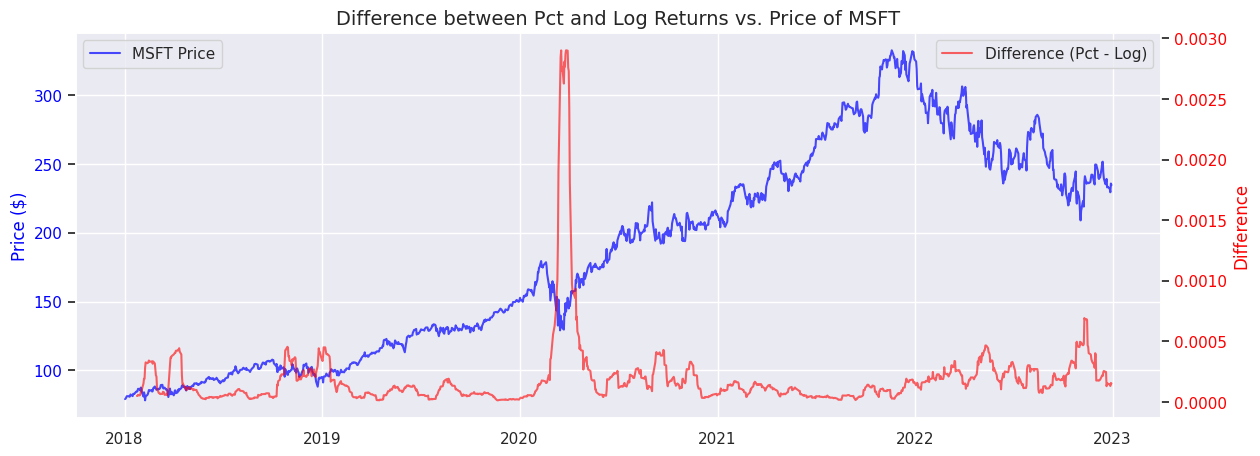

In [79]:
# === 3.1 Visualizing the Difference Between Return Types ===

if 'asset_prices' in locals():
    # Calculating daily pct returns for MSFT
    pct_returns_msft = asset_prices['MSFT'].pct_change().dropna()

    # Calculating daily log returns for MSFT
    log_returns_msft = np.log(asset_prices['MSFT'] / asset_prices['MSFT'].shift(1)).dropna()

    # Calculate the 15-day rolling average of both return types
    pct_change_msft_roll_mean = pct_returns_msft.rolling(15).mean()
    log_returns_msft_roll_mean = log_returns_msft.rolling(15).mean()

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.set_title('Difference between Pct and Log Returns vs. Price of MSFT', fontsize=14)

    # Plot the MSFT price on the primary y-axis
    ax.plot(asset_prices['MSFT'], label='MSFT Price', alpha=0.7, color='blue')
    ax.set_ylabel('Price ($)', color='blue')
    ax.tick_params(axis='y', labelcolor='blue')
    ax.legend(loc='upper left')

    # Create a secondary y-axis to plot the difference
    ax2 = ax.twinx()
    difference = pct_change_msft_roll_mean - log_returns_msft_roll_mean
    ax2.plot(difference, color='red', alpha=0.6, label='Difference (Pct - Log)')
    ax2.set_ylabel('Difference', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')

    plt.grid(False) # Turn off the grid from the secondary axis for clarity
    plt.show()
else:
    print("Price data not available. Please run the data download cell successfully.")

## **3. Comparing Geometric and Arithmetic Returns**

When we need to find the average return of a single asset *over multiple time periods*, we must account for the effect of **compounding**. This section will demonstrate why the **geometric mean** is the correct choice for averaging simple percentage returns over time, and how the **arithmetic mean** is correctly used with log returns.

### **3.1 The Flaw of Using the Arithmetic Mean on Percent Returns**

Let's use a simple example. An investment of $100 has a +20% return in period 1 and a -18% return in period 2.

-   **Arithmetic Mean:** `(20% - 18%) / 2 = +1%`. This suggests an average gain of 1% per period.
-   **Actual Result:**
    -   Period 1: `$100 * (1 + 0.20) = $120`
    -   Period 2: `$120 * (1 - 0.18) = $98.40`
-   The actual result is a **loss**, but the arithmetic mean incorrectly suggests a gain. This is because it ignores compounding.

The **geometric mean** correctly captures the compounded growth rate.

$$ r_{\text{GeomMean}} = \left( \prod_{i=1}^{n} (1 + r_{pct, i}) \right)^{\frac{1}{n}} - 1 $$

For our example:
$$ r_{\text{GeomMean}} = \sqrt{(1 + 0.20) × (1 - 0.18)} - 1 = \sqrt{0.984} - 1 \approx -0.8\% $$

This average rate of -0.8% per period correctly reflects the final value: $100 \times (1 - 0.008)^2 \approx $98.40.

**Key Takeaway:** For a single asset's performance over time, use the geometric mean for percentage returns to find the true average compound growth rate.

### **3.2 The Correct Use of the Arithmetic Mean with Log Returns**

Interestingly, the **arithmetic mean** *is* the correct average to use for **logarithmic returns** over time. Because log returns are time-additive, their simple arithmetic average represents the average continuously compounded rate.

Let's re-do the example with log returns:
-   $r_{\log, 1} = \ln(1.20) \approx 0.1823$
-   $r_{\log, 2} = \ln(0.82) \approx -0.1985$

The arithmetic mean of these log returns is:
$$ \bar{r}_{\log} = \frac{0.1823 - 0.1985}{2} \approx -0.0081 $$

Notice that `exp(-0.0081) - 1` is approximately `-0.8%`, which is the same as the geometric mean of the simple returns. This confirms the following important relationship:

$$ \ln(1 + r_{\text{GeomMean}}) = \bar{r}_{\log} $$
(The logarithm of the geometric growth factor is equal to the arithmetic mean of the log returns).

---
**Exercise 8:**

Using the properties of the logarithm, show that the log returns are indeed continuously compounded. Then, prove the relationship shown above:
$$ \ln(r_{\text{GeomMean}} + 1) = \frac{1}{n}\sum_{t=1}^{n} r^{t}_{\text{log}} $$

Let's verify this relationship using our real-world data.

In [80]:
# === 3.2 Verifying the Mean Relationship with Real Data ===

# We'll use a volatile period for TSLA to highlight the difference.
if 'asset_prices' in locals() and not asset_prices.empty:
    # --- Using Percent Returns and Geometric Mean ---
    # 1. Get the daily percent returns for TSLA in a specific period.
    pct_returns_tsla = asset_prices['TSLA'].loc["2020-06-01":"2020-09-30"].pct_change().dropna()

    # 2. Calculate the geometric mean return.
    geom_mean_tsla = ((1 + pct_returns_tsla).prod() ** (1 / len(pct_returns_tsla))) - 1

    # 3. Take the log of the result (plus 1).
    log_of_geom_mean = np.log(1 + geom_mean_tsla)

    # --- Using Log Returns and Arithmetic Mean ---
    # 1. Get the daily log returns for the same period.
    log_returns_tsla = np.log(asset_prices['TSLA'].loc["2020-06-01":"2020-09-30"]).diff().dropna()

    # 2. Calculate the arithmetic mean of the log returns.
    arith_mean_of_log = log_returns_tsla.mean()

    # --- Comparison ---
    print(f"Log of (1 + Geometric Mean of Pct Returns): {log_of_geom_mean:.6f}")
    print(f"Arithmetic Mean of Log Returns:             {arith_mean_of_log:.6f}")
    print(f"\nAre the two values equal? {np.isclose(log_of_geom_mean, arith_mean_of_log)}")
else:
    print("Price data not available. Please run the data download cell successfully.")

Log of (1 + Geometric Mean of Pct Returns): 0.010243
Arithmetic Mean of Log Returns:             0.010243

Are the two values equal? True


## **4. Annualizing Returns**

Annualizing returns is crucial for comparing investments on a common time scale. The method for annualizing depends on the type of return we are using.

### **4.1 Annualizing Percentage Returns**

To annualize percentage returns, we must use the **geometric mean** to correctly account for compounding. The process is:
1.  Calculate the geometric mean of the daily percentage returns ($\bar{r}_{\text{GeomMean}}$).
2.  Compound this average daily return over the number of trading periods in a year (e.g., 252 for stocks).

$$ R_{\text{Annual}} = (1 + \bar{r}_{\text{GeomMean}})^N - 1 $$

Where $N$ is the number of periods in a year.

### **4.2 Annualizing Logarithmic Returns**

Annualizing log returns is simpler due to their time-additive property.
1.  Calculate the arithmetic mean of the daily log returns ($\bar{r}_{\text{log}}$).
2.  Multiply this average by the number of trading periods in a year.

$$ R_{\text{Annual, Log}} = N \cdot \bar{r}_{\text{log}} $$

This gives the *annualized log return*. To convert it back to an annualized percentage return for easier interpretation, we exponentiate:

$$ R_{\text{Annual}} = e^{N \cdot \bar{r}_{\text{log}}} - 1 $$

Let's calculate the annualized returns for all assets in our portfolio using both methods. The results should be very similar.

In [81]:
# === 4.1 Annualizing Daily Returns ===

if 'r' in locals():
    # Number of trading days in a year.
    N = 252

    # --- Method 1: Annualize using Percentage Returns ---
    # We add 1 to each return, take the product, find the Nth root, then subtract 1.
    # This is the formula for the geometric mean, compounded over N periods.
    # Note: stats.gmean can be unstable with negative returns, so we use the product formula.
    annual_pct_returns = ((1 + r).prod() ** (N / len(r))) - 1


    # --- Method 2: Annualize using Logarithmic Returns ---
    # First, calculate the log returns from the original prices.
    log_r = np.log(asset_prices).diff().dropna()

    # We take the arithmetic mean of daily log returns and multiply by N.
    # Then exponentiate to convert back to a simple percentage.
    annual_log_returns = np.exp(log_r.mean() * N) - 1

    # --- Create a comparison DataFrame ---
    annual_returns_df = pd.DataFrame({
        'Pct_Return_Annualized': annual_pct_returns,
        'Log_Return_Annualized': annual_log_returns
    })

    # Add a column for the difference.
    annual_returns_df['Difference'] = annual_returns_df['Pct_Return_Annualized'] - annual_returns_df['Log_Return_Annualized']


    print("--- Annualized Returns Comparison ---")
    display(annual_returns_df.applymap(lambda x: f"{x:.2%}"))

else:
    print("Return data not available. Please run the data download cell successfully.")

--- Annualized Returns Comparison ---


/tmp/ipython-input-1329768707.py:33: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(annual_returns_df.applymap(lambda x: f"{x:.2%}"))


,Pct_Return_Annualized,Log_Return_Annualized,Difference
Ticker,,,
AAPL,26.02%,26.02%,-0.00%
AMZN,7.17%,7.17%,0.00%
GOOGL,10.47%,10.47%,-0.00%
MSFT,24.31%,24.31%,-0.00%
TSLA,42.03%,42.03%,0.00%


## **5. Portfolio Variance**

### **5.1 Calculating Portfolio Variance**

While we care about a portfolio's return, we also care deeply about its risk, or **volatility**. The variance (and its square root, the standard deviation) is the standard measure for this.

One simple way to find the portfolio's variance is to first calculate the time series of the portfolio's returns (as we did in Cell 7) and then calculate the variance of that series directly.

However, this direct method doesn't tell us *why* the portfolio has that level of risk. A more powerful approach is to calculate portfolio variance from its fundamental components: the weights, the individual asset variances, and the covariances between assets.

The formula in matrix notation is:
$$ \sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w} $$

Where:
-   $\mathbf{w}$ is the column vector of portfolio weights.
-   $\mathbf{w}^T$ is its transpose (a row vector).
-   $\Sigma$ is the **covariance matrix** of the asset returns.

This formula is the cornerstone of Modern Portfolio Theory. It allows us to see how the interactions between assets (their covariances) contribute to the overall portfolio risk. Let's verify that this formula gives the same result as our direct calculation.

In [82]:
# === 5.2 Portfolio Volatility (Matrix Formula) ===

if 'r' in locals():
    # Calculate the daily covariance matrix of the individual asset returns.
    cov_matrix = r.cov()

    # Calculate portfolio variance using the matrix formula: wT * Sigma * w
    port_var_formula = weights.T @ cov_matrix @ weights
    port_std_formula = np.sqrt(port_var_formula)

    print("--- Portfolio Volatility (Matrix Formula) ---")
    print(f"Portfolio Daily Variance: {port_var_formula:.6f}")
    print(f"Portfolio Daily Std Dev:  {port_std_formula:.6f}")

    # Annualize the results
    annual_port_variance = port_var_formula * 252
    annual_port_std = port_std_formula * np.sqrt(252)

    print(f"\nAnnualized Portfolio Variance: {annual_port_variance:.4f}")
    print(f"Annualized Portfolio Std Dev (Volatility): {annual_port_std:.2%}")
else:
    print("Return data ('r') not available.")

--- Portfolio Volatility (Matrix Formula) ---
Portfolio Daily Variance: 0.000411
Portfolio Daily Std Dev:  0.020275

Annualized Portfolio Variance: 0.1036
Annualized Portfolio Std Dev (Volatility): 32.19%


### **5.2 The Role of Covariance and Correlation**

The matrix formula $\sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w}$ elegantly shows that portfolio variance is composed of three things: asset **weights**, individual asset **variances** (the diagonal of $\Sigma$), and the **covariances** between assets (the off-diagonals of $\Sigma$).

To make the role of correlation more explicit, we can decompose the covariance matrix $\Sigma$:
$$ \Sigma = D R D $$
Where:
-   $D$ is a diagonal matrix of the asset standard deviations.
-   $R$ is the correlation matrix of the assets.

Substituting this into our variance formula gives:
$$ \sigma_p^2 = \mathbf{w}^T (D R D) \mathbf{w} $$

This shows that portfolio variance depends directly on the pairwise correlations between assets. Let's analyze this relationship.

### **5.3 Impact of Correlation on Portfolio Variance**

Let's expand the variance formula into its summation form:
$$ \sigma_p^2 = \sum_{i=1}^{n} w_i^2 \sigma_i^2 + \sum_{i=1}^{n}\sum_{j \neq i}^{n} w_i w_j \text{Cov}(r_i, r_j) $$

By substituting $\text{Cov}(r_i, r_j) = \rho_{ij} \sigma_i \sigma_j$, we get:
$$ \sigma_p^2 = \sum_{i=1}^{n} w_i^2 \sigma_i^2 + \sum_{i=1}^{n}\sum_{j \neq i}^{n} w_i w_j \rho_{ij} \sigma_i \sigma_j $$

To see how variance changes with correlation, we can take the partial derivative of $\sigma_p^2$ with respect to a single correlation coefficient, $\rho_{ij}$:
$$ \frac{\partial \sigma_p^2}{\partial \rho_{ij}} = w_i w_j \sigma_i \sigma_j $$
Since weights ($w_i$) and standard deviations ($\sigma_i$) are positive, this derivative is **always positive**.

**This is the mathematical proof of diversification:**
> Keeping all else constant, **decreasing the correlation** between assets will **always decrease the total portfolio variance**. This is why combining uncorrelated or negatively correlated assets is so powerful for reducing risk.

Let's visualize these effects with our portfolio.

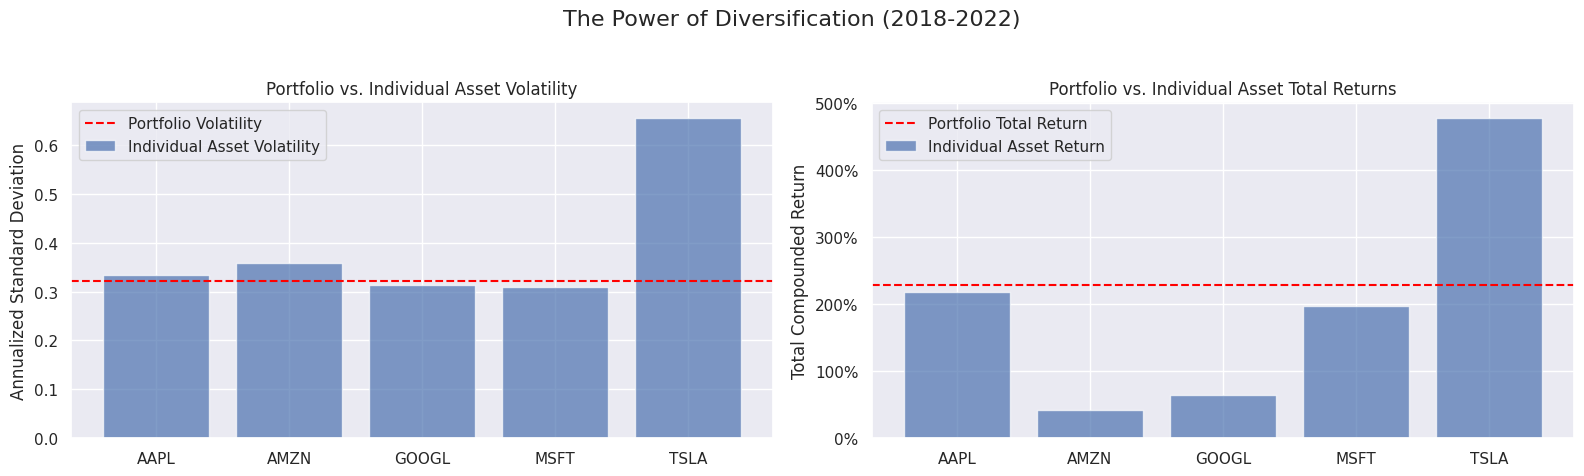

In [83]:
# === 5.3 Visualization: Diversification Effect on Volatility and Return ===

if 'r' in locals() and 'r_port' in locals():
    # --- Calculate Annualized Stats for Plotting ---
    # Individual asset stats (annualized)
    annualized_std = r.std() * np.sqrt(252)
    # Using the geometric mean for the most accurate compounded return
    total_compounded_return = (1 + r).prod() - 1

    # Portfolio stats (annualized)
    portfolio_annual_std = r_port.std() * np.sqrt(252)
    portfolio_total_return = (1 + r_port).prod() - 1

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('The Power of Diversification (2018-2022)', fontsize=16)


    # --- Plot 1: Volatility ---
    ax1.bar(r.columns, annualized_std, alpha=0.7, label='Individual Asset Volatility')
    ax1.axhline(y=portfolio_annual_std, linestyle="--", color='red', label="Portfolio Volatility")
    ax1.set_title("Portfolio vs. Individual Asset Volatility")
    ax1.set_ylabel("Annualized Standard Deviation")
    ax1.legend()


    # --- Plot 2: Total Return ---
    ax2.bar(r.columns, total_compounded_return, alpha=0.7, label='Individual Asset Return')
    ax2.axhline(y=portfolio_total_return, linestyle="--", color='red', label="Portfolio Total Return")
    ax2.set_title("Portfolio vs. Individual Asset Total Returns")
    ax2.set_ylabel("Total Compounded Return")
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}')) # Format y-axis as percentage
    ax2.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("Return data not available. Please run the required cells.")

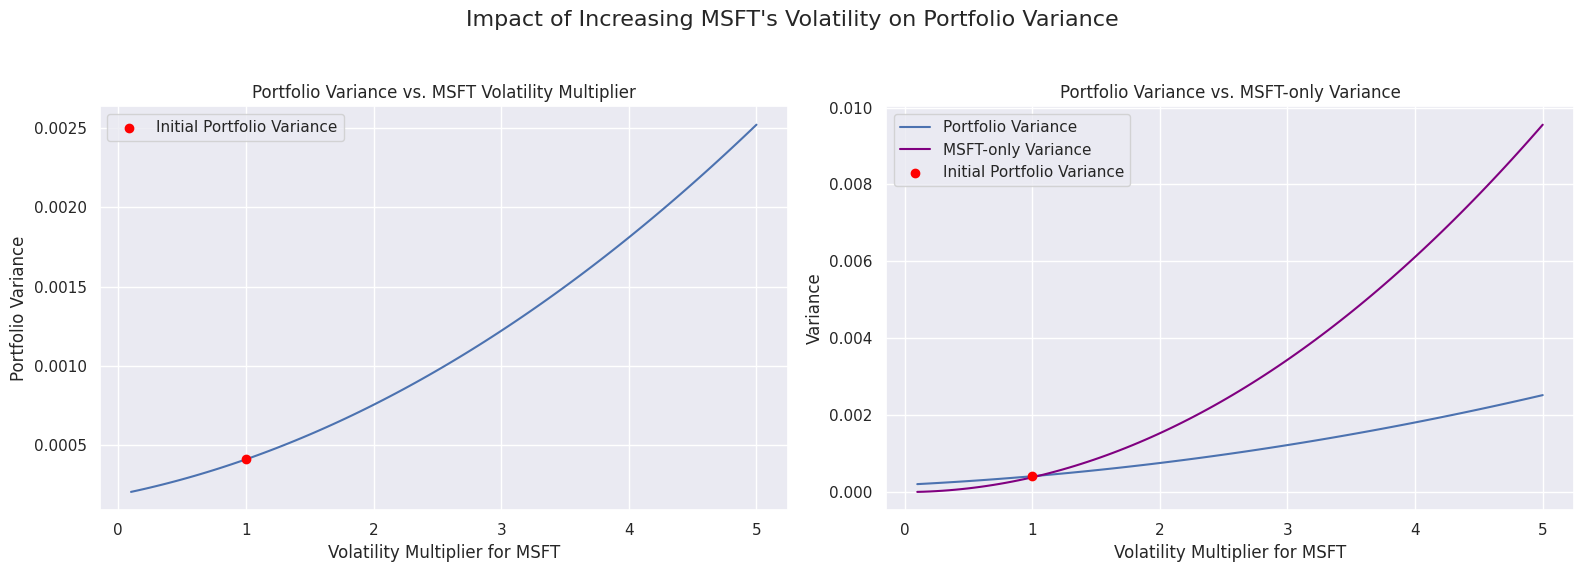

In [84]:
# === 5.4 Simulation: Impact of a Single Asset's Variance ===

if 'r' in locals():
    # --- Simulation Setup ---
    # Create an array of multipliers to scale MSFT's returns.
    multipliers = np.linspace(0.1, 5, 100)
    portfolio_variances = []
    msft_variances = []

    for multiplier in multipliers:
        # Create a temporary copy of the returns DataFrame.
        temp_returns = r.copy()
        # Scale only the MSFT returns. This increases its volatility
        # but does NOT change its correlation with the other assets.
        temp_returns['MSFT'] = temp_returns['MSFT'] * multiplier

        # Recalculate the covariance matrix with the scaled MSFT returns.
        temp_cov_matrix = temp_returns.cov()

        # Calculate the new portfolio variance.
        temp_port_variance = weights.T @ temp_cov_matrix @ weights
        portfolio_variances.append(temp_port_variance)

        # Store the variance of the scaled MSFT for comparison.
        msft_variances.append(temp_returns['MSFT'].var())


    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Impact of Increasing MSFT's Volatility on Portfolio Variance", fontsize=16)

    # --- Plot 1: Full Range ---
    ax1.plot(multipliers, portfolio_variances)
    ax1.scatter(1, port_var_formula, color='red', zorder=5, label="Initial Portfolio Variance")
    ax1.set_title("Portfolio Variance vs. MSFT Volatility Multiplier")
    ax1.set_xlabel("Volatility Multiplier for MSFT")
    ax1.set_ylabel("Portfolio Variance")
    ax1.legend()
    ax1.grid(True)

    # --- Plot 2: Zoomed-in Comparison ---
    # Zoom in on a smaller range of multipliers to see the relationship clearly.
    ax2.plot(multipliers, portfolio_variances, label="Portfolio Variance")
    ax2.plot(multipliers, msft_variances, color='purple', label="MSFT-only Variance")
    ax2.scatter(1, port_var_formula, color='red', zorder=5, label="Initial Portfolio Variance")
    ax2.set_title("Portfolio Variance vs. MSFT-only Variance")
    ax2.set_xlabel("Volatility Multiplier for MSFT")
    ax2.set_ylabel("Variance")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("Return data not available.")

The plots clearly show the effect of increasing the variance of a single asset.
-   The left graph shows that the relationship between a single asset's variance and the total portfolio variance is **quadratic**, as predicted by the formula.
-   The right graph is even more powerful. It shows that even as MSFT's own variance (purple line) increases dramatically, the total portfolio variance (blue line) increases much more slowly. This is the **risk-dampening effect of diversification** in action.

Next, let's simulate how changing the **overall correlation structure** affects portfolio variance. In this simulation, we will keep the individual asset variances and weights constant, but we will generate synthetic correlation matrices where the average correlation between assets steadily increases.

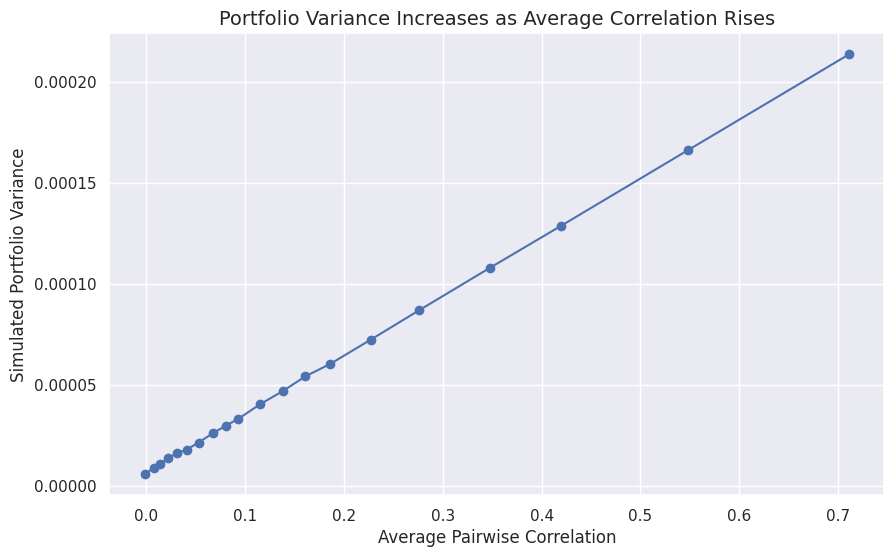

In [85]:
# === 5.5 Simulation: Impact of Average Correlation ===

np.random.seed(42) # for reproducibility
n_assets = 100

# Simulate weights that sum to 1.
weights_sim = np.random.dirichlet(np.ones(n_assets), size=1)[0]

# Simulate realistic-looking standard deviations for each asset.
std_devs_sim = np.random.uniform(0.15, 0.40, n_assets) / np.sqrt(252)
D_sim = np.diag(std_devs_sim)

# --- Construct Correlation Matrices with Increasing Average Correlation ---
portfolio_variances_corr = []
avg_correlations = []

for j in range(20): # Create 20 matrices
    # The lower bound of the random correlation moves from -1 towards +1.
    low_boundary = -1.0 + j * 0.1
    # Create a matrix of random numbers in the range [low_boundary, 1].
    R_rand = np.random.uniform(low_boundary, 1.0, size=(n_assets, n_assets))
    # Make the matrix symmetric by adding its transpose and dividing by 2.
    R_symm = (R_rand + R_rand.T) / 2
    # Set the diagonal to 1.
    np.fill_diagonal(R_symm, 1)

    # *** CRITICAL STEP: Ensure the matrix is Positive Semidefinite ***
    # Randomly generated matrices are not guaranteed to be valid correlation matrices.
    # We "nudge" it to be PSD by adding a small multiple of the identity matrix
    # if it has negative eigenvalues. This is a common technique.
    eigenvalues = np.linalg.eigvalsh(R_symm)
    if eigenvalues.min() < 0:
        # Nudge the diagonal to make eigenvalues positive
        R_symm -= eigenvalues.min() * np.eye(n_assets)
        # Rescale to have 1s on the diagonal again
        R_symm /= np.diag(R_symm)[:, np.newaxis]

    # Calculate the portfolio variance for this correlation matrix.
    portfolio_variance = weights_sim.T @ D_sim @ R_symm @ D_sim @ weights_sim
    portfolio_variances_corr.append(portfolio_variance)

    # Store the average off-diagonal correlation for plotting.
    np.fill_diagonal(R_symm, np.nan) # Exclude diagonal from mean calculation
    avg_correlations.append(np.nanmean(R_symm))

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(avg_correlations, portfolio_variances_corr, marker='o')
plt.title("Portfolio Variance Increases as Average Correlation Rises", fontsize=14)
plt.xlabel("Average Pairwise Correlation")
plt.ylabel("Simulated Portfolio Variance")
plt.grid(True)
plt.show()

## **6. Portfolio Weights and the Efficient Frontier**

So far, we have used a fixed set of weights for our portfolio. But how do investors choose these weights in the first place? This decision depends on their **risk tolerance**. Some investors prefer low-risk, stable assets like bonds, while others seek higher returns from riskier assets like stocks or crypto.

**Modern Portfolio Theory (MPT)** provides a mathematical framework for this problem. A key output of MPT is the **Efficient Frontier**, a graph that plots the optimal portfolios for every possible level of risk.

-   The efficient frontier represents the set of portfolios that offer the **highest possible expected return for a given level of risk** (measured by standard deviation).
-   Conversely, for any given level of expected return, a portfolio on the frontier offers the **lowest possible risk**.

Any portfolio that does not lie on the frontier is "sub-optimal" because either a higher return could be achieved for the same risk, or the same return could be achieved with lower risk. Let's construct the efficient frontier for our 5-asset portfolio.

In [86]:
# === 6.1 Efficient Frontier: Helper Functions ===

def get_portfolio_stats(weights, expected_returns, cov_matrix):
    """Calculates the annualized portfolio return and volatility."""
    portfolio_return = np.sum(weights * expected_returns)
    portfolio_volatility = np.sqrt(weights.T @ cov_matrix @ weights)
    return portfolio_return, portfolio_volatility

def negative_sharpe_ratio(weights, expected_returns, cov_matrix, risk_free_rate=0.02):
    """Calculates the negative Sharpe ratio for optimization."""
    port_ret, port_std = get_portfolio_stats(weights, expected_returns, cov_matrix)
    return -(port_ret - risk_free_rate) / port_std

def minimize_portfolio_volatility(weights, expected_returns, cov_matrix):
    """Objective function to minimize portfolio volatility."""
    return get_portfolio_stats(weights, expected_returns, cov_matrix)[1]

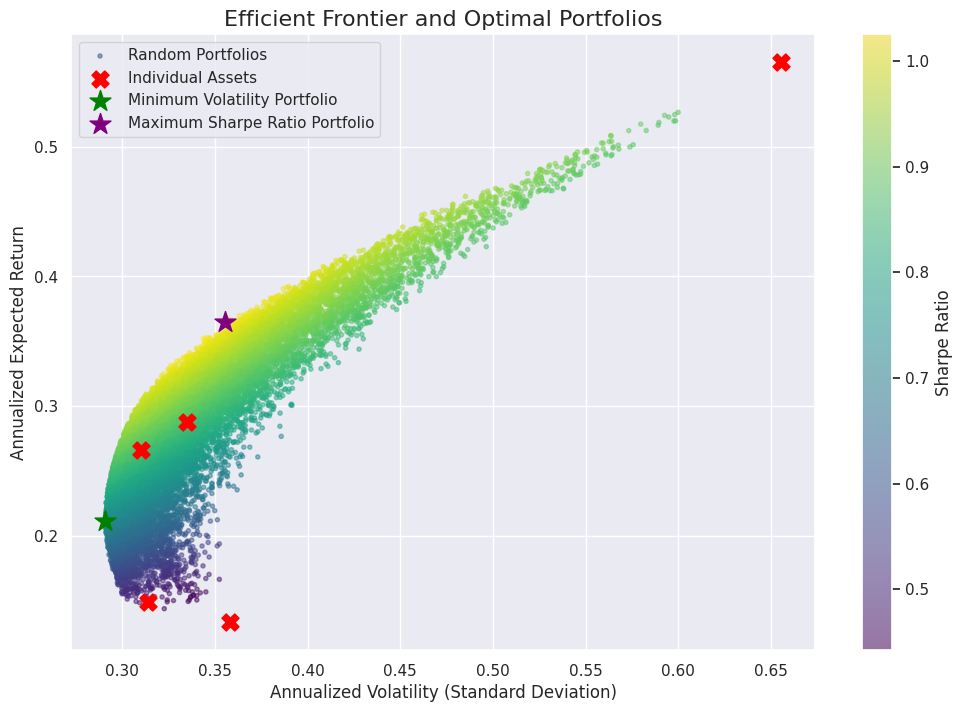

In [87]:
# === 6.2 Efficient Frontier: Calculation and Visualization ===

if 'r' in locals():
    # --- Annualize the inputs for our model ---
    expected_returns = r.mean() * 252
    cov_matrix = r.cov() * 252
    n_assets = len(assets)
    risk_free_rate = 0.02

    # --- Generate thousands of random portfolios (for the scatter plot background) ---
    np.random.seed(42)
    num_portfolios = 20000
    random_weights = np.random.dirichlet(np.ones(n_assets), size=num_portfolios)

    results = np.zeros((2, num_portfolios))
    for i, w in enumerate(random_weights):
        results[0, i], results[1, i] = get_portfolio_stats(w, expected_returns, cov_matrix)

    # --- Find the Optimal Portfolios using scipy.optimize.minimize ---
    # Define constraints (weights sum to 1) and bounds (each weight is between 0 and 1).
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    initial_guess = np.ones(n_assets) / n_assets

    # 1. Minimum Volatility Portfolio
    min_vol_result = minimize(
        fun=minimize_portfolio_volatility,
        x0=initial_guess,
        args=(expected_returns, cov_matrix),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    min_vol_ret, min_vol_std = get_portfolio_stats(min_vol_result.x, expected_returns, cov_matrix)

    # 2. Maximum Sharpe Ratio Portfolio (the "Optimal" portfolio)
    max_sharpe_result = minimize(
        fun=negative_sharpe_ratio,
        x0=initial_guess,
        args=(expected_returns, cov_matrix, risk_free_rate),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    max_sharpe_ret, max_sharpe_std = get_portfolio_stats(max_sharpe_result.x, expected_returns, cov_matrix)


    # --- Plotting ---
    plt.figure(figsize=(12, 8))

    # Plot the random portfolios.
    plt.scatter(results[1, :], results[0, :], c=results[0, :]/results[1, :], cmap='viridis', marker='.', alpha=0.5, label='Random Portfolios')
    plt.colorbar(label='Sharpe Ratio')

    # Plot the individual assets.
    plt.scatter(np.sqrt(np.diag(cov_matrix)), expected_returns, marker='X', color='red', s=150, label='Individual Assets')

    # Plot the optimal portfolios.
    plt.scatter(min_vol_std, min_vol_ret, marker='*', color='green', s=250, label='Minimum Volatility Portfolio')
    plt.scatter(max_sharpe_std, max_sharpe_ret, marker='*', color='purple', s=250, label='Maximum Sharpe Ratio Portfolio')

    plt.title("Efficient Frontier and Optimal Portfolios", fontsize=16)
    plt.xlabel("Annualized Volatility (Standard Deviation)")
    plt.ylabel("Annualized Expected Return")
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Return data not available.")

Let's analyze the illustration above, which is one of the most important concepts in portfolio management.

The cloud of blue points represents thousands of possible portfolios we could create with different weightings of our five assets. The curve-like shape that forms the upper-left boundary of this cloud is the **efficient frontier**.

-   **Optimal Portfolios:** Any portfolio on this frontier is "efficient" because it offers the highest possible expected return for its level of risk.
-   **Sub-Optimal Portfolios:** Any portfolio inside the curve is sub-optimal. For any blue dot, we could either move straight up to the frontier to get a higher return for the same risk, or move straight left to get the same return for lower risk.
-   **Key Points:** We've highlighted the individual assets (red X's), which are all sub-optimal compared to a diversified portfolio. We also identified the **Minimum Volatility Portfolio** (green star), which is the safest possible combination, and the **Maximum Sharpe Ratio Portfolio** (purple star), which offers the best return per unit of risk.

The concave shape of the frontier is the visual proof of the benefits of diversification. By combining assets, we can create portfolios with better risk-return profiles than any single asset on its own.

---
**Exercise 11:**

Create your own portfolio. Choose a mix of assets (stocks, ETFs, etc.) including some that you believe are not highly correlated. Use the code provided above to construct the efficient frontier for your custom portfolio. Post the graph in the forums along with a brief paragraph listing the assets you chose and why.

**Exercise 12 (Optional):**

Research the concept of **multicollinearity** in the context of portfolio assets. Argue why an investor might still choose to include an asset in their portfolio even if its returns could be almost perfectly replicated by a linear combination of other assets in the portfolio. Does it offer any benefits?

**Exercise 13:**

Throughout this lesson, we distinguished between the geometric mean (for historical compounded returns) and the arithmetic mean. Yet, when constructing the efficient frontier, we used the arithmetic mean for the `expected_returns` (`r.mean() * 252`). Why is this the correct approach in this context? Discuss why portfolio optimization models are concerned with the *expected* one-period return (arithmetic mean) rather than the historical compounded growth rate (geometric mean).

## **7. Conclusion**

In this lesson, we built a foundational understanding of portfolio construction and analysis.

We began by distinguishing between **percentage returns** (essential for calculating portfolio returns at a single point in time) and **logarithmic returns** (essential for analyzing a single asset's performance over time). We also clarified the correct use of the **arithmetic vs. geometric mean** for annualizing returns and calculating performance.

The core of the lesson focused on **portfolio variance**. We demonstrated mathematically and through simulation how variance is not just a sum of individual asset risks, but is fundamentally driven by the **correlations** between those assets. This highlighted the power of diversification to reduce risk.

Finally, we culminated our analysis by constructing the **Efficient Frontier**, a powerful visual tool from Modern Portfolio Theory that illustrates the optimal risk-return trade-offs available to an investor.

This knowledge provides a crucial framework for moving on to more advanced topics in portfolio management and quantitative financial analysis.

**References**

-   Elton, Edwin J., et al. *Modern Portfolio Theory and Investment Analysis*. John Wiley & Sons, 2009.
-   Ruppert, David, and David S. Matteson. *Statistics and Data Analysis for Financial Engineering*. 2nd ed., Springer, 2011.

MODULE 3 | LESSON 3
---

# **Tick Data**

| | |
|:---|:---|
|**Reading Time** | 2 hours |
|**Prior Knowledge** | Financial time series, pandas, matplotlib |
|**Keywords** | Tick Data, Level 1 Data, Top-of-Book (TOB), Kurtosis, Order Flow Imbalance, Resampling, Trades, Quotes |

---

*In this lesson, we will work directly with **tick data**, the most granular form of financial market information. We'll start with the basics: what tick data is and why it's so important for modern quantitative finance and algorithmic trading.*

*We'll then get hands-on with real datasets, learning how to load, clean, and process this high-resolution market information. By the end of this lesson, you'll have practical experience handling this data, from cleaning it up to creating the time-aggregated charts (like candlestick charts) you're probably more familiar with.*

## **1. What is Tick Data?**

Tick data is the most detailed record of trading activity, capturing every single transaction (**trade**) and quote update that occurs on an exchange. It includes the price, volume, and a high-precision timestamp for each event.

The term **"tick"** refers to the minimum price movement allowed for an asset on a particular exchange. For example, if a stock's tick size is $0.01, its price can be \$100.01 or \$100.02, but never \$100.015. This makes price a discrete, not continuous, variable.

The name originates from the sound of the old ticker tape machines that printed these price changes.

In [88]:
# === 1. Environment Setup ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from datetime import datetime, timedelta

sns.set()
pd.options.display.float_format = "{:,.6f}".format

print("Libraries imported.")

Libraries imported.


## **3. Analyzing Tick-by-Tick Trade Data (BTC/USDT)**

Let's begin with our first example: tick-by-tick trade data for the BTC/USDT pair from the Kraken exchange. This dataset contains the three core components of trade data: a timestamp, a price, and a volume.

### **3.1 Loading the Data and Understanding UNIX Time**

First, we load the CSV file.

In [89]:
# === 3.1 Load BTC/USDT Trade Data ===

# Load the data from the uploaded CSV file.
# We provide column names as the original file has no header.
try:
    btc_usdt_raw = pd.read_csv("XBTUSDT.csv", names=['UNIX_time', 'price', 'volume'])
    print("BTC/USDT data loaded successfully.")
    display(btc_usdt_raw.head())
except FileNotFoundError:
    print("Error: XBTUSDT.csv not found. Please ensure it has been uploaded to the session storage.")

BTC/USDT data loaded successfully.


,UNIX_time,price,volume
0,1688169604,"30,474.100000",0.018800
1,1688169604,"30,474.800000",0.000103
2,1688169604,"30,476.500000",0.014997
3,1688169656,"30,483.500000",0.000614
4,1688170008,"30,479.000000",0.000328


The `UNIX_time` column is a common format for high-frequency data. **UNIX time** (or Epoch time) is the total number of seconds that have elapsed since 00:00:00 UTC on 1 January 1970.

This format is computationally efficient but needs to be converted to a standard datetime format for analysis and plotting. The number of digits tells us the precision:
-   10 digits: Seconds
-   13 digits: Milliseconds
-   16 digits: Microseconds

Our data has 10 digits, so we will convert it using `unit='s'`.

In [90]:
# === 3.2 Convert Timestamp and Set Index ===

if 'btc_usdt_raw' in locals():
    # Make a copy to keep the original raw data separate from our processed data.
    btc_usdt = btc_usdt_raw.copy()

    # Convert the UNIX timestamp column to a pandas datetime object.
    # The 'unit' parameter is crucial for correct conversion.
    btc_usdt['timestamp'] = pd.to_datetime(btc_usdt['UNIX_time'], unit='s')

    # Set the new datetime column as the DataFrame's index. This is standard practice
    # for time-series analysis in pandas, enabling powerful resampling and plotting.
    btc_usdt = btc_usdt.set_index('timestamp')

    print("Timestamp converted and set as index.")
    display(btc_usdt.head())
else:
    print("DataFrame 'btc_usdt_raw' not found. Please run the previous cell.")

Timestamp converted and set as index.


,UNIX_time,price,volume
timestamp,,,
2023-07-01 00:00:04,1688169604,"30,474.100000",0.018800
2023-07-01 00:00:04,1688169604,"30,474.800000",0.000103
2023-07-01 00:00:04,1688169604,"30,476.500000",0.014997
2023-07-01 00:00:56,1688169656,"30,483.500000",0.000614
2023-07-01 00:06:48,1688170008,"30,479.000000",0.000328


Even from this simple plot, we can see that trading activity is not uniform. There are clusters of high volume and periods of relative quiet. Let's analyze the time between trades to quantify this.

## **4. Including the Trade Direction**

Let's check dataset (2), which holds the RVN/USDT trades but with one addition to the dataset (1): there is an additional column, "Trade Direction," which holds information on whether the trader who initiated the trade was a buyer or a seller. In our case, the exchange is storing a boolean value (True, False) for each row that answers the question *is the buyer the market maker?*

As we know, for each transaction, there must be a buyer and a seller. If the answer to the above question is true, then the market maker placed a bid order in the orderbook with the intention to buy, and a seller initiated the trade (partially?) filling that buying order. If, on the other hand, the answer is false, then the market maker was a seller who placed an ask order. In this case, the initiator of the trade is a buyer who filled that specific ask order.

This additional boolean array is a source of valuable information.

We will begin by loading dataset (2). In many cases, the data vendor/exchange will let you download the data in `csv` files with each file containing the data of one day (or week, or month, or custom interval). In our case, dataset (2) consists of four daily files. We will be using the `glob` library due to its simplicity in selecting the files we need: https://builtin.com/software-engineering-perspectives/glob-in-python.

In [92]:
import glob

# Load the data, dataset (2) - RVN/USDT
list_of_files = glob.glob('RVNUSDT*') # List the RVNUSDT files in the directory
column_names = ['id', 'price', 'qty', 'base_qty', 'UNIX_time', 'is_buyer_maker', 'is_best_match'] # Column names
rvn_usdt = pd.concat([pd.read_csv(file, names=column_names) for file in list_of_files], ignore_index=True, axis = 0) # Concatenate the files
rvn_usdt.sort_values('UNIX_time', inplace=True) # Sort the values by time
rvn_usdt.head(5)

,id,price,qty,base_qty,UNIX_time,is_buyer_maker,is_best_match
358299,54407520,0.025880,424.900000,10.996412,1680307215745,False,True
358301,54407522,0.025880,"4,172.500000",107.984300,1680307215759,False,True
358300,54407521,0.025880,"3,313.500000",85.753380,1680307215759,False,True
358303,54407524,0.025880,"1,041.300000",26.948844,1680307215762,False,True
358304,54407525,0.025890,"1,105.300000",28.616217,1680307215762,False,True


Let's step back for a moment. Dataset (2) is a tick-by-tick trades dataset, but there are twice as many columns as in dataset (1). At this point, it must be clear that depending on the data vendor and/or the exchange, there could be additional columns to the three basic ones (price, volume, and timestamp). In our case, the only meaningful addition to the basic columns is the `is_buyer_maker` column.

The `base_qty` represents the volume of the base currency (the currency that the asset is traded against) traded given the volume of the asset traded and the price of the trade $\text{ base_qty } = \text{ qty } * \text{ price }$. The column `id` represents the id of each trade and can be used to filter out duplicate entries. Lastly, the column `is_best_match` is a boolean array that indicates whether the trade was executed at the best possible price given the orderbook at that time (True or False).

We will check whether the additional columns hold any information before we omit them in order to handle a smaller dataset, which will be less taxing on ram.

In [93]:
print("Number of duplicate entries: ", rvn_usdt['id'].duplicated().sum()) # Check for duplicates
print("Number of entries that were not executed at the best possible price: ", (~rvn_usdt['is_best_match']).sum()) # Check for best match
print("Can the base_qty be derived from the qty and price?: ", np.isclose(rvn_usdt['price'] * rvn_usdt['qty'], rvn_usdt['base_qty'], atol=1e-05).all()) # Check if the base quantity can be derived from the quantity
print("\nDue to the results above, we can drop the columns 'id', 'is_best_match' and 'base_qty' \n")

rvn_usdt = rvn_usdt.drop(columns=['id', 'is_best_match', 'base_qty']) # Drop the unnecessary columns
rvn_usdt['timestamp'] = pd.to_datetime(rvn_usdt['UNIX_time'], unit='ms') # Convert the UNIX timestamp to human readable datetime. Check the argument unit='ms' to make sure the timestamp is in milliseconds.
rvn_usdt.set_index('timestamp', inplace=True) # Set the timestamp as the index
rvn_usdt.head()

Number of duplicate entries:  0
Number of entries that were not executed at the best possible price:  0
Can the base_qty be derived from the qty and price?:  True

Due to the results above, we can drop the columns 'id', 'is_best_match' and 'base_qty' 



,price,qty,UNIX_time,is_buyer_maker
timestamp,,,,
2023-04-01 00:00:15.745,0.025880,424.900000,1680307215745,False
2023-04-01 00:00:15.759,0.025880,"4,172.500000",1680307215759,False
2023-04-01 00:00:15.759,0.025880,"3,313.500000",1680307215759,False
2023-04-01 00:00:15.762,0.025880,"1,041.300000",1680307215762,False
2023-04-01 00:00:15.762,0.025890,"1,105.300000",1680307215762,False


## **5. Manipulating Tick Data**

From now and on, with "buying volume" or "selling volume," we will refer to the volume of the trades whose initiator/taker was the buyer or seller, respectively. To understand how to use the added information, we will present the data manipulations that are essential for calculating the buying and selling volume.

The buying volume is:  6081743642.6
The selling volume is:  6530522239.799999


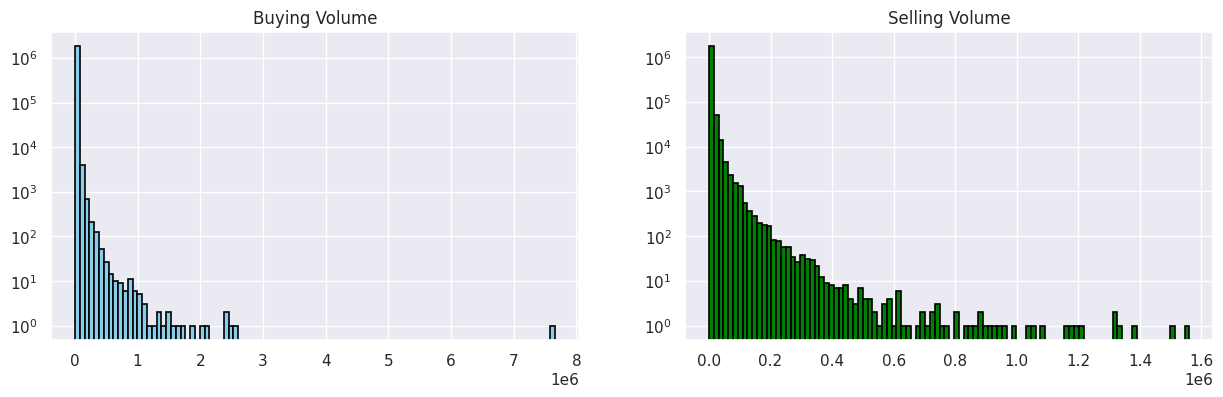

In [94]:
# Figure 4
buying_volume = rvn_usdt['qty'] * (~rvn_usdt['is_buyer_maker']) # An array that contains the buying volume
selling_volume = rvn_usdt['qty'] * rvn_usdt['is_buyer_maker'] # An array that contains the selling volume

print("The buying volume is: ", buying_volume.sum()) # Calculate the buying volume
print("The selling volume is: ", selling_volume.sum()) # Calculate the selling volume

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
ax1.hist(buying_volume, log = True, bins=100, color='skyblue', edgecolor='black', linewidth=1.2)
ax1.set_title("Buying Volume")
ax2.hist(selling_volume, log = True, bins=100, color='green', edgecolor='black', linewidth=1.2)
ax2.set_title("Selling Volume")
plt.show()

**Exercise 1**

In the histogram above, we have used the argument `log = True` in order to transform the $y$ axis in log scale. To see why, plot the histograms of the buying and selling volume with `log = False`. Furthermore, let's distinguish between transforming the $y$ axis for visualization purposes and transforming the data itself, using the natural logarithm. Create the two histograms again with `log = False`, but use the `np.log` function to transform the buying and selling volume: `np.log(buying_volume[buying_volume > 1])`. Do the same for the histograms presented in Figure 3. Explain the differences.

**Exercise 2**

Calculate the tick size for datasets (1) and (2). Explain your methodology in the forum.

We will now plot the buying and selling volume in a visually pleasing way. When plotting high resolution data, it makes no sense to zoom out in order to see the "big picture." On the contrary, we opt for zoomed-in graphs or interactive plots (plotly, bokeh) where we can zoom in on demand.

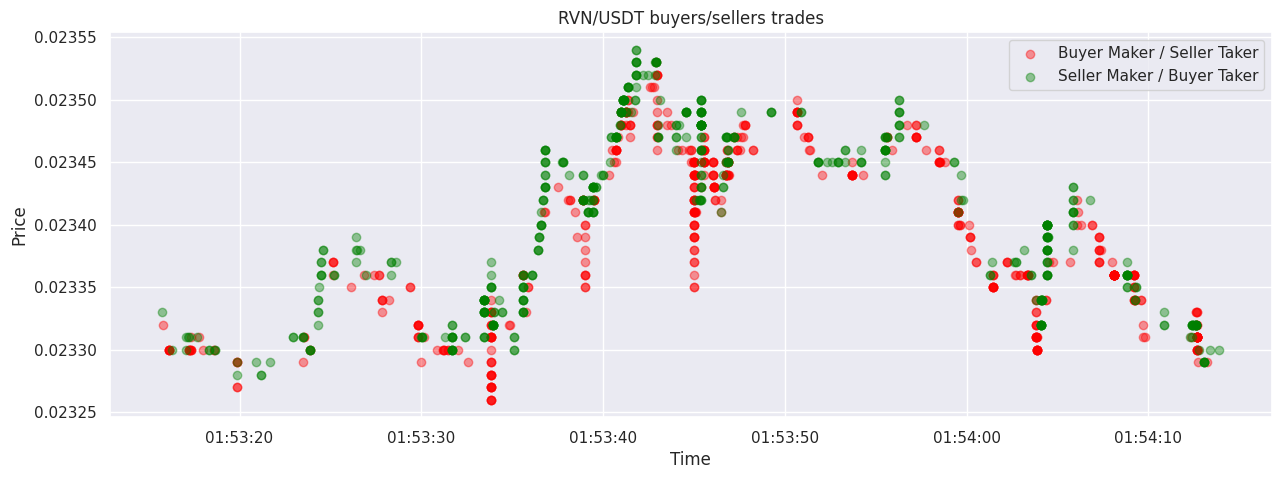

In [95]:
# Figure 5
rvn_usdt_slice = rvn_usdt.loc['2023-07-01 01:53:15.745':'2023-07-01 01:54:15.745'] # Slice the data

fig, ax = plt.subplots(figsize=(15, 5))

ax.scatter(x = rvn_usdt_slice[rvn_usdt_slice['is_buyer_maker'] == True].index, \
           y = rvn_usdt_slice[rvn_usdt_slice['is_buyer_maker'] == True]['price'], color='red', \
            label='Buyer Maker / Seller Taker', alpha = 0.4) # Plot the buyer maker / seller taker
ax.scatter(x = rvn_usdt_slice[rvn_usdt_slice['is_buyer_maker'] == False].index, \
           y = rvn_usdt_slice[rvn_usdt_slice['is_buyer_maker'] == False]['price'], color='green', \
            label='Seller Maker / Buyer Taker', alpha = 0.4) # Plot the seller maker / buyer taker
ax.set_title("RVN/USDT buyers/sellers trades")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.legend()
plt.show()

**Exercise 3**

In Figure 5, we can see a zoomed-in graph of the RVN/USDT buyers' and sellers' trades. The interval chosen is exactly 1 minute. In this exercise, you must recreate Figure 5 for different intervals. You can choose larger intervals and/or different points in time. In order to have a guide in choosing the intervals that **interest** you, you will have to plot the entire price plot of the RVN/USDT pair.

**Exercise 4** *(Optional)*

Using the code provided in this notebook as a guide, download the tick data locally in order to continue your workflow on your own PC. Then, try to use plotly or bokeh (holoviews) in order to create the interactive plots that will let you zoom in without slicing the dataset every time you want to create a new graph. Check [here](https://plotly.com/python/) for the gallery provided by plotly, and make sure you understand the difference between an interactive plot and a static one.

## **6. Level 1 Data (L1)**

Level 1 data (or else top-of-book data (TOB)) typically include the following columns:

* Symbol: the unique identifier of the financial instrument.

* Timestamp: the exact time when the event was recorded.

* Bid price: the highest price a buyer is willing to pay.

* Ask price: the lowest price a seller is willing to accept.

* Ask volume: number of units available at the ask price.

* Bid Volume: number of units available at the bid price.

In [96]:
# Load the data, dataset (3) - AGLJ_J
columns = ['RIC', 'DateTimeL', 'Type', 'Price', 'Volume', 'L1 Bid', 'L1 Ask', 'Trade Sign']
aglj = pd.read_csv('AGLJ_J_04-Jan-2016_TO_10-May-2016_5days.csv', \
                   names = columns, skiprows = 1) # Load the data
aglj.sort_values(by = 'DateTimeL', inplace = True)
aglj.head(5)

,RIC,DateTimeL,Type,Price,Volume,L1 Bid,L1 Ask,Trade Sign
1,AGLJ.J,"736,333.382013",Quote,0.000000,0.000000,0.000000,"6,800.000000",0
0,AGLJ.J,"736,333.382013",Trade,"6,750.000000",366.000000,0.000000,0.000000,0
4,AGLJ.J,"736,333.382015",Quote,0.000000,0.000000,"6,735.000000","6,800.000000",0
3,AGLJ.J,"736,333.382015",Quote,0.000000,0.000000,0.000000,"6,800.000000",0
2,AGLJ.J,"736,333.382015",Trade,"6,750.000000",374.000000,0.000000,0.000000,0


The first thing to notice is the `DateTimeL` column. This is another format you may encounter when using tick data, and it represents a *serial date* number expressing dates and times. Specifically, it counts the number of days from a given date, which is called `base_date`. In our case, the `base_date` is January 1, 0000. For example, the 736333.382013 translates to the 736333rd day since January 1, 0000. The decimal part, represents the fraction of the day. In our example the 736333rd day is January 4, 2016, and the fraction 0.382013 corresponds to 09:10:05.

With the help of the `datetime` Python library, we will transform the serial date to a human-readable one. But this is not without problems! The `datetime` library calendar begins from Jan 1, 0001, as historically, there is no year 0000. On the other hand, indexing from 0 is preferred for scientific calculations. Students need not go deep into this matter, but this is a good example of the different notations that one faces when dealing with tick data.

In [97]:
from datetime import datetime, timedelta

def convert_serial_to_datetime(serial):
    # Define the base date as January 1, 0001
    base_date = datetime(1, 1, 1)

    # Split the serial date into days and fractional days
    days = int(serial)
    fractional_day = serial - days

    # Adjust for the lack of year 0 by subtracting 367 days
    adjusted_days = days - 367

    # Calculate the target date by adding the adjusted days and fractional day (converted to seconds) to the base date
    target_date = base_date + timedelta(days=adjusted_days) + timedelta(seconds=fractional_day * 86400)

    # Return the target date in human-readable format
    return target_date.strftime('%Y-%m-%d %H:%M:%S')

aglj['timestamp'] = aglj['DateTimeL'].apply(convert_serial_to_datetime) # Convert the serial date to human readable datetime
aglj['timestamp'] = pd.to_datetime(aglj['timestamp']) # Convert the timestamp to datetime object
aglj.set_index('timestamp', inplace=True) # Set the timestamp as the index
aglj.head(5)

,RIC,DateTimeL,Type,Price,Volume,L1 Bid,L1 Ask,Trade Sign
timestamp,,,,,,,,
2016-01-04 09:10:05,AGLJ.J,"736,333.382013",Quote,0.000000,0.000000,0.000000,"6,800.000000",0
2016-01-04 09:10:05,AGLJ.J,"736,333.382013",Trade,"6,750.000000",366.000000,0.000000,0.000000,0
2016-01-04 09:10:06,AGLJ.J,"736,333.382015",Quote,0.000000,0.000000,"6,735.000000","6,800.000000",0
2016-01-04 09:10:06,AGLJ.J,"736,333.382015",Quote,0.000000,0.000000,0.000000,"6,800.000000",0
2016-01-04 09:10:06,AGLJ.J,"736,333.382015",Trade,"6,750.000000",374.000000,0.000000,0.000000,0


Let's now apply some cleaning filters:

Before we can effectively analyze high-frequency financial data, it's crucial to clean and preprocess the dataset. This cleaning process helps to remove erroneous entries and adjust for certain market microstructure effects, ensuring that our subsequent analyses are based on accurate and meaningful data.

First, we remove entries with zero or negative prices, quotes, or volumes. These are likely data errors, as prices and volumes in financial markets should always be positive. Negative spreads (where the bid price exceeds the ask price) are also eliminated as they represent impossible market conditions under normal circumstances.

Next, we address the issue of split transactions. In high-frequency trading, a single large order may be executed as multiple smaller trades at the same timestamp. This can lead to an overrepresentation of certain price levels and potentially skew our analysis. To mitigate this, we aggregate trades occurring at the same timestamp, summing their volumes and calculating a volume-weighted average price (VWAP). This approach preserves overall trading information while avoiding the artificial inflation of trade counts.
Similarly, we deal with intra-second quotes by keeping only the last quote for each timestamp. This is because, in a fast-moving market, the most recent quote is typically the most relevant for analysis.

In [98]:
# Delete entries with a quote or transaction price equal to zero of being negative
prices = aglj[aglj['Type'] == ' Trade']['Price'] # Get the transaction prices
quotes = aglj[aglj['Type'] == ' Quote'][['L1 Bid', 'L1 Ask']] # Get the quotes
print("Number of entries with a transaction price equal to zero or negative: ", (prices <= 0).sum()) # Check for zero or negative prices
print("Number of entries with negative or zero volume: ", (aglj[aglj['Type'] == ' Trade']['Volume'] <= 0).sum()) # Check for zero or negative volume
print("Number of entries with a quote equal to zero or negative: ", (quotes <= 0).sum().sum()) # Check for zero or negative quotes

index_to_drop_quotes = quotes[quotes['L1 Ask'] <= 0].index.union(quotes[quotes['L1 Bid'] <= 0].index) # Get the indices to drop
aglj.drop(index=index_to_drop_quotes, inplace=True) # Drop the entries with zero or negative quotes

# Delete entries with a negative spread
spreads = aglj[aglj['Type'] == ' Quote']['L1 Ask'] - aglj[aglj['Type'] == ' Quote']['L1 Bid'] # Calculate the spreads and using the new aglj cleaned by negative quotes dataset
index_to_drop_spreads = spreads[spreads < 0].index # Get the indices to drop
print("Number of entries with a negative spread: ", len(index_to_drop_spreads)) # Check for negative spreads
aglj.drop(index=index_to_drop_spreads, inplace=True) # Drop the entries with negative spreads

# Dealing with split transactions
dataset_on_trades = aglj[aglj['Type'] == ' Trade'] # Get the trades
unique_trades = pd.DataFrame()
unique_trades['DateTimeL'] = dataset_on_trades['DateTimeL'].groupby(dataset_on_trades['DateTimeL']).first() # Group the type by the first timestamp
unique_trades['Volume'] = dataset_on_trades['Volume'].groupby(dataset_on_trades['DateTimeL']).sum() # Aggregate the volume by the timestamp
unique_trades['Price'] = (dataset_on_trades['Price'] * dataset_on_trades['Volume']).groupby(dataset_on_trades['DateTimeL']).sum() / unique_trades['Volume'] # Final price as VWAP of the split transaction
unique_trades.drop(columns='DateTimeL', inplace=True) # Drop the DateTimeL column

# Dealing with intra-second quotes
dataset_on_quotes = aglj[aglj['Type'] == ' Quote'] # Get the quotes
unique_quotes = pd.DataFrame()
unique_quotes['DateTimeL'] = dataset_on_quotes['DateTimeL'].groupby(dataset_on_quotes['DateTimeL']).last() # Group the type by the last timestamp
unique_quotes['L1 Bid'] = dataset_on_quotes['L1 Bid'].groupby(dataset_on_quotes['DateTimeL']).last() # Aggregate the bid by the timestamp
unique_quotes['L1 Ask'] = dataset_on_quotes['L1 Ask'].groupby(dataset_on_quotes['DateTimeL']).last() # Aggregate the ask by the timestamp
unique_quotes.drop(columns='DateTimeL', inplace=True) # Drop the DateTimeL column

aggr_dataset_2 = pd.merge(unique_trades, unique_quotes, on='DateTimeL', how='outer') # Merge the trades and quotes

aggr_dataset_2['Type'] = np.where(aggr_dataset_2['Price'].isnull(), ' Quote', ' Trade') # Create the new column type

aggr_dataset_2['Trade Sign'] = aglj[aglj['DateTimeL'].isin(aggr_dataset_2[aggr_dataset_2['Type'] == ' Trade'].\
                                index) & (aglj['Type'] == ' Trade')].groupby('DateTimeL')['Trade Sign'].last() # Get the trade sign for the trades

aggr_dataset_2.reset_index(inplace=True) # Reset the index
aggr_dataset_2.index = pd.to_datetime(aggr_dataset_2['DateTimeL'].apply(convert_serial_to_datetime)) # Convert the serial date to human readable datetime

aggr_dataset_2.head(5)

Number of entries with a transaction price equal to zero or negative:  0
Number of entries with negative or zero volume:  0
Number of entries with a quote equal to zero or negative:  17
Number of entries with a negative spread:  42


,DateTimeL,Volume,Price,L1 Bid,L1 Ask,Type,Trade Sign
DateTimeL,,,,,,,
2016-01-04 09:10:20,"736,333.382180",NaN,NaN,"6,751.000000","6,800.000000",Quote,NaN
2016-01-04 09:10:20,"736,333.382182",NaN,NaN,"6,751.000000","6,800.000000",Quote,NaN
2016-01-04 09:10:21,"736,333.382190",NaN,NaN,"6,755.000000","6,800.000000",Quote,NaN
2016-01-04 09:10:21,"736,333.382192",NaN,NaN,"6,757.000000","6,800.000000",Quote,NaN
2016-01-04 09:10:42,"736,333.382433",NaN,NaN,"6,759.000000","6,800.000000",Quote,NaN


In [99]:
# A significant decrease in the number of rows
print(f"The filtered dataset `aggr_dataset_2` has {len(aggr_dataset_2)} entries, while the `aglj` dataset had {len(aglj)}.")

The filtered dataset `aggr_dataset_2` has 134724 entries, while the `aglj` dataset had 185210.


## **7. Order Flow Imbalance (OFI)**

Order Flow Imbalance (OFI) is an important concept in high-frequency data analysis that provide insights into the buying and selling pressures in the market. It measures the net order flow by taking into account the direction and size of trades. We will calculate the simplest form of OFI by multiplying the `Trade Sign` column (a positive sign for buyer-initiated trades and a negative sign for seller-initiated trades) with the respective trade volumes. Over time, the cumulative sum of these signed volumes gives us the OFI. A positive OFI indicates net buying pressure, while a negative OFI suggests net selling pressure. By analyzing OFI, we can gain valuable insights into short-term price movements, liquidity dynamics, and potential future price trends (as theory suggests).

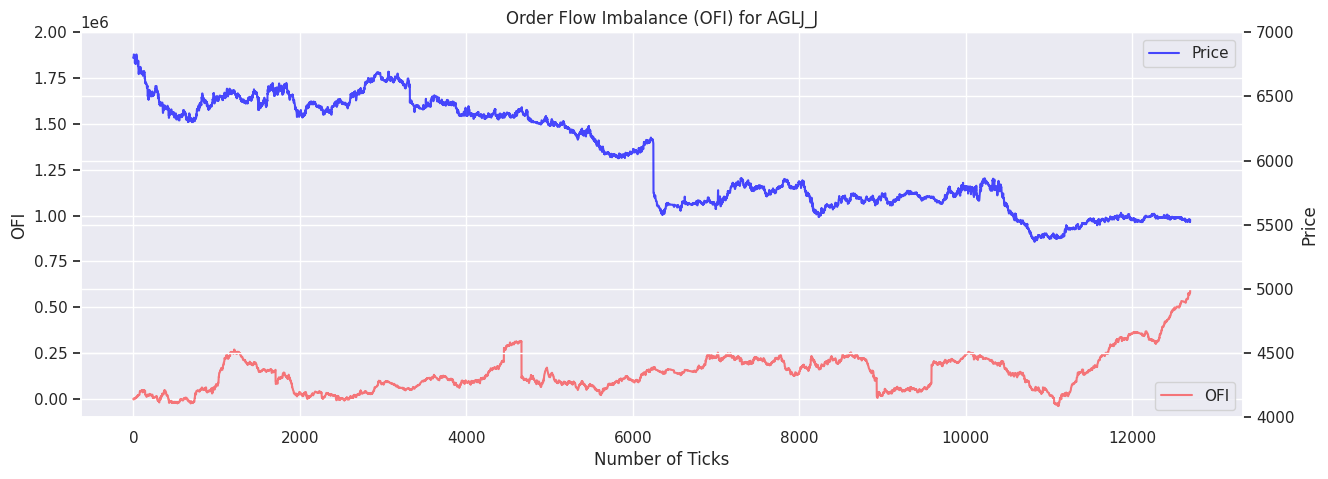



The Pearson correlation between the price and OFI is:  -0.45107451530143966


In [100]:
# Figure 6
signed_volume = aggr_dataset_2[aggr_dataset_2['Type'] == ' Trade']['Volume'] * aggr_dataset_2[aggr_dataset_2['Type'] == ' Trade']['Trade Sign'] # Calculate the OFI
ofi = signed_volume.cumsum() # Calculate the cumulative sum of the OFI
prices = aggr_dataset_2[aggr_dataset_2['Type'] == ' Trade']['Price'] # Get the prices

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(np.arange(len(ofi)), ofi, label = 'OFI', color = 'red', alpha = 0.5) # Plot the OFI
ax.set_ylabel('OFI')
ax.set_xlabel('Number of Ticks')
ax.set_title('Order Flow Imbalance (OFI) for AGLJ_J')
ax.set_ylim(-100000, 2000000)
ax.legend(loc = 'lower right')

ax2 = ax.twinx()
ax2.plot(np.arange(len(prices)), prices, color='blue', label='Price', alpha=0.7)
ax2.set_ylabel('Price')
ax2.legend()
ax2.set_ylim(4000, 7000)
plt.show()

print("\n\nThe Pearson correlation between the price and OFI is: ", np.corrcoef(prices, ofi)[0, 1]) # Calculate the Pearson correlation between the price and OFI

**Exercise 5**

Import the library `scipy` and compute the Spearman and Kendall correlation between the price and OFI. What do you see? Was that result what you expected?

---
The above result is somewhat counterintuitive and very common in practice. It highlights the importance of empirical analysis with real-world data rather than relying on only theoretical expectations.

As we can see, the price of AGLJ during these five days has a downward slope. On several occasions, the price has a short-term upward slope, but the trend in general is clear. Given the price, our expectation (based on theory and intuition) would be a downward slope for the OFI as well. But this is hardly the case since the OFI seems almost completely inconsistent with the price. The buying volume (as defined in this notebook) is rising which means that there are more buyers (takers) than sellers whereas, at the same time, the price is falling.

There could be several reasons for this phenomenon that could be very different if the data were retrieved from another exchange or for some other time interval:

* Market maker/Trader behavior: Market makers or large traders might be providing liquidity as prices fall, absorbing sell orders. This would show up as positive OFI (as they're buying) even as prices continue to decline.

* Large trades: A few large selling orders could outweigh the importance of many small buying orders.

* Market Microstructure Effects: In some market structures, large sell orders can trigger a series of smaller buy orders as they're filled, which could lead to this pattern.

* Time Frame Consideration: The relationship between OFI and price might be different over different time scales. What we're seeing could be a short-term effect that might reverse over longer periods.

**Exercise 6**

We deliberately gave a definition for buying and selling volume: Buying/Selling volume is the volume of the trades that were initiated by buyers/sellers (as takers). But now we must think of the buying and selling volume from the perspective of the trader's intention, which is the actual buying and selling volumes.

Hint: If a trader wants to buy, they can place a market order or a limit order.

Initiate a discussion in the forum with your ideas.


**Exercise 7**

We observed a counterintuitive result concerning the OFI of dataset (3): falling price with rising OFI. Now calculate the OFI for dataset (2) and plot it along with the price on the same graph (dual $y$-axis). What do you see?

Let's now provide ideas for plotting the best bid and ask along with the price of AGLJ: we will use the step function for the quote levels and the scatter for the price.

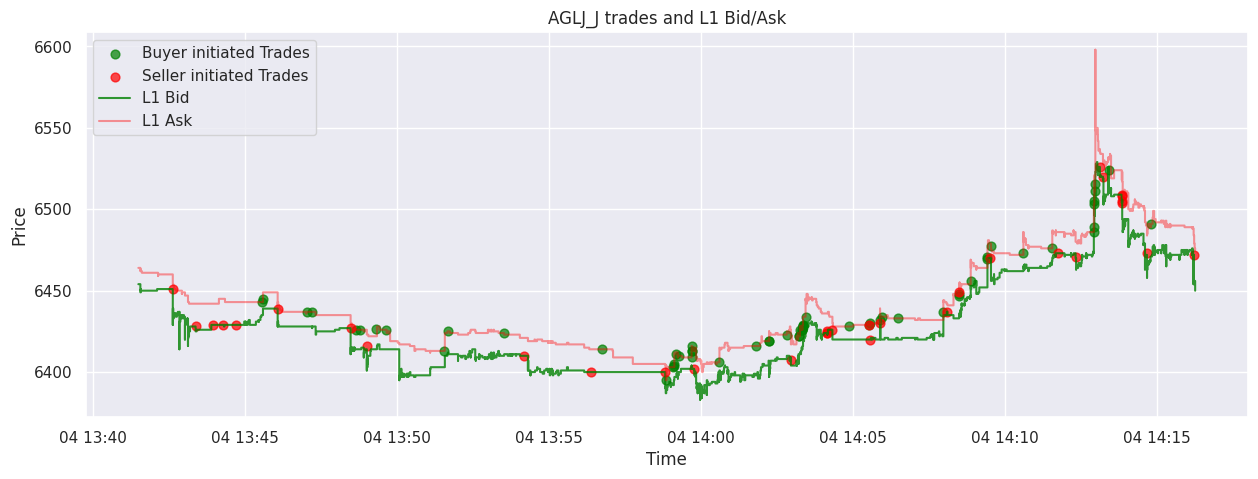

In [101]:
# Figure 7

zoomed_in_quotes_price = aggr_dataset_2.loc['2016-01-04'].iloc[15000:17000, :] # Slice the data

fig, ax = plt.subplots(figsize=(15, 5))

ax.scatter(x = zoomed_in_quotes_price[(zoomed_in_quotes_price['Type'] == ' Trade') & (zoomed_in_quotes_price['Trade Sign'] == 1)].index, \
              y = zoomed_in_quotes_price[(zoomed_in_quotes_price['Type'] == ' Trade') & (zoomed_in_quotes_price['Trade Sign'] == 1)]['Price'], color='green', \
                label='Buyer initiated Trades', alpha = 0.7, s = 40) # Plot the trades
ax.scatter(x = zoomed_in_quotes_price[(zoomed_in_quotes_price['Type'] == ' Trade') & (zoomed_in_quotes_price['Trade Sign'] == -1)].index, \
              y = zoomed_in_quotes_price[(zoomed_in_quotes_price['Type'] == ' Trade') & (zoomed_in_quotes_price['Trade Sign'] == -1)]['Price'], color='red', \
                label='Seller initiated Trades', alpha = 0.7, s = 40) # Plot the trades
ax.step(zoomed_in_quotes_price[zoomed_in_quotes_price['Type'] == ' Quote'].index, \
                zoomed_in_quotes_price[zoomed_in_quotes_price['Type'] == ' Quote']['L1 Bid'], color='green', \
                    label='L1 Bid', alpha = 0.8, where = 'post') # Plot the L1 Bid
ax.step(zoomed_in_quotes_price[zoomed_in_quotes_price['Type'] == ' Quote'].index, \
                zoomed_in_quotes_price[zoomed_in_quotes_price['Type'] == ' Quote']['L1 Ask'], color='red', \
                    label='L1 Ask', alpha = 0.4, where = 'post') # Plot the L1 Ask

ax.set_title("AGLJ_J trades and L1 Bid/Ask")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.legend()
plt.show()

**Exercise 8**

In Figure 7, you can see the plot of the best quotes plotted along the price. Do the following:
* Be certain you can explain the argument `where = 'post'` inside the step plot function.
* By checking the `matplotlib` documentation, enhance the above graph by adjusting the size of the scatter marker using the size of the trade. So, if trade A is larger than trade B, then marker A should be larger than marker B. You can choose a different date and slice of the dataset. Paste your results in the forum.

## **8. Resampling**

In the last section, we will be creating the time bars everyone is comfortable with. For this reason, we will use the `resample` method that works very well with a datetime index. We will create datasets for several timeframes and will showcase how some statistics change as the timeframe becomes larger. The dataset of our choice will be dataset (2): rvn_usdt.

In [102]:
rvn_usdt.resample('1min', label = 'right').agg({'price': 'ohlc', 'qty': 'sum'}).head()

price                                       qty
                        open     high      low    close            qty
timestamp                                                             
2023-04-01 00:01:00 0.025880 0.025940 0.025880 0.025940 270,588.000000
2023-04-01 00:02:00 0.025940 0.025960 0.025940 0.025960 354,425.300000
2023-04-01 00:03:00 0.025970 0.026000 0.025960 0.025990 423,137.400000
2023-04-01 00:04:00 0.025980 0.025980 0.025920 0.025930  96,082.300000
2023-04-01 00:05:00 0.025940 0.025940 0.025940 0.025940  42,425.700000

**Exercise 9**

Explain the argument `label = right`. Discuss your ideas in the forum. Also, find a suitable library to plot the 'candles' along with the volume.

In [103]:
#Create the resample function
def resample(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    """
    Resample the data to a given frequency.
    """
    resampled_df = df.resample(freq, label = 'right').agg({'price': 'ohlc', 'qty': 'sum'}) # Resample the data
    resampled_df.columns = resampled_df.columns.droplevel(0) # Drop the first level of the columns. Create a simple column index instead of an Multiindex.
    return resampled_df

timeframes = ['1min', '2min', '5min', '10min', '15min', '30min', '1h', '2h', '4h', '8h', '12h', '1D', '2D', '5D'] # Define the timeframes

statistics = {} # Create a dictionary to store the statistics
for timeframe in timeframes:
    temp = resample(rvn_usdt, timeframe)['close'] # Resample the data
    temp_returns =  np.log(temp / temp.shift(1)).dropna() # Calculate the log returns
    statistics[timeframe] = {'mean': temp_returns.mean(), 'std': temp_returns.std(), 'skewness': temp_returns.skew(), 'kurt': temp_returns.kurt()} # Calculate the statistics

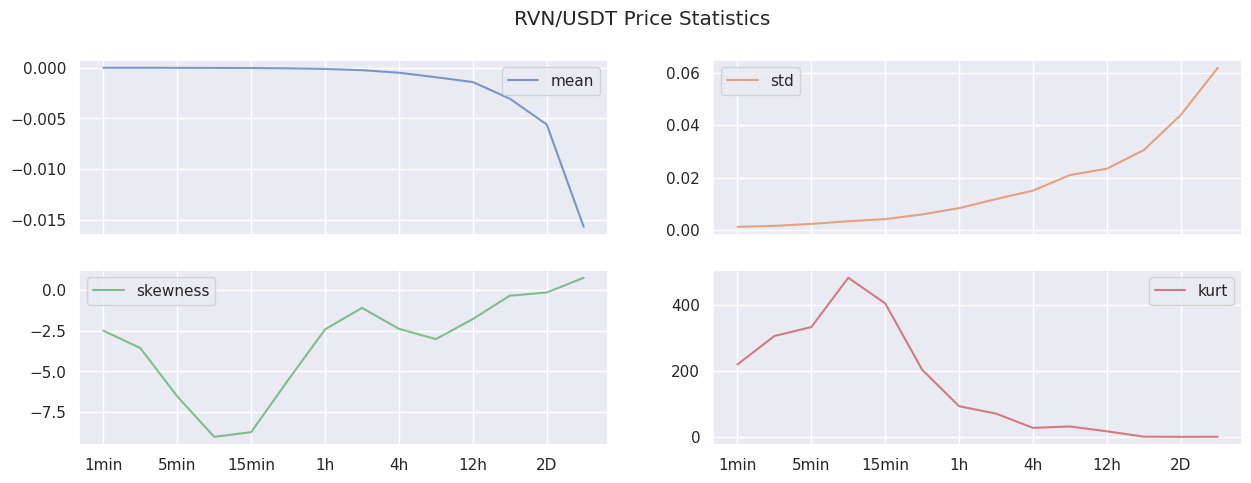

In [104]:
#Figure 8
pd.DataFrame(statistics).T.plot(subplots = True, figsize = (15, 5), layout = (2, 2), title = 'RVN/USDT Price Statistics', alpha = 0.7) # Plot the statistics
plt.show()

The above results are somehow expected and show us the properties that we lose or gain by aggregating the high-frequency data.

* The mean return is close to 0 for small timeframes. Since each trade corresponds to small price increments, it is natural that the price changes in small timeframes were not able to accumulate and show a mean different than zero.
    
    1) Microstructure Noise: At very high frequencies, returns are heavily influenced by market microstructure effects such as bid-ask bounce, which can mask any true price trend over short intervals.
    
    2) Martingale Property: In a fair market, price processes are often modeled as martingales, where the expected future price given all past information is the current price. This implies that expected short-term returns should be zero.

* Standard Deviation: The increase in standard deviation with larger timeframes is consistent with the properties of Brownian motion (more in the Derivative Pricing course), which are used to model price processes. Under the assumptions of Brownian Motion, variance scales linearly with time, so standard deviation scales with the square root of time.

* The slight upward slope in skewness as the timeframe gets larger could indicate that the positive price movements tend to be larger than the negative ones over longer periods.

* More importantly, the high kurtosis at small timeframes reflects the leptokurtic nature of high-frequency returns. More specifically:
    
    1) Fat Tails: The extreme events are common in leptokurtic distribution, more common in relation to the normal distribution.
    
    2) As we aggregate to the larger timeframes, the central limit theorem takes effect and the return distribution approaches normality. However, in larger timeframes, the returns still do not reach normality.

**Exercise 10**

Create time bars for the rvn_usdt pair as above but now include two more columns:
* A column named `buying_volume` that will consist of the aggregated volume of the trades attributed to the `is_buyer_maker = False`
* A column named `selling_volume` that will consist of the aggregated volume of the trades attributed to the `is_buyer_maker = True`

**Exercise 11**

In explaining the statistics of Figure 8, we used the central limit theorem to argue for the convergence of the returns distribution with the normal distribution. But we did not actually aggregate the returns. Rather, we used the `close` column of each timeframe to calculate the kurtosis. Is that argument used correctly or not? Why? Do the same as above but instead of the `close` price of each timeframe, calculate the `sum()` of the log returns. Does this change anything?

## **9. Conclusion**

This lesson has provided an introduction to tick data, its characteristics, and its importance in financial markets. We've explored the structure of tick-by-tick trade data and Level 1 data, demonstrating how to handle, clean, and plot these high-frequency datasets.

Key takeaways include:

1. The granularity of tick data provides insights into market microstructure that are not visible in lower-frequency data.

2. Cleaning is an essential preprocess step that should include the handling of split transactions and intra-second quotes (among others).

3. Order flow imbalance (OFI) can provide valuable insights into short-term market dynamics, but its interpretation requires careful consideration of market context and can be misleading.

4. Resampling tick data to various timeframes reveals how statistical properties of returns change with time aggregation, highlighting the trade-offs between granularity and noise.

5. Working with tick data presents unique challenges, including data volume, cleaning requirements, and the need for specialized analytical techniques.

**References**

* Gebbie, Tim, and Edward Nonyane. “TRTH JSE AGLJ.J Intraday Transaction Test Data.” Mendeley Data, V2, 2019.

* Harris, Larry. *Trading and Exchanges: Market Microstructure for Practitioners*. Oxford University Press, 2003.

* Hautsch, Nikolaus. *Econometrics of Financial High-Frequency Data*. Springer Science & Business Media, 2011.

MODULE 3 | LESSON 4


---

# **Singular Value Decomposition of Matrices**
|  |  |
|:---|:---|
|**Reading Time** 60 minutes |   |
|**Prior Knowledge** Basic Matrix Operation, Linear Algebra, Basic Python |   |
|**Keywords** Singular Value Decomposition (SVD), Full and economy SVD, matrix approximation  |

---

*In the previous lesson, we introduced methods to decompose a symmetric matrix. However, manytimes, the dataset or a matrix we have is not a symmetric matrix. In this lesson, we will introduce a general method to decompose a matrix. This method is called Singular Value Decomposition or SVD. We will go through the definition and properties of SVD and then present an application.*

## **1. Introducing Singular Value Decomposition (SVD)**
**Singular value decomposition (SVD)** is a very popular method in numerical linear algebra. It is commonly used to solve for a linear regression problem when the matrix is not squared. It can also be used as a data dimension reduction method. One of the examples is to use SVD as the basis for principal component analysis. SVD is also a foundational numeric method for machine learning algorithms.
<br>
In the last module, we discussed how to diagonalize a symmetric matrix. If $A$ is a 3 by 3 symmetric matrix, we can diagonalize or factor $A$ as follows:
<br>
<br>
$$A=\begin{bmatrix}
| & | &  |\\
v_{1} & v_{2} & v_{3} \\
| & | & |
\end{bmatrix}\begin{bmatrix}
\lambda_{1} & 0 & 0 \\
0 & \lambda_{2} & 0 \\
0 & 0 & \lambda_{3}
\end{bmatrix}\begin{bmatrix}
| & | &  |\\
v_{1} & v_{2} & v_{3} \\
| & | & |
\end{bmatrix}^{T}$$
<br>
where
<br>
$v_{1} , v_{2} , v_{3}$ are eigenvectors of $A$
<br>
$\lambda_{1} , \lambda_{2} , \lambda_{3}$ are eigenvalues of $A$
<br>
<br>
However, most of the time, the datasets or a matrix we have will not have symmetry. Hence, we need a method to diagonalize a general matrix. This method is singular value decomposition.
<br>
<br>
## **2. Definition of Singular Value Decomposition**
### **2.1. Matrix Representation of SVD**
**Singular value decomposition** is a method to decompose a matrix into three matrices. For any $m\times n$ matrix $A$ with real entries, there exists a factorization of the form:
<br>
<br>
$$A=U\Sigma V^{T}$$
<br>
Where:
<br>
$U$ is an $m\times m$ unitary and orthogonal, hence orthonormal matrix
<br>
$\Sigma$ is an $m\times n$ rectangular diagonal matrix with non-zero real numbers on the diagonal
<br>
$V^{T}$ is the transpose of $V$; $V$ is an $n\times n$ unitary and orthogonal (orthonormal) matrix
<br>
<br>
We can also rewrite the above formula in the following matrix form assuming $m\ge n$.
<br>
<br>
$$\begin{bmatrix}
 &  &  &  \\
| & | &  & |\\
a_{1} & a_{2} & ... & a_{n} \\
| & | &  & |\\
 &  &  &
\end{bmatrix}=\begin{bmatrix}
 &  &  &  \\
| & | &  & |\\
u_{1} & u_{2} & ... & u_{m} \\
| & | &  & |\\
 &  &  &
\end{bmatrix}\begin{bmatrix}
\sigma_{1} & 0 & ... & 0 \\
0 & \sigma_{2} & ... & 0 \\
0 & 0 & ... & 0 \\
0 & 0 & ... & \sigma_{n} \\
0 & 0 & ... & 0
\end{bmatrix}\begin{bmatrix}
 &  &  &  \\
| & | & | & | \\
v_{1} & v_{2} & ... & v_{n} \\
| & | & | & | \\
 &  &  &
\end{bmatrix}^{T}$$
<br>
where $a$ are $n$ column vectors in matrix $A$, $u$ are $m$ column vectors in matrix $U$, and $v$ are $n$ column vectors in matrix $V$.
<br>
The above matrix dimensions are as follows:
$$\left[ m\times n \right]=\left[ m\times m \right]\left[ m\times n \right]\left[ n\times n \right]$$
<br>
<br>
The diagonal entries $\sigma_{i}$ of $\Sigma$ are known as the **singular values** of $A$. They are typically arranged in descending order ($\sigma_{1}$ ≥ $\sigma_{2}$ ≥ ... ≥ $\sigma_{min(m,n)}$ ≥ 0). Since the above $\Sigma$ matrix assumes $m \ge n$, there can be at most n positive singular values. The values of the rest of the rows in $\Sigma$ are 0.
<br>
The vectors in matrix $U$ are called the **left singular vectors** of $A$.
<br>
The vectors in matrix $V$ are called the **right singular vectors** of $A$.
<br>
<br>
### **2.2. Geometric Interpretation of Singular Value Decomposition (SVD)**
SVD can be interpreted geometrically as a composition of three transformations:
1. A rotation or reflection $U$
2. A scaling or dilating along coordinate axes $\Sigma$
3. Another rotation or reflection $V^{T}$

This interpretation helps in understanding how SVD captures the essential structure of linear transformations. The following graph illustrates the decomposition.
<br>
<br>
**Figure 1: Visualization for Singular Value Decomposition**

![Diagram illustrating the Singular Value Decomposition (SVD) process, showing transformations: a linear transformation (A), rotations (U and V^T), and dilation (Σ), represented on a 2D plane with vectors.](images/FD_M3_L4_decomposition.jpg)
<br>
<br>
## **3. Properties of Singular Value Decomposition (SVD)**
In this section, we will discuss some of the key properties for SVD.
<br>
<br>
##### **Property 1.**
Since the vectors in $U$ and $V$ are unitary and orthogonal,
<br>
$U^{T}U=UU^{T}=I_{m\times m}$   (identity matrix)
<br>
$V^{T}V=VV^{T}=I_{n\times n}$   (identity matrix)
<br>
<br>
##### **Property 2.**
The number of non-zero singular values in matrix $\Sigma$ is the rank of the matrix $A$.
<br>
<br>
##### **Property 3.**
Since singular values $\sigma$s are arranged in descending order in the $\Sigma$ matrix, the first column of $U$(which is $u_{1}$) and the first column of $V$(which is $v_{1}$) corresponding to $\sigma_{1}$ are more important in describing information in matrix $A$ than the second columns of the $U$ and $V$ matrices. The first columns of $U$ and $V$ are also more important than the third columns in describing matrix $A$, and so on and so forth. Because of this property, when some $\sigma$'s values are very small, it means they contain only a very small amount of the information of matrix $A$. We can drop these $\sigma$s and their corresponding columns in the $U$ and $V$ matrices.
<br>
<br>
##### **Property 4.**
In the last section, we mentioned that the number of non-zero singular values in the $\Sigma$ matrix is the minimum of $m$ and $n$. Hence, there can be rows of all $0$s at the lower part of matrix $\Sigma$. As a result, when we conduct a dot product of matrix $U$ with matrix $\Sigma$, the corresponding vectors of $U$ will multiply with all the rows of $0$s in matrix $\Sigma$ and give $0$ result. With this result, we can simply SVD to a reduced form by dropping rows of all $0$ in matrix $\Sigma$ and the corresponding vectors in matrix $U$. The following Figure 2 demonstrates this property.
<br>
<br>
**Figure 2: Full SVD vs. Economy/Reduced SVD**

![Diagram comparing Full and Reduced Singular Value Decomposition (SVD), showing matrices A, U, Σ, and V^T with their respective components and dimensions.](images/FD_M3_L4_reduced_SVD.jpg)
<br>
<br>
In the first equation in Figure 2, we can see when we conduct a dot product for $U$ and $\Sigma$, $\hat{U}^{\bot }$ part of $U$ will multiply with $0$ of $\Sigma$. The result  will be $0$. Hence, we can drop them without losing information in matrix A. The second equation is the reduced form of SVD. It is called **reduced SVD** or **economy SVD**.
<br>
<br>
## **4. Matrix Approximation Using SVD**
In this section, we are going to demonstrate how to use SVD to approximate a matrix. This is the most popular reason to use SVD.
<br>
Assume for the $m \times n$ matrix A, the rank  is $r$, and $r\lt min(m,n)$. We can write matrix $A$'s SVD as follows.
<br>
<br>
$$A=\begin{bmatrix}
 &  &  &  \\
| & | &  & |\\
a_{1} & a_{2} & ... & a_{n} \\
| & | &  & |\\
 &  &  & \\
 &  &  &
\end{bmatrix}=\begin{bmatrix}
 &  &  &  \\
| & | &  & |\\
u_{1} & u_{2} & ... & u_{m} \\
| & | &  & |\\
 &  &  & \\
 &  &  &
\end{bmatrix}\begin{bmatrix}
\sigma_{1} & 0 & ... & 0 &0 \\
0 & \sigma_{2} & ... & 0 &0\\
0 & 0 & ... & 0 &0\\
0 & 0 & ... & \sigma_{r} &0\\
0 & 0 & ... & 0 &0\\
0 & 0 & ... & 0 &0
\end{bmatrix}\begin{bmatrix}
 &  &  &  \\
| & | & | & | \\
v_{1} & v_{2} & ... & v_{n} \\
| & | & | & | \\
 &  &  & \\
 &  &  &
\end{bmatrix}^{T}$$
<br>
<br>
From the singular values in $\Sigma$, we know $\sigma_{1}\ge \sigma_{2}\ge ...\ge \sigma_{r}\gt \sigma_{r+1}=...\\sigma_{min(m,n)}=0$. We can expand matrix A as follows.
<br>
<br>
$$A=\sum_{k=1}^{r}\sigma_{k}u_{k}v_{k}^{T}=\sigma_{1}u_{1}v_{1}^{T}+\sigma_{2}u_{2}v_{2}^{T}+...+\sigma_{r-1}u_{r-1}v_{r-1}^{T}+\\sigma_{r}u_{r}v_{r}^{T}$$
<br>
<br>
This is called the Eckart-Young theorem. According to the theorem, we can represent matrix $A$ by only using leading r vectors in matrix $U$ and leading r vectors in matrix $V$ because in the $\Sigma$ matrix, there are only $r$ non-zero $\sigma$s.
<br>
We also know that $\sigma$s in $\Sigma$ are in descending order. If the $\sigma$s on the right side of the equation are too small, we can drop them from the equation. Then, we can approximate matrix $A$ by using only $\sigma$s with large values. Say we only want to keep $\hat{r}$ leading $\sigma$s in the equation, where $r \ge \hat{r}$. The approximated matrix $A$ can be expressed as follows.
<br>
<br>
$$\tilde{A}=\sum_{k=1}^{\hat{r}}\sigma_{k}u_{k}v_{k}^{T}=\sigma_{1}u_{1}v_{1}^{T}+\sigma_{2}u_{2}v_{2}^{T}+...+\sigma_{\hat{r}-1}u_{\hat{r}-1}v_{\hat{r}-1}^{T}+\\sigma_{\hat{r}}u_{\hat{r}}v_{\hat{r}}^{T}$$
<br>
<br>
$\tilde{A}$ is the approximation of A. Based on the above equation and explanation, $\tilde{A}$ contains fewer data points than $A$ but keeps the majority of the information from the original matrix $A$. We reduce data dimension using SVD to approximate a matrix. This is due to the property of SVD that allows us to solve least-squared issues or run machine learning algorithms more efficiently.

## **5. Application of Singular Value Decomposition (SVD)**
In this section, we are going to use some financial data to demonstrate the usage of SVD. We will use the stock price data for Apple, Ford Motor, Pfizer, and Walmart to show how to apply SVD. First, let's download some Python libraries for this application.

In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yfin
import seaborn as sns
import math
from numpy import linalg as LA

### **5.1 Importing Data**

Next, we are going to download stock price data from Yahoo Finance.

In [2]:
# Download stock prices from Yahoo Finance and set the time period for download
start = datetime.date(2018, 1, 2)
end = datetime.date(2023, 12, 31)
stocks = yfin.download(["AAPL", "F", "WMT","PFE"], start, end, auto_adjust = False)["Adj Close"]
stocks.head()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,F,PFE,WMT
Date,,,,
2018-01-02,40.380997,8.358680,24.656250,28.973366
2018-01-03,40.373962,8.424706,24.838938,29.226095
2018-01-04,40.561501,8.569958,24.893066,29.252544
2018-01-05,41.023296,8.715211,24.940430,29.425924
2018-01-08,40.870918,8.682199,24.663010,29.860865


In [3]:
stocks.index = pd.to_datetime(stocks.index).strftime("%Y-%m-%d")

### **5.2 Calculating Returns**
Now, let's calculate the returns of these stock prices.

In [4]:
# In order to calculate the returns of the stocks, we need to drop the NA rows.
stocks_returns = stocks[["AAPL", "F", "WMT","PFE"]].dropna().pct_change()
stocks_returns = stocks_returns.dropna()
stocks_returns.head()

Ticker,AAPL,F,WMT,PFE
Date,,,,
2018-01-03,-0.000174,0.007899,0.008723,0.007409
2018-01-04,0.004645,0.017241,0.000905,0.002179
2018-01-05,0.011385,0.016949,0.005927,0.001903
2018-01-08,-0.003714,-0.003788,0.014781,-0.011123
2018-01-09,-0.000114,-0.005323,-0.012006,-0.001098


### **5.3 Computing the SVD**

We now have the stock price return dataset for four stocks. We can simply calculate SVD using the following Python function.

In [5]:
# Perform SVD for stock returns
U, s, VT = np.linalg.svd(stocks_returns)

In [6]:
# Present the result
print("Stock Returns Matrix Dimension:")
print(stocks_returns.shape)
print("\nDimension of Matrix U:")
print(U.shape)
print("\nSingular values:")
print(s)
print("\nDimension of Matrix V^T:")
print(VT.shape)

Stock Returns Matrix Dimension:
(1508, 4)

Dimension of Matrix U:
(1508, 1508)

Singular values:
[1.11696744 0.7248957  0.55820586 0.47159236]

Dimension of Matrix V^T:
(4, 4)


# **6. Comparing PCA and SVD**

So far, it has been very straightforward to calculate the SVD of a matrix using Python. Let's make things a little bit more interesting. We are going to show the connection between SVD and principal component analysis (PCA) (Brunton et al.).
<br>
In Module 1, we briefly discussed how to obtain principal components using eigenvectors and eigenvalues. In this section, we will show you how to use the SVD of a matrix to get eigenvalues and eigenvectors.
<br>
Remember in Module 2, before we get to principal components, we need to standardize the data. Let's do that first.

In [7]:
# Standardize stock returns dataset
stocks_returns_means = stocks_returns.mean()
stocks_returns_stds = stocks_returns.std()
standardized_returns = (stocks_returns - stocks_returns_means) / stocks_returns_stds
standardized_returns.head()

Ticker,AAPL,F,WMT,PFE
Date,,,,
2018-01-03,-0.070359,0.286277,0.584130,0.446785
2018-01-04,0.171150,0.647631,0.030003,0.124442
2018-01-05,0.508919,0.636332,0.385963,0.107400
2018-01-08,-0.247773,-0.165774,1.013523,-0.695405
2018-01-09,-0.067354,-0.225146,-0.885161,-0.077507


Next, we want to calculate the covariance of the standardized returns matrix. The matrix form of the covariance equation is as follows.
<br>
<br>
$$\left( \frac{standardized \;\;returns\;\;matrix}{\sqrt{n-1}} \right)^{T}\bullet \left( \frac{standardized  \;\;returns\;\;matrix}{\sqrt{n-1}} \right)$$
<br>
<br>

In [8]:
# Calculate covariance for standardized return matrix
standardized_returns_dvd_sqrt_n=(standardized_returns/math.sqrt(len(standardized_returns)-1))
standardized_returns_cov = standardized_returns_dvd_sqrt_n.T@standardized_returns_dvd_sqrt_n
standardized_returns_cov

Ticker,AAPL,F,WMT,PFE
Ticker,,,,
AAPL,1.000000,0.376460,0.365246,0.324438
F,0.376460,1.000000,0.185248,0.224384
WMT,0.365246,0.185248,1.000000,0.296376
PFE,0.324438,0.224384,0.296376,1.000000


Now, let's do some simple matrix manipulation of the covariance of standardized returns. Let's assume matrix $B$ is the $\left( \frac{standardized \;\;returns\;\;matrix}{\sqrt{n-1}} \right)$. Hence, we can rewrite the covariance of standardized returns as follows.
<br>
<br>
$$Covariance = B^{T}B$$
<br>
<br>
With SVD, we can write matrix $B$ as $B=U\Sigma V^{T}$. Then, its transpose is $B^{T}=V\Sigma U^{T}$. Then, we can calculate the covariance of the standardized returns as follows.
<br>
<br>
$$Covariance =B^{T}B=V\Sigma U^{T}U\Sigma V^{T}=V\Sigma\Sigma V^{T}=V\Sigma^{2} V^{T}$$
<br>
<br>
Because the property of $U^{T}U=I$ is an identity matrix, we can drop $U^{T}U$. Next, let's conduct the following calculation.
<br>
<br>
$$B^{T}BV=V\Sigma^{2} V^{T}V=V\Sigma^{2}$$
<br>
<br>
We can drop $V^{T}V$ because $V^{T}V=I$ is an identity matrix.
Does the equation above remind you of something? Yes, the equation shows that the column vectors in matrix $V$ are the eigenvectors of $B^{T}B$. The squared singular values in matrix $\Sigma$ are eigenvalues of $B^{T}B$. Hence, $Bv_{1}$is the first principal component and the corresponding $\sigma_{1}^{2}$ is the variance of the dataset $B$ explained by the first principal component.
<br>
Now, you actually have two ways to calculate principal components. The first method, as described in Module 1, Lesson 4, is by calculating the eigenvalues and eigenvectors of the covariance matrix of the data. The second method is to calculate the SVD of the data. Then, matrix $V$ will contain eigenvectors, and squared singular values will be eigenvalues.
<br>
Now let's try both methods to get eigenvalues and eigenvectors.

In [9]:
# Use SVD to calculate eigenvectors and eigenvalues of the covariance matrix of standardized returns
U_st_return, s_st_return, VT_st_return = np.linalg.svd(standardized_returns_dvd_sqrt_n)
print("\nSquared Singular values (eigenvalues):")
print(s_st_return**2)
print("\nMatrix V (eigenvectors)")
print(VT_st_return.T)


Squared Singular values (eigenvalues):
[1.8947491  0.83555392 0.71064878 0.5590482 ]

Matrix V (eigenvectors)
[[ 0.56634752  0.14011783 -0.21637635 -0.78281464]
 [ 0.45964747  0.7575927   0.01833963  0.46307793]
 [ 0.48586809 -0.53226576 -0.55857243  0.41063633]
 [ 0.48156712 -0.35087528  0.80052594  0.06432632]]


In [10]:
# Use the method from Module 1 Lesson 4 to calculate eigenvectors and eigenvalues of the covariance matrix of standardized returns
eigenvalues, eigenvectors = LA.eig(standardized_returns_cov)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
eigenvalues

array([1.8947491 , 0.83555392, 0.71064878, 0.5590482 ])

In [11]:
eigenvectors

array([[-0.56634752,  0.14011783, -0.21637635, -0.78281464],
       [-0.45964747,  0.7575927 ,  0.01833963,  0.46307793],
       [-0.48586809, -0.53226576, -0.55857243,  0.41063633],
       [-0.48156712, -0.35087528,  0.80052594,  0.06432632]])

We can see from the above result that both methods generate the same eigenvalues. Both methods also generate the same eigenvectors except the first one. Looking closely, we can see they only differ in regards to the negative sign. For eigenvectors, they are actually the same because the negative sign does not change the direction nor the scale of both eigenvectors.
<br>
You can use either method to obtain the eigenvectors and eigenvalues of a covariance matrix. There is no agreement on which one is better. We usually use SVD for implementing PCA, image compression, and recommendation systems. We would use the method in Module 1, Lesson 4 for solving least-square problems.
<br>
One key difference between PCA and SVD is how they handle starting points. In general, PCA works on the covariance or correlation matrix. PCA also standardizes the data matrix. However, SVD can simply work straight on the data matrix. If SVD does not standardize the data matrix, the resulting eigenvalues can differ from the eigenvalues calculated from PCA.
<br>
<br>
# **7. Conclusion**
In this lesson, we first introduced SVD. We gave its definition, demonstrated its geometric interpretation, and discussed its properties. We then showed its application in Python. We showed how to use SVD to calculate eigenvalues and eigenvectors of a covariance matrix. We also pointed out the connections between SVD and PCA.

**References**
- Brunton, Steven L., et al. "Chapter 1: Singular Value Decomposition (SVD) and Principal Components Analysis (PCA)." University of Washington, 2015, https://faculty.washington.edu/sbrunton/me565/pdf/CHAPTER1.pdf.

MODULE 4 | LESSON 1


---

# **Similarity Measures**

|  |  |
|:---|:---|
|**Reading Time** | 45 minutes  |
|**Prior Knowledge** |  Basic statistics: Familiarity with concepts like mean, standard deviation, correlation, and distributions. <br>Linear algebra: Basic knowledge of vectors, matrices, and operations like dot product. <br>Probability: A basic understanding of probability concepts to aid in interpreting statistical measures and their significance. <br>Financial and Investing Knowledge: Basic understanding of financial markets, instruments, and investment strategies; <br>Familiarity with risk assessment and management concepts; Basic knowledge of sentiment analysis and its role in understanding market trends. |
|**Keywords** | Euclidean Distance, Manhattan Distance, Cosine Similarity, Jaccard Index, Word Mover's Distance (WMD), Dynamic Time Warping, Pearson Correlation, <br>Spearman Rank Correlation, Term Frequency-Inverse Document Frequency (TF-IDF), Text Analysis, Natural Language Processing (NLP), Information Retrieval |

---

*In this lesson we explore similarity measures and their use in financial markets, especially Term Frequency-Inverse Document Frequency (TF-IDF) for analyzing text data like news and social media to gain insights for investment decisions. We will cover different types of similarity measures, benefits of TF-IDF, and its applications in sentiment analysis, risk management, and for other investment strategies.*

In [12]:
# Load libraries
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer

## **1 Similarity Measures**

Similarity measures are methods used to quantify how alike two data objects are. They are essential in various fields, including data mining, machine learning, and information retrieval. The choice of similarity measure depends on the type of data and the desired interpretation of similarity. Common types of Similarity Measures are:

**Distance Measures:** These measures quantify dissimilarity. Smaller distances indicate higher similarity:

 - Euclidean distance
 - Manhattan distance
 - Minkowski distance
 - Word Mover's Distance (WMD)
 - Dynamic Time Warping

**Similarity Coefficients:** These measures directly quantify similarity. Higher values indicate greater similarity:

 - Cosine similarity
 - Jaccard index
 - Pearson correlation coefficient
 - Spearman Rank Correlation


Below we will consider each in further details.

### **1.1 Distance Measures**

**1. Euclidean distance**

 - **Type:** Distance measure
 - **Data Type:** Numerical data
 - **Description:** Measures the straight-line distance between two points in Euclidean space.
 - **Formula:** $\sqrt{\sum (x_i - y_i)^2}$ (where $x$ and $y$ are the data points, and $i$ represents the dimensions)
 - **Interpretation:** Smaller distance = higher similarity
 - **Use Cases:**
   - K-means clustering
   - K-nearest neighbors
   - Finding similar data points


**2. Manhattan distance**

 - **Type:** Distance measure
 - **Data Type:** Numerical data
 - **Description:** Measures the distance between two points by summing the absolute differences of their coordinates. Also known as city block distance or L1 distance.
 - **Formula:** $\sum |x_i - y_i|$
 - Interpretation: Smaller distance = higher similarity
 - **Use Cases:**
   - Recommender systems
   - Feature selection
   - Robust to outliers


**3. Minkowski distance**

 - **Type:** Distance measure
 - **Data Type:** Numerical data
 - **Description:** A generalized distance metric that includes Euclidean and Manhattan distances as special cases.
 - **Formula:** $(\sum |x_i - y_i|^p)^{(1/p)}$ (where $p$ is the order of the distance)
   - $p = 1$: Manhattan distance
   - $p = 2$: Euclidean distance
 - **Interpretation:** Smaller distance = higher similarity
 - **Use Cases:**
   - Adaptable to different data distributions
   - Experimenting with different distance metrics


**4. Word Mover's Distance (WMD)**

 - **Type:** Distance measure
 - **Data Type:** Text data (documents, sentences)
 - **Description:** Measures the dissimilarity between two text documents based on the "travel cost" of moving words from one document to match the words in the other document. Uses word embeddings to represent words in a semantic space.
 - **Interpretation:** Lower WMD indicates higher similarity.
 - **Use Cases:**
   - Document classification
   - Text similarity tasks where semantic meaning is important
   - Clustering documents


**5. Dynamic Time Warping**

 - **Type:** Distance measure
 - **Data Type:** Time series data
 - **Description:** Measures the similarity between two time series that may vary in speed or have time shifts. It finds the optimal alignment between the time series by "warping" the time axis.
 - **Interpretation:** Lower DTW distance indicates higher similarity.
 - **Use Cases:**
   - Speech recognition
   - Gesture recognition
   - Financial time series analysis
   - Anomaly detection in time series

### **1.2 Similarity Coefficients**

**1. Cosine similarity**

 - **Type:** Similarity coefficient
 - **Data Type:** Numerical vectors (often used for text data after vectorization)
 - **Description:** Measures the cosine of the angle between two vectors.
 - **Formula:** $(A \cdot B) / (\| A \| \| B \|)$ (where $A$ and $B$ are vectors, $\cdot$ is the dot product, and $\| \|$ represents magnitude)
 - **Range:** -1 to 1 (1 = perfect similarity, 0 = no similarity, -1 = perfect dissimilarity)
 - **Use Cases:**
   - Document similarity
   - Information retrieval
   - Recommender systems


**2. Jaccard index**

 - **Type:** Similarity coefficient
 - **Data Type:** Sets (categorical data)
 - **Description:** Measures the similarity between two sets by dividing the number of elements they have in common by the total number of elements in both sets.
 - **Formula:** $|A \cap B| / |A \cup B|$ (where $\cap$ is intersection and $\cup$ is union)
 - **Range:** 0 to 1 (1 = perfect similarity, 0 = no similarity)
 - **Use Cases:**
   - Text analysis (comparing documents based on word sets)
   - Image recognition (comparing image features)
   - Recommender systems


**3. Pearson correlation coefficient**

 - **Type:** Similarity coefficient (but can be interpreted as a distance measure when considering 1 - correlation)
 - **Data Type:** Numerical data
 - **Description:** Measures the linear relationship between two variables.
 - **Range:** -1 to 1 (1 = perfect positive correlation, 0 = no correlation, -1 = perfect negative correlation)
 - **Use Cases:**
   - Finding relationships between variables
   - Feature selection
   - Stock market analysis


**4. Spearman Rank Correlation**

 - **Type:** Similarity coefficient (but can be interpreted as a distance measure when considering 1 - correlation).
 - **Data Type:** Ordinal data or numerical data where the rank order is more important than the actual values.
 - **Description:** Measures the monotonic relationship between two variables. It assesses how well the relationship between two variables can be described by a monotonic function (always increasing or always decreasing).
 - **Range:** -1 to 1, similar to Pearson correlation.
 - **Use Cases:**
   - Assessing correlations when data doesn't meet the assumptions of Pearson correlation (linearity, normality).
   - Analyzing ranked data (e.g., customer preferences, survey responses).

### **1.3 Applications of similarity measures**

Now let's expand on the context of similarity measures within the broader scope of data science and machine learning, as well as their relevance to financial applications.

**Broader Context of Similarity Measures:**

 - **Data Mining and Machine Learning:** Similarity measures are fundamental building blocks in many data mining and machine learning algorithms. They are used for tasks like clustering (grouping similar data points), classification (assigning data points to categories based on similarity to existing categories), and anomaly detection (identifying unusual data points that differ significantly from others).
 - **Information Retrieval:** In information retrieval systems, such as search engines, similarity measures are used to rank documents or web pages based on their relevance to a user's query. Documents that are more similar to the query are ranked higher in the search results.
 - **Recommender Systems:** Recommender systems leverage similarity measures to suggest products, movies, or other items that are similar to those a user has liked or interacted with in the past.

**Relevance to Financial Applications:**

 - **Financial Time Series Analysis:** Similarity measures like DTW are crucial for analyzing financial time series data, such as stock prices, exchange rates, or economic indicators. DTW can help identify patterns, trends, and correlations between different time series, even if they have variations in their temporal alignment. This information can be used for forecasting, risk management, and investment strategies.
 - **Risk Management:** Similarity measures can be used to assess the similarity between different financial instruments or portfolios to identify potential risks and diversification opportunities. By measuring the similarity of risk profiles, investors can make more informed decisions about portfolio construction and risk mitigation.
 - **Algorithmic Trading:** Similarity measures can be incorporated into algorithmic trading strategies to identify trading opportunities based on patterns and relationships between different financial assets. For example, a trading algorithm might identify stocks that have historically moved in similar ways and use this information to make trading decisions.


Overall, this lesson provides foundation for understanding the importance of similarity measures in various data science and machine learning applications, with a specific focus on their relevance to financial analysis. If we look on the broader context and potential applications of these measures, we can better appreciate their role in extracting insights and making informed decisions in the financial domain. Here are few examples of how similarity measures can be appied in financial engineering scenarios:

 - **Clustering Financial Instruments:** Euclidean distance or correlation coefficients can be used to cluster stocks or other financial instruments based on their historical price movements or other financial metrics. This can help investors identify groups of assets that behave similarly and diversify their portfolios accordingly.
 - **Detecting Anomalies in Financial Data:** Similarity measures can be used to detect anomalies or outliers in financial data, such as unusual trading activity or sudden price movements. These anomalies might indicate fraudulent activity or market disruptions.
 - **Predicting Stock Price Movements:** Similarity measures can be used to build predictive models for stock price movements by identifying patterns and relationships between different financial indicators or news sentiment.

### **1.4 Simplified examples**

Let's now consider simplified example using financial data to illustrate the calculation of similarity using Euclidean distance, Manhattan distance, and cosine similarity. We will also delve into the geometry of these similarity measures.

**Scenario:** We have two stocks, Stock A and Stock B, and we want to measure their similarity based on their daily returns over a period of 5 days.

|  Day  |  Stock A Returns  |  Stock B Returns  |
| :---: | :---: | :---: |
|  1  |   0.02  |  0.03  |  
|  2  |  -0.01  |  0.01  |  
|  3  |   0.03  |  0.02  |  
|  4  |   0.01  |  0.00  |  
|  5  |  -0.02  | -0.01  |  


Let's represent this scenario data in code using Python lists or NumPy arrays, which will allow for programmatic calculations and easier manipulation in follow-up code snippets:

In [13]:
# Stock returns data
stock_a_returns = [0.02, -0.01, 0.03, 0.01, -0.02]
stock_b_returns = [0.03, 0.01, 0.02, 0.00, -0.01]

# Convert to NumPy arrays for easier calculations
stock_a = np.array(stock_a_returns)
stock_b = np.array(stock_b_returns)

Now, we have the daily returns of Stock A and Stock B stored in the variables `stock_a` and `stock_b`, respectively. These variables can be directly used in subsequent calculations.

#### **Euclidean Distance:**

Euclidean distance represents the straight-line distance between two points in a multi-dimensional space. It's the shortest distance between the points, as if we were to draw a straight line connecting them. Imagine two points on a Cartesian plane. The Euclidean distance is the length of the line segment connecting these points. In higher dimensions, the concept extends similarly, but the line segment exists in a higher-dimensional space.

The Euclidean distance between the two stocks is calculated as follows:

$$\begin{align*}
    & \text{Euclidean Distance (A, B)} = \sqrt{ \Sigma (\text{ReturnA}_i - \text{ReturnB}_i)^2} = \\
    & = \sqrt{(0.02 - 0.03)^2 + (-0.01 - 0.01)^2 + (0.03 - 0.02)^2 + (0.01 - 0.00)^2 + (-0.02 - (-0.01))^2} = \\
    & = \sqrt{0.0001 + 0.0004 + 0.0001 + 0.0001 + 0.0001} = \\
    & \approx 0.0283
\end{align*}$$

Here
 - $\text{ReturnA}_i$ is the return of Stock A on day $i$.
 - $\text{ReturnB}_i$ is the return of Stock B on day $i$.
 - And $\Sigma$ is the summation over all days ($i$ = 1 to 5).

We can compute Euclidean distance between Stock A and Stock B programmatically as follows:

In [14]:
# Euclidean Distance
euclidean_distance = np.sqrt(np.sum((stock_a - stock_b)**2))
print(f"Euclidean Distance: {euclidean_distance}")

Euclidean Distance: 0.0282842712474619


**Interpretation:** The Euclidean distance between Stock A and Stock B is approximately 0.0283. This indicates that the daily returns of the two stocks are relatively close to each other, suggesting some similarity in their price movements.

#### **Manhattan Distance:**

Manhattan distance, also known as L1 distance or city block distance, represents the distance between two points if we could only travel along grid lines or city blocks. We can only move horizontally or vertically, not diagonally. Think of navigating a grid-like city layout. The Manhattan distance is the total distance we would travel along the streets to get from one point to another.

The Manhattan distance is calculated by summing the absolute differences of the daily returns:

$$\begin{align}
    & \text{Manhattan Distance (A, B)} = \Sigma|\text{ReturnA}_i - \text{ReturnB}_i| = \\
    &= |0.02 - 0.03| + |-0.01 - 0.01| + |0.03 - 0.02| + |0.01 - 0.00| + |-0.02 - (-0.01)| = \\
    &= 0.01 + 0.02 + 0.01 + 0.01 + 0.01 = \\
    &= 0.06
\end{align}$$

Programmatic computation of Manhattan distance between our stocks is given in the following code:

In [15]:
# Manhattan Distance
manhattan_distance = np.sum(np.abs(stock_a - stock_b))
print(f"Manhattan Distance: {manhattan_distance}")

Manhattan Distance: 0.06


**Interpretation:** The Manhattan distance between Stock A and Stock B is 0.06. This represents the total absolute difference in their daily returns over the 5-day period.

#### **Cosine Similarity:**

Cosine similarity measures the cosine of the angle between two vectors. It focuses on the direction of the vectors rather than their magnitudes. Imagine two vectors originating from the same point. The cosine similarity is related to the angle between these vectors. If the vectors point in the same direction, the angle is 0 degrees, and the cosine similarity is 1 (perfect similarity). If the vectors are perpendicular, the angle is 90 degrees, and the cosine similarity is 0 (no similarity). Higher cosine similarity values indicate vectors that are closer in direction, while lower values indicate vectors that are more divergent in direction.

We can measure the similarity between the two stocks using cosine similarity formula:

$$\text{Cosine Similarity (A, B)} = \frac{A \cdot B}{\Vert A \Vert \Vert B \Vert}$$

Here $A \cdot B$ is the dot product of the daily return vectors of Stock A and Stock B.
$\Vert A \Vert$ and $\Vert B \Vert$ are the magnitudes of the daily return vectors of Stock A and Stock B, respectively.

Let's complete the calculation of cosine similarity using the provided values. We first compute dot product and magnitudes:

$$\begin{align}
    A \cdot B &= (0.02 * 0.03) + ((-0.01) * 0.01) + (0.03 * 0.02) + (0.01 * 0.00) + ((-0.02) * (-0.01)) = 0.0013 \\
    \Vert A \Vert &= \sqrt{0.02^2 + (-0.01)^2 + 0.03^2 + 0.01^2 + (-0.02)^2} \approx 0.0436 \\
    \Vert B \Vert &= \sqrt{0.03^2 + 0.01^2 + 0.02^2 + 0.00^2 + (-0.01)^2} \approx 0.0387
\end{align}$$

We can now plug these in the Cosine similarity formula:

$$\text{Cosine Similarity (A, B)} = \frac{A \cdot B}{\Vert A \Vert \Vert B \Vert} = \frac{0.0013}{(0.0436 * 0.0387)} \approx 0.77$$

The following code computes cosine similarity for the given stocks:

In [16]:
# Compute dot product and magnitudes
dot_product = np.dot(stock_a, stock_b)
magnitude_a = np.linalg.norm(stock_a)
magnitude_b = np.linalg.norm(stock_b)

# Compute Cosine similarity
cosine_similarity = dot_product / (magnitude_a * magnitude_b)
print(f"Cosine Similarity: {cosine_similarity}")

Cosine Similarity: 0.7700535410868201


**Interpretation:** The cosine similarity value of 0.77 indicates a relatively high similarity between the daily returns of Stock A and Stock B. This suggests that the two stocks tend to move in similar directions, although not necessarily with the same magnitude.

#### **Summing up:**

Based on the calculations we performed, we can conclude the folowing summary of the similarity measures for Stock A and Stock B:

 - **Euclidean and Manhattan Distances:** In financial data analysis, these distances can be used to measure the overall dissimilarity between time series or vectors of financial metrics. For instance, we could use them to compare the historical returns of two stocks or to cluster stocks based on their financial characteristics. For our exaple both distances are relatively small ($\approx$0.0283 for Eucledian distance and $\approx$0.06 for Manhattan distance), indicating that the daily returns of Stock A and Stock B are quite similar in terms of their overall magnitude of differences. The smaller the distance, the more similar the stocks are considered to be.
 - **Cosine Similarity:** Cosine similarity is often used in finance to assess the correlation or co-movement between assets. It can help identify stocks that tend to move in similar directions, even if their returns have different magnitudes. This information is valuable for portfolio diversification and risk management. For our example the cosine similarity value of 0.77 indicates a relatively high similarity in the direction of movement between the two stocks. This suggests that they tend to move in the same direction (up or down) on most days, although the magnitude of their returns might differ.

These results suggest that Stock A and Stock B exhibit a considerable degree of similarity in their price movements. They tend to move in the same direction, and the overall differences in their daily returns are relatively small.

We should remark that these similarity measures are based on a limited dataset of only 5 days. To draw more robust conclusions about the relationship between the two stocks, it's essential to analyze a larger dataset over a more extended period. Additionally, it is important to consider using other relevant metrics and techniques to gain a comprehensive understanding of their relationship.

### **1.5 Choice of similarity measure**

It is important to understand the factors influencing the choice of similarity measure. The choice of similarity measure depends on the type of data, the desired interpretation of similarity and specifics of applications. Below we consider each factor in detail:

**Data Type:** The nature of data fundamentally guides the choice of similarity measure.

 - **Numerical Data:** If data consists of continuous numerical values, we typically use distance measures like Euclidean, Manhattan, or Minkowski, or correlation coefficients like Pearson or Spearman for assessing relationships between numerical variables. These measures quantify the magnitude of differences or the strength of relationships between numerical variables.
 - **Categorical Data:** When dealing with data that falls into distinct categories i.e. with categorical data represented as sets, the Jaccard Index is a common choice. It focuses on the overlap or shared characteristics between sets of categories.
 - **Text Data:** Word Mover's Distance (WMD) is a way to measure the semantic similarity between text documents. WMD considers the meaning of words and the "effort" required to transform one document into another.
 - **Time Series Data:** For data that changes over time, Dynamic Time Warping (DTW) is essential due to its ability to handle variations in speed and time shifts. It addresses the challenge of aligning time series that may have variations in speed or temporal shifts, enabling accurate similarity comparisons.

**Desired Interpretation:** The way we want to interpret the similarity results and the overall goal of analysis also play a role.

 - **Distance vs. Similarity:** Whether we want to quantify dissimilarity (distance) or similarity directly depends on task's objective. Distance measures are useful for identifying differences or outliers, while similarity coefficients are better for finding similar items or grouping data points together. Distance measures result in smaller values for higher similarity, while similarity coefficients result in larger values for higher similarity. We needd to chose the measure that aligns with interpretation needs.
 - **Linear vs. Non-linear Relationships:** When working with numerical data, we need to consider the type of relationship we're interested in capturing. Pearson correlation is suitable for linear relationships, while Spearman Rank Correlation is more appropriate for monotonic or non-linear trends. If we're interested in linear relationships between numerical variables, Pearson correlation is appropriate. For non-linear or monotonic relationships, Spearman Rank Correlation is a better choice.

**Data Characteristics:** Certain characteristics of data can influence the choice of similarity measure.

 - **Outliers:** If data contains outliers (extreme or unusual values), we need to consider using Manhattan distance. Manhattan distance is less sensitive to outliers compared to Euclidean distance.
 - **Time Shifts (for Time Series Data):** When comparing time series, variations in speed or temporal shifts can significantly affect similarity calculations. DTW is crucial for time series data with potential time shifts or variations in speed. DTW is specifically designed to address this issue by finding the optimal alignment between time series before calculating the distance.


By carefully considering the data type, desired interpretation, data characteristics, and the specifics of applications, we can select the most appropriate similarity measure. By considering these broader contextual factors, we can make a more informed decision about the most appropriate similarity measure for specific task and data.

## **2 Textual Data**

Alternative data refers to non-traditional data sources that are used to gain insights into investment opportunities or market trends. This type of data isn't typically found in traditional financial datasets like market prices. Alternative data is becoming increasingly important in finance as investors seek new ways to gain insights and make better investment decisions. While there are challenges associated with using alternative data, it has the potential to provide a significant advantage for those who can effectively leverage it.

**What is Textual Data?** Textual data, in simple terms, is data that is in the form of text. This includes things like: news articles, social media posts, earnings call transcripts, company filings, regulatory documents, customer reviews, and many other types of text-based information.

Textual data contains a wealth of information that can be valuable for investors and financial analysts. It can provide insights into:

 - Market sentiment: By analyzing the tone and language used in news articles and social media posts, we can gauge how the market feels about specific companies, industries, or assets. This can help to predict potential market movements or identify emerging trends.
 - Company performance and strategies: Textual data like earnings call transcripts and company filings can provide information about a company's financial performance, strategic direction, and future plans.
 - Risk assessment: By analyzing news and social media for mentions of risks or potential threats, investors can identify emerging risks or monitor market sentiment related to specific risk factors.
 - Alternative data analysis: Textual data is a rich source of "alternative data" that can complement traditional financial data and provide a more comprehensive view of the market or specific investments.

### **2.1 Text analysis techniques**

There are several valuable approaches that can be used to analyse textual data depending on the specific task and the nature of the textual data. Here are some of the commonly used techniques:

**Term Frequency-Inverse Document Frequency (TF-IDF):** TF-IDF is a statistical measure that evaluates the importance of a word to a document within a collection of documents. It works by calculating two metrics: Term Frequency (TF), which measures how often a word appears in a document, and Inverse Document Frequency (IDF), which measures how rare the word is across the entire collection. By combining TF and IDF, TF-IDF highlights words that are frequent within a specific document but relatively rare across the entire corpus, effectively identifying the most distinctive and meaningful words for each document.

**Word Embeddings (Word2Vec, GloVe, FastText):** Word embeddings represent words as dense vectors in a high-dimensional space, where words with similar meanings are located closer to each other. This allows capturing semantic relationships between words and understanding their contextual meaning. Word embeddings are trained on large text corpora and can be used for various tasks, including sentiment analysis, document similarity, and building features for machine learning models. They enable capturing the essence of word meanings and relationships, going beyond simple word frequency counts.

**Sentiment Analysis (Lexicon-based, Machine Learning-based):** Sentiment analysis aims to determine the emotional tone or opinion expressed in text. It can be rule-based using sentiment lexicons, which are lists of words with associated sentiment scores, or machine learning-based using classifiers trained on labeled data. Sentiment analysis is widely used in finance to gauge market sentiment, identify customer feedback, and predict stock price movements based on news sentiment. It helps understand the overall positivity or negativity expressed in text, providing valuable insights for investment decisions.

**Topic Modeling (LDA, NMF):** Topic modeling uncovers hidden thematic structures in a collection of documents by identifying groups of words that frequently co-occur. This helps understand the main topics or themes discussed in the text data. Techniques like Latent Dirichlet Allocation (LDA) and Non-negative Matrix Factorization (NMF) are commonly used for topic modeling. In finance, topic modeling can be applied to identify industry trends, categorize news articles, and analyze customer reviews to understand common themes or concerns.

**Named Entity Recognition (NER):** Named Entity Recognition (NER) identifies and classifies named entities in text, such as people, organizations, locations, dates, and monetary values. It extracts structured information from unstructured text, making it easier to analyze and understand the relationships between different entities. In finance, NER can be used to identify key players in financial news, extract company names from regulatory filings, and understand the relationships between different entities mentioned in text.

**Text Classification:** Text classification assigns predefined categories or labels to text documents based on their content. It can be rule-based, using predefined rules to categorize documents, or machine learning-based, using classifiers trained on labeled data. In finance, text classification can be used for tasks like categorizing financial news articles, identifying spam or fraudulent emails, and classifying customer reviews based on sentiment. It helps automate the process of categorizing text data, making it easier to analyze and understand large volumes of textual information.

Often, a combination of these techniques is used to achieve the desired results. For example, we might use TF-IDF to identify important words, word embeddings to capture semantic relationships, and sentiment analysis to determine the overall sentiment of a document. Later in this module we delve in more details and learn applications of some of these techniques.

### **2.2 Definition of Term Frequency-Inverse Document Frequency**

Term Frequency-Inverse Document Frequency (TF-IDF) is a statistical measure used to evaluate how important a word is to a document in a collection or corpus. It's widely used in information retrieval and text mining to help identify the most relevant words in a document.

 - **Term Frequency (TF):**
   - This component measures how frequently a term appears in a document. The basic intuition is that a word that occurs more often within a document is likely to be more important to that document's meaning. There are different ways to calculate TF, but a common one is raw frequency:
   
   $$\text{TF(term, document)} = \frac{ \text{(Number of times term appears in document)}}{\text{(Total number of terms in document)}}$$

 - **Inverse Document Frequency (IDF):**
   - IDF measures how important a term is within the whole corpus. Words that occur rarely in the corpus have a higher IDF score. IDF scales down the weight of terms that occur very frequently across the corpus and are therefore less informative about a specific document. It gives higher weight to terms that are rare. A common way to calculate IDF is:

   $$\text{IDF(term, corpus)} = log \Big[ \frac{\text{(Total number of documents in corpus)}}{\text{(Number of documents containing the term)}} \Big]$$

   - If a term appears in all documents, its IDF score is 0. If a term is very rare, its IDF score is high.

 - **TF-IDF Calculation:**
   - The TF-IDF score is simply the product of the TF and IDF scores:

   $$\text{TF-IDF(term, document, corpus)} = \text{TF(term, document)} \times \text{IDF(term, corpus)}$$

### **2.3 Applications of TF-IDF**

While still an emerging area, the application of TF-IDF in financial investment holds potential for leveraging textual data to gain insights, manage risk, and potentially improve investment strategies. Some applications of TF-IDF specifically within the financial domain and potential use cases could be:

**Sentiment Analysis for Financial Markets:**

 - **Gauging Market Sentiment:** TF-IDF can be used to analyze financial news articles, social media posts, earnings call transcripts, and other textual data to gauge market sentiment towards specific companies, industries, or assets. By identifying terms strongly associated with positive or negative sentiment, investors can get a sense of the overall market sentiment towards a particular investment.
 - **Predicting Market Movements:** TF-IDF can contribute to building predictive models for market movements by identifying terms that are indicative of future price changes. For example, an increase in the TF-IDF scores of terms related to positive sentiment might suggest an upcoming price increase for a particular stock.
 - **Example:** A hedge fund might use TF-IDF to analyze news articles and social media sentiment to predict short-term stock price movements. By identifying shifts in sentiment towards a company, they can make informed trading decisions.

**Alternative Data Analysis:**

 - **Unstructured Data Insights:** TF-IDF can be applied to analyze unstructured data sources like earnings call transcripts, company filings, regulatory documents, and even website content to extract key information that might not be readily apparent from traditional financial data. This can help investors gain a deeper understanding of a company's performance, strategy, and future prospects.
 - **Extracting Key Information:** By identifying high TF-IDF terms, investors can extract crucial information, such as mentions of new products, partnerships, or potential risks. This information can be used to make more informed investment decisions.
 - **Example:** An investment firm could use TF-IDF to identify companies with innovative products or services by analyzing patent filings and research papers. By identifying terms related to innovation and technological advancements, they can identify companies with high growth potential.

**Risk Management:**

 - **Identifying Emerging Risks:** Analyzing news and social media using TF-IDF can help identify emerging risks or potential threats to investments. By tracking the TF-IDF scores of terms related to risk factors, such as regulatory changes, economic downturns, or natural disasters, investors can get early warnings of potential market disruptions.
 - **Monitoring Market Sentiment:** Tracking changes in the TF-IDF scores of specific terms related to risk factors can provide early warnings of potential market downturns. For example, an increase in the TF-IDF scores of terms related to economic uncertainty might suggest an upcoming market correction.
 - **Example:** A risk manager might use TF-IDF to monitor news and social media for mentions of potential risks to their investments. By identifying emerging risks early on, they can take steps to mitigate potential losses.

**Portfolio Optimization:**

 - **Text-Based Diversification:** TF-IDF can be used to analyze the textual descriptions of assets (e.g., company profiles, product descriptions) and diversify portfolios based on the semantic similarity or dissimilarity of their underlying businesses. This can help investors build more diversified portfolios that are less susceptible to market shocks.
 - **Identifying Overlapping Exposures:** By analyzing the TF-IDF profiles of different assets, investors can identify potential overlaps in their investments. This can help them avoid overexposure to specific industries or risk factors.
 - **Example:** An investment advisor might use TF-IDF to analyze the textual descriptions of different stocks in a client's portfolio to identify potential areas of overlap. This can help them diversify the portfolio and reduce risk.

**Algorithmic Trading:**

 - **News-Based Trading:** TF-IDF can be incorporated into algorithmic trading strategies that react to news events. By identifying the sentiment and relevance of news articles, trading algorithms can make automated trading decisions based on real-time information.
 - **Sentiment-Driven Trading:** Trading decisions can be automated based on real-time sentiment analysis using TF-IDF. For example, a trading algorithm might buy a stock if the sentiment towards the company suddenly becomes more positive.
 - **Example:** A high-frequency trading firm might use TF-IDF to analyze news headlines and social media posts to identify trading opportunities. By reacting quickly to news events, they can potentially profit from short-term market movements.

These examples highlight the versatility and potential of TF-IDF in various financial applications. As textual data becomes increasingly important in the financial domain, TF-IDF and other text analysis techniques will continue to play a significant role in helping investors gain insights, manage risk, and improve investment strategies.

### **2.4 Benefits of TF-IDF**

The benefits of using TF-IDF for text analysis, particularly in the context of finance, has many aspects that can be summarised as follows:

**Enhanced Relevance and Focus on Important Words:**

 - Distinctive Words: TF-IDF highlights words that are distinctive and meaningful within a specific document relative to a larger corpus. It goes beyond simple word frequency by considering entire collection. It emphasizes terms that are frequent in a document but relatively rare across the entire collection.
 - Discriminatory Power: By emphasizing terms that are frequent in a document but relatively rare across the entire collection, TF-IDF effectively distinguishes between common words (like "the", "a", "is") and more informative words that characterize the content of a document. This helps focus on the words that truly matter for understanding the document's meaning.
 - Improved Search Results: In financial applications like searching for relevant news articles or research reports, TF-IDF helps retrieve documents that are more relevant to a query by prioritizing documents containing high TF-IDF terms matching the query. This ensures that the most relevant information is presented to the user.

**Dimensionality Reduction and Feature Selection:**

 - Feature Selection: TF-IDF acts as a feature selection technique by assigning weights to terms. Terms with higher TF-IDF scores are considered more important features for representing the document. This helps reduce the number of features used for analysis, making the process more efficient.
 - Reduced Computational Cost: By focusing on the most informative words, TF-IDF effectively reduces the dimensionality of the data, leading to faster processing and analysis, especially for large datasets. This is particularly important in finance, where large volumes of textual data are often analyzed.

**Improved Information Retrieval and Semantic Similarity:**

 - Semantic Similarity: Documents with similar TF-IDF profiles are likely to be semantically related, even if they don't share exact keywords. This is because TF-IDF captures the underlying meaning of documents by focusing on the most distinctive words.
 - Better Document Ranking: Search engines and recommendation systems leverage TF-IDF to rank documents or items based on their relevance to a query or user profile. In finance, this can be used to rank news articles, research reports, or other textual data based on their relevance to a specific investment topic or company.

**Versatility and Wide Applicability:**

 - Wide Applicability: TF-IDF can be applied to various text analysis tasks, including document classification, clustering, summarization, and topic modeling. This makes it a versatile tool for a wide range of financial applications.
 - Language Agnostic: The core principles of TF-IDF are applicable to different languages, making it a versatile tool for multilingual text analysis. This is important in finance, where information is often gathered from sources in different languages.


In summary, TF-IDF is a valuable technique for enhancing the relevance of terms, reducing data dimensionality, and improving information retrieval in various text analysis applications.

### **2.5 Simplified example of applying TF-IDF**

Let's illustrate the application of TF-IDF with a simplified example in the context of financial sentiment analysis.

  > **Scenario:** Suppose we have a small collection of financial news headlines related to a company called "Acme Corp.":

  > 1. "Acme Corp. announces record profits, stock surges."
  > 2. "Acme Corp. faces regulatory scrutiny, shares decline."
  > 3. "Market volatility impacts Acme Corp. earnings."
  > 4. "Acme Corp. expands into new markets, analysts optimistic."

  > **Goal:** We want to use TF-IDF to identify the most important words in each headline and understand the overall sentiment towards Acme Corp.

**Steps:**

**Step 1. Tokenization and Preprocessing:**

 - Break down each headline into individual words (tokens).
 - Remove stop words (common words like "the", "a", "is") and punctuation.
 - Convert words to lowercase.

**Step 2. Calculating Term Frequency (TF):**

 - For each headline, count the occurrences of each word.
 - Divide the word count by the total number of words in the headline to get the TF.

**Step 3. Calculating Inverse Document Frequency (IDF):**

 - For each word, count the number of headlines it appears in.
 - Divide the total number of headlines by the number of headlines containing the word.
 - Take the logarithm of the result to get the IDF.

**Step 4. Calculating TF-IDF:**

Multiply the TF and IDF scores for each word in each headline to get the TF-IDF score.

#### **Illustrative Example:**

Let's demonstrate implementation on example Headline 1: "Acme Corp. announces record profits, stock surges."

 - Tokenization and Preprocessing:

   - Tokens: ["acme", "corp", "announces", "record", "profits", "stock", "surges"]

 - Calculating TF:

   - TF("acme") = 1/7
   - TF("corp") = 1/7
   - TF("announces") = 1/7
   - TF("record") = 1/7
   - TF("profits") = 1/7
   - TF("stock") = 1/7
   - TF("surges") = 1/7

 - Calculating IDF:

   - IDF("acme") = log(4/4) = 0 (appears in all headlines)
   - IDF("corp") = log(4/4) = 0 (appears in all headlines)
   - IDF("announces") = log(4/1) = log(4)
   - IDF("record") = log(4/1) = log(4)
   - IDF("profits") = log(4/1) = log(4)
   - IDF("stock") = log(4/2) = log(2)
   - IDF("surges") = log(4/1) = log(4)

 - Calculating TF-IDF:

   - TF-IDF("acme") = (1/7) * 0 = 0
   - TF-IDF("corp") = (1/7) * 0 = 0
   - TF-IDF("announces") = (1/7) * log(4)
   - TF-IDF("record") = (1/7) * log(4)
   - TF-IDF("profits") = (1/7) * log(4)
   - TF-IDF("stock") = (1/7) * log(2)
   - TF-IDF("surges") = (1/7) * log(4)

**Interpretation:** Words with higher TF-IDF scores are more important for this headline. In this case, "announces", "record", "profits", and "surges" have higher TF-IDF scores, indicating their importance in conveying the positive sentiment of the headline.

We can then proceed to with applying this techniques to all eadlines. By repeating this process for all headlines, we can identify the most important words in each and understand the overall sentiment towards Acme Corp.

#### **Python code:**

let's demonstrate how to apply TF-IDF using Python code with the sklearn library. The following code snippet takes a set of financial news headlines and converts them into a numerical representation (TF-IDF matrix) that captures the importance of each word in each headline. We do this by using the `TfidfVectorizer` - a powerful tool for converting a collection of raw documents into a matrix of TF-IDF features. It essentially automates the process of calculating TF-IDF scores for each word in each document:

In [19]:
# Sample headlines
headlines = [
    "Acme Corp. announces record profits, stock surges.",
    "Acme Corp. faces regulatory scrutiny, shares decline.",
    "Market volatility impacts Acme Corp. earnings.",
    "Acme Corp. expands into new markets, analysts optimistic."
]

# Create a TfidfVectorizer object
vectorizer = TfidfVectorizer(stop_words='english')

# Fit the vectorizer to the headlines
vectorizer.fit(headlines)

# Transform the headlines into a TF-IDF matrix
tfidf_matrix = vectorizer.transform(headlines)

# Get the feature names (words)
feature_names = vectorizer.get_feature_names_out()

After defining sample headlines in `headlines` variable we first create `TfidfVectorizer` object. `vectorizer = TfidfVectorizer(stop_words='english')` line creates an instance of the `TfidfVectorizer` class and assigns it to the variable `vectorizer`. The `stop_words='english'` argument tells the vectorizer to automatically remove common English words (like "the", "a", "is") that typically don't carry much meaning in text analysis. This helps focus on more informative words.

Then the code fit the Vectorizer. `vectorizer.fit(headlines)` line "fits" the vectorizer to the headlines data. This means the vectorizer analyzes the headlines.

Now we are ready to transform Headlines into TF-IDF Matrix. `tfidf_matrix = vectorizer.transform(headlines)` is the crucial step where the actual TF-IDF transformation happens. The transform method takes the headlines as input and converts them into a matrix representation called `tfidf_matrix`. Structure of `tfidf_matrix` has:
 - Rows representing the headlines;
 - Columns representing a unique words (tokens) from the vocabulary learned by the vectorizer;
 - Values that are the TF-IDF scores for each word in each headline. Higher TF-IDF scores indicate that a word is more important or distinctive within a particular headline.

After fitting the `TfidfVectorizer` to headlines and then learning a vocabulary of all the unique words present in the data, the last line of code `feature_names = vectorizer.get_feature_names_out()` retrieves the list of words (features) that were used to create the TF-IDF matrix. The list of feature names is then assigned to the variable `feature_names`.

Finally, we can print the list of feature names (words) that were extracted from headlines and used to create the TF-IDF matrix:

In [20]:
# Print the feature names
print(feature_names)

['acme' 'analysts' 'announces' 'corp' 'decline' 'earnings' 'expands'
 'faces' 'impacts' 'market' 'markets' 'new' 'optimistic' 'profits'
 'record' 'regulatory' 'scrutiny' 'shares' 'stock' 'surges' 'volatility']


This output represents the vocabulary of unique words that the `TfidfVectorizer` extracted from headlines after preprocessing (removing stop words). The words in the list are usually sorted alphabetically. Each word in this list corresponds to a column in the TF-IDF matrix (`tfidf_matrix`). The values in that column represent the TF-IDF scores for that particular word in each headline.

We can use `feature_names` to access specific words. When we want to analyze the TF-IDF score for a particular word, we can use the `feature_names` list to find its index. The followig code focuses on accessing TF-IDF scores for a specific headline and word. This code snippet identifies the specific headline (first headline) and word ("profits") that we are interested in. Then it finds the corresponding row and column in the TF-IDF matrix, retrieves the TF-IDF score from that location in the matrix and prints the score:

In [21]:
# Accessing TF-IDF scores for a specific headline and word
headline_index = 0  # Index of the first headline
word_index = feature_names.tolist().index('profits')  # Get the index of the word "profits"

# Find TF-IDF score and print
tfidf_score = tfidf_matrix[headline_index, word_index]
print(f"TF-IDF score for 'profits' in the first headline: {tfidf_score}")

TF-IDF score for 'profits' in the first headline: 0.42468159315633897


The TF-IDF matrix is a core component of TF-IDF analysis, as it stores the calculated TF-IDF scores for each word in each document. Let's now see a numerical representation of the TF-IDF matrix. The following line of code displays the numerical representation of the TF-IDF matrix:

In [22]:
# Print the TF-IDF matrix
print(tfidf_matrix.toarray())

[[0.22161647 0.         0.42468159 0.22161647 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.42468159 0.42468159 0.         0.         0.
  0.42468159 0.42468159 0.        ]
 [0.22161647 0.         0.         0.22161647 0.42468159 0.
  0.         0.42468159 0.         0.         0.         0.
  0.         0.         0.         0.42468159 0.42468159 0.42468159
  0.         0.         0.        ]
 [0.24478737 0.         0.         0.24478737 0.         0.46908376
  0.         0.         0.46908376 0.46908376 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.46908376]
 [0.22161647 0.42468159 0.         0.22161647 0.         0.
  0.42468159 0.         0.         0.         0.42468159 0.42468159
  0.42468159 0.         0.         0.         0.         0.
  0.         0.         0.        ]]


While `print(tfidf_matrix.toarray())` gives the numerical representation, it lacks context. Here's how we can improve it and make the output of the TF-IDF matrix more readable by adding row and column headings. The most convenient way to add headings is to use the Pandas library to create a DataFrame. This allows to label rows and columns, making the output much clearer.

In [23]:
# Create a list of generic headline labels
headline_labels = ["Headline1", "Headline2", "Headline3", "Headline4"]

# Create a Pandas DataFrame
pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names, index=headline_labels)

,acme,analysts,announces,corp,decline,earnings,expands,faces,impacts,market,...,new,optimistic,profits,record,regulatory,scrutiny,shares,stock,surges,volatility
Headline1,0.221616,0.000000,0.424682,0.221616,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.424682,0.424682,0.000000,0.000000,0.000000,0.424682,0.424682,0.000000
Headline2,0.221616,0.000000,0.000000,0.221616,0.424682,0.000000,0.000000,0.424682,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.424682,0.424682,0.424682,0.000000,0.000000,0.000000
Headline3,0.244787,0.000000,0.000000,0.244787,0.000000,0.469084,0.000000,0.000000,0.469084,0.469084,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.469084
Headline4,0.221616,0.424682,0.000000,0.221616,0.000000,0.000000,0.424682,0.000000,0.000000,0.000000,...,0.424682,0.424682,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Now, instead of just seeing an array of numbers, we have a nicely formatted table with the headlines as row labels and the words as column labels. Each cell in the table contains the TF-IDF score for that word in that headline.

This simplified example demonstrates the basic steps involved in applying TF-IDF. In real-world applications, we might need to perform more advanced preprocessing, use different parameters for the `TfidfVectorizer`, and apply more sophisticated analysis techniques to extract meaningful insights from financial text data.

## **Conclusion**

In this lesson we primarily focused on similarity measures and their applications in financial markets. We introduced the concept of similarity measures, explaining how they are used to quantify the likeness between data objects. We learned that there are two main categories of similarity measures: Distance Measures and Similarity Coefficients:.

We then shifted focus on to Term Frequency-Inverse Document Frequency (TF-IDF), a statistical measure used to evaluate the importance of words in a document within a collection of documents. We learned about how TF-IDF works, its benefits, and its applications in financial analysis. These applications include sentiment analysis for financial markets, alternative data analysis, risk management, algorithmic trading, and portfolio optimization.

In the next lesson we try to discover how to apply these techniques in practice.

**References**

 - Daniel Jurafsky and James H. Martin. (2024). Speech and Language Processing: An Introduction to Natural Language Processing, Computational Linguistics, and Speech Recognition with Language Models, 3rd edition. Online manuscript released August 20, 2024. https://web.stanford.edu/~jurafsky/slp3

 - Wikipedia Contributors (2024). Similarity measure. [online] Wikipedia. Available at: https://en.wikipedia.org/wiki/Similarity_measure

MODULE 4 | LESSON 2


---

# **Search Engine Data**

|  |  |
|:---|:---|
| **Reading Time**  |  60 minutes  |
| **Prior Knowledge**  |  Basic Python, Basic concepts of Natural Language Processing, Financial Markets  |
| **Keywords**  | Machine Learning, Google Trends, Pytrends, Sentiment Analysis, TF-IDF, LSA (Latent Semantic Analysis), NLP (Natural Language Processing) |

---

*In this lesson we explore how to leverage data science and machine learning for financial analysis, with a focus on analyzing search terms from Google Trends data. It covers techniques like TF-IDF and LSA to extract insights from text, and demonstrates how to gather and analyze Google Trends data using Python and the `pytrends` library. The notebook also discusses the application of these techniques for sentiment analysis, risk management, and portfolio optimization.*

In [29]:
# Load libraries
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import plotly.graph_objects as go
import re
import time
!pip install pytrends
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from pytrends.request import TrendReq
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download 'punkt' resource
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## **1 What is Search Engine Data**

Search engine data refers to the information collected and generated by search engines as users interact with them. This data encompasses various aspects of user behavior, preferences, and interactions within the search engine ecosystem. Search engine data is a valuable alternative data source that can complement traditional financial data and provide a unique perspective on market trends and investor behavior.

When it comes to financial engineering, using search engine data is a more specialized area. We generaly have two options: Using APIs from major search engines such as Google Trends API or Bing API; or Alternative data provides: Several companies specialize in providing alternative data for financial analysis, including search engine data.

In this lesson we will focus on using Google Trends data. Here are some suggestions on how Google Trends data can be used for the financial engineering tasks:

 - **Sentiment analysis:** Google Trends data can be used to measure the sentiment of the market towards a particular security or asset. This can be done by tracking the search volume for keywords related to the security or asset. For example, if the search volume for "Tesla stock price" is increasing, this could be a sign that the market is becoming more bullish on Tesla.
 - **Predictive modeling:** Google Trends data can be used to build predictive models for financial markets. This can be done by using machine learning algorithms to train models on historical Google Trends data and other relevant data sources. For example, a model could be trained to predict the price of a stock based on the search volume for keywords related to the stock.
 - **Risk management:** Google Trends data can be used to identify and manage risks in financial markets. This can be done by tracking the search volume for keywords related to risk factors, such as "economic recession" or "market volatility." For example, if the search volume for "economic recession" is increasing, this could be a sign that the market is becoming more concerned about the possibility of a recession.
 - **Algorithmic trading:** Google Trends data can be used to develop algorithmic trading strategies. This can be done by using Google Trends data to identify trading opportunities. For example, a trading strategy could be developed to buy a stock when the search volume for keywords related to the stock is increasing.


Search engine data can be valuable for investors, and TF-IDF can play a role in its analysis. Here's how:

**How Search Engine Data Helps Investors:**

 - Gauging Public Interest: Search engine data, like Google Trends, reveals the relative popularity of search terms over time. This can indicate public interest in specific companies, products, industries, or economic trends.
 - Identifying Emerging Trends: Increases in search volume for specific terms can signal emerging trends or shifts in consumer behavior, providing early investment opportunities.
 - Sentiment Analysis: Analyzing search queries related to a company or asset can provide insights into public sentiment, which can influence investment decisions.
 - Predictive Modeling: Search engine data can be combined with other data sources to build predictive models for market movements or company performance.

**Role of TF-IDF in Analyzing Search Engine Data:**

 - Keyword Analysis: TF-IDF can be applied to analyze the search queries themselves, identifying the most relevant and informative terms related to an investment topic.
 - Document Analysis: TF-IDF can be used to analyze the content of web pages returned in search results, helping investors understand the context and sentiment surrounding a particular search term.
 - Trend Identification: Tracking changes in the TF-IDF scores of specific terms over time can help identify emerging trends or shifts in public interest.

 - Examples:

   - An investor might analyze Google Trends data for search terms related to electric vehicles to assess the growing interest in this industry and identify potential investment opportunities.
   - A hedge fund could use TF-IDF to analyze news articles and social media posts related to a company to gauge public sentiment and predict potential stock price movements.

**Benefits for Investors:**

 - Early Signals: Search engine data can provide early signals of market trends or changes in investor sentiment.
 - Alternative Data Source: It offers an alternative data source that can compl

### **1.1 Introduction to Google Trends data**

It is important to note that Google Trends data is just one of many data sources that can be used for financial engineering tasks. It is important to use a variety of data sources to get a complete picture of the market.

In this lesson, we will explore how to use Python to fetch and analyze data from Google Trends, a powerful tool that reveals how often a particular search term is entered relative to the total search volume across various regions of the world and in various languages. We will use the `pytrends` library, a Python interface for Google Trends data. This library allows us to automate the downloading of reports from Google Trends. We will learn how to fetch the interest over time for a specific search term, how to analyze this data using Python, and how to visualize findings. It provides an interface to Google Trends, allowing to:

 - Fetch Interest Over Time: See how search interest for specific keywords has changed over a period.
 - Analyze Interest by Region: Discover where in the world people are searching for particular terms.
 - Find Related Queries: Identify top and rising search queries related to our keywords.

By the end of this section, we will have a solid understanding of how to leverage Python and Google Trends data to uncover insights about search trends. This knowledge can be particularly useful in fields like market research, where understanding trends can provide valuable insights into consumer behavior.

### **1.2 Fetching and Comparing Interest Over Time**

Now let's define the search terms that we want to compare. In this case, we'll compare “AAPL”, “TSLA”, and “NVDA”. We fetch the interest over last 12 month period for these search terms from Google Trends and visualize the data. The following code snippet initializes an instance of the `TrendReq` class from the `pytrends` library and defines a list of keywords and a timeframe. This sets up the necessary objects to interact with Google Trends and retrieve data. Then the code builds the payload for the Google Trends request using the defined keywords and timeframe, and then retrieves the interest over time data. The `interest_over_time_df` DataFrame would then contain the Google Trends data for the specified keywords and timeframe:

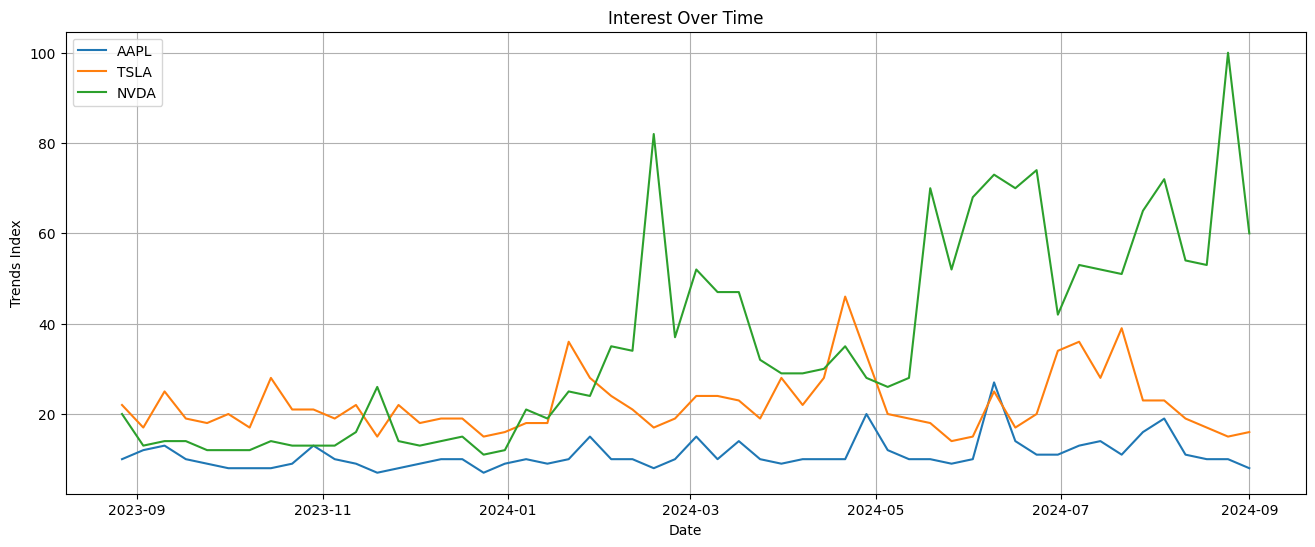

In [30]:
# Initialize an instance of the TrendReq class with US region and 360 timezone
pytrends = TrendReq(hl='en-US', tz=360)

# Define the list of keywords and timeframe
kw_list = ["AAPL", "TSLA", "NVDA"]
timeframe = '2023-09-01 2024-09-01' # for latest 12 months replace with 'today 12-m'

# Build the payload and get the interest over time data
pytrends.build_payload(kw_list, timeframe=timeframe)
interest_over_time_df = pytrends.interest_over_time()

# Create a figure and axes and plot the data
plt.figure(figsize=(16, 6))
for term in kw_list:
  plt.plot(interest_over_time_df.index, interest_over_time_df[term], label=term)

plt.xlabel('Date')
plt.ylabel('Trends Index')
plt.title('Interest Over Time')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

Now that we have the plot, here are some key things to pay attention to and analyze:

**Overall Trends:**
 - Upward/Downward: Are the trends generally increasing, decreasing, or remaining stable over the year? This can indicate growing or waning interest in the companies.
 - Seasonality: Do we notice any recurring patterns or spikes at certain times of the year? This could be related to product releases, financial reports, or other events.

**Relative Popularity:**
 - Comparison: Which keyword shows the highest overall interest? Which one shows the lowest? This can give us an idea of the relative popularity of these companies in terms of search volume.
 - Crossovers: Are there points where the trends for different keywords intersect? This could signal shifts in public attention or perception.

**Volatility:**
 - Fluctuations: How much do the trends fluctuate over time? Large swings might suggest sensitivity to news or market events.
 - Outliers: Are there any significant spikes or dips that stand out? Try to investigate what might have caused them (e.g., news announcements, product launches, controversies).

**Correlation:**
 - Relationship: Do the trends for different keywords seem to move together or independently? This can indicate whether they are influenced by similar factors or not.

By carefully examining these aspects of the plot, we can gain insights into the search behavior related to these companies and potentially draw conclusions about their public perception and market performance.

For our example specifically, peaks and troughs can be observed, with NVIDIA (NVDA) experiencing a significant peak around March 2024, nearly reaching a trend index of 80, and then again over most recent period by end of August 2024. Suc high index could coincide with significant events related to NVIDIA, such as product launches, earnings reports, or market developments. In fact, in March 2024, NVIDIA made significant announcements related to its next-generation GPU architecture called Blackwell. This architecture boasts an impressive 208 billion transistors and is designed to run real-time generative AI models. The anticipation around Blackwell likely contributed to the increased interest in NVIDIA during that time. Additionally, in August 2024, NVIDIA continued to unveil innovations related to AI and data center performance at the Hot Chips conference, further fueling interest in the company. These events and technological advancements likely explain the observed spikes in interest for NVIDIA during those months.

Apple (AAPL) and Tesla (TSLA) exhibit varying trends over the same period. While both companies generally maintain interest, their fluctuations are less pronounced compared to NVIDIA. Analyzing news or corporate announcements during these timeframes might shed light on the reasons behind these trends.

We also need to consider exploring correlations between the interest trends in these companies and broader market indices (e.g., S&P 500). If there's a strong positive correlation, it could indicate that overall market sentiment influences interest in specific stocks.

We also need to observe any recurring patterns across different months or quarters. Seasonal factors (e.g., holiday seasons, earnings seasons) might impact investor sentiment and interest levels.

 - TSLA Peaks: Tesla (TSLA) usually experiences noticeable peaks around April and July each year. These could align with quarterly earnings reports or significant announcements related to Tesla's products or business developments.
 - AAPL Trends: Apple (AAPL) usually shows a consistent upward trend around September and January. These months often coincide with new product launches (e.g., iPhone releases) and holiday seasons.
 - NVDA Fluctuations: NVIDIA (NVDA) exhibits less predictable patterns, but there are fluctuations around March and August. Investigate whether industry-specific events or conferences occur during these months.

### **1.3 Analyzing Interest by other metrics**

Google Trends also allow to fetch other details in relation to our search query:

 - **Interest by subregion** lets us see how interest in a particular search term varies across different geographical areas within a larger region.
 - **Related topics** are broader subjects or concepts that are associated with our keyword, and which were also searched by other users.
 - **Related queries** are specific search terms that people have used in conjunction with our keyword. These are actual queries entered into the search engine by other users during the same time period.

#### **Analyzing Interest by Region**

Now, let's fetch the interest by region for a search term NVDA and identify the top 10 regions with the highest interest:

In [31]:
# Initialize an instance of the TrendReq class and build the payload
pytrends = TrendReq(hl='en-US', tz=360)
pytrends.build_payload(["NVDA"], timeframe='2023-09-01 2024-09-01')

# Get the interest by region data
interest_by_region_df = pytrends.interest_by_region()
interest_by_region_df.sort_values(by='NVDA', ascending=False).head(10)

,NVDA
geoName,
Hong Kong,100
Taiwan,83
Israel,81
United States,67
Singapore,62
Canada,59
China,33
Switzerland,15
South Korea,13


This output shows the top 10 regions with the highest search interest for "NVDA" during the specified period ('2023-09-01 2024-09-01'). The values represent the relative popularity of the search term in each region, where 100 is the highest value.

For example, Hong Kong has the highest search interest for "NVDA" with a value of 100, followed by Taiwan and Israel with a value of 79 each.

This data can be useful for businesses to understand the geographic distribution of interest in their products or services. It can also be used for market research and to identify potential target markets. Please note that further analysis and correlation with other data sources would be needed to draw definitive conclusions.

#### **Related Queries and Topics**

Top and rising related topics and queries can be extremely useful for financial engineering tasks because they provide insights into the collective "mind of the market" and reveal trends that might not be obvious from traditional financial data.

**Related Topics** are broader themes associated with NVDA. This can help to identify:
 - Industry trends: Are there broader trends in gaming, AI, or data centers that are influencing interest in NVDA?
 - Investment themes: Are there specific investment themes (e.g., growth stocks, tech stocks) that are driving interest in NVDA?

**Related Queries** are other terms people search for in conjunction with NVDA keyword. This can reveal:
 - Emerging trends: Are there new or rising keywords that indicate shifting interest or new areas of focus for NVDA?
 - Competitor analysis: Are people searching for NVDA in comparison to its competitors?
 - Public perception: What are the main concerns or interests people have regarding NVDA?

Both Related Topics and Related Queries can be filtered to get Top and Rising terms for each:

 - **Top** - these are most popular search topics/queries. Scoring is on a relative scale from 100 as the most commonly searched topic/querie, 50 for query searched half as often, and so on.
 - **Rising** - these are topics/queries with the biggest increase in search frequency since the last time period. Results marked "Breakout" had a tremendous increase, probably because these topics/queries are new and had few (if any) prior searches.


In this lesson we will focus on Related Queries. Both top and rising related queries offer valuable insights, but they serve different purposes. The best choice depends on specific goals and the type of analysis we are conducting. From a financial engineering perspective, the choice between top and rising related queries still depends on our specific goals, but here's a more tailored recommendation:

 - **For Algorithmic Trading and Sentiment Analysis:** Rising queries are generally more valuable. They can provide real-time signals for sentiment-based trading strategies. We could build a system that automatically adjusts portfolio positions or generates trading signals based on changes in the sentiment expressed in rising queries. For example if we observe a sudden surge in negative sentiment related to a company we hold in our portfolio, algorithm could automatically reduce exposure to that stock.

 - **For Risk Management:** Rising queries are crucial for early warning signs. A spike in searches for terms related to lawsuits, regulatory investigations, or product recalls could indicate potential risks for a company or industry. We can integrate rising query analysis into risk management system to identify and assess potential threats proactively.

 - **For Portfolio Optimization and Asset Allocation:** Both top and rising queries can be useful.
   - Top queries: Can help to understand the main themes and drivers of different assets or industries, allowing to diversify portfolio accordingly.
   - Rising queries: Can help to identify emerging themes or potential risks that might warrant adjustments to portfolio.

 - **For Quantitative Research and Modeling:** Both types of queries can be valuable as alternative data sources.
    - Rising queries: Can be used to create sentiment indicators or event detection signals that can be incorporated into quantitative models.
    - Top queries: Can be used to understand the relationships between different assets or industries based on the themes and concerns expressed in search queries.

Overall, while both have their uses, rising queries tend to be more valuable for financial engineering applications that require real-time insights and a focus on short-term trends and sentiment shifts. Top queries provide a broader understanding of market perception, which can be useful for longer-term strategies and fundamental analysis. Remember to consider the challenges of noise, data quality, and the need for sophisticated analysis techniques when working with both types of queries.

Please also note that narrowing the time period for fetching insights from rising related queries can be very beneficial, especially when our goal is to detect short-term trends or capture immediate market reactions. Shorter timeframe generally provides a good balance between sensitivity, data availability, and actionability. We can experiment with different timeframes to find what works best for our specific needs and the volatility of the assets we are analyzing.

Let's now fetch the top and rising related queries for 'NVDA' search term for the period from 2024-05-01 to 2024-09-01 and analyze the results. This time we manually downloaded the data in CSV format and saved locally as 'NVDA-relatedQueries.csv'. CSV file from Google Trends containing related queries typically presents the data in a stacked format:  The "Rising" queries data is typically stacked below the "Top" queries data in the same CSV file. There might be a blank row or a visual separator (like a line of dashes) to distinguish the two sections. The code below addresses the specific structure of the Google Trends CSV file, particularly the stacking of "Top" and "Rising" queries. First we read CV file into DataFrame. Then find the start and end rows for each section and finally extract each section with simultaneously splitting column on comma and formatting values:

In [36]:
# Read the CSV file, specifying the python engine to avoid the warning
df = pd.read_csv('NVDA-relatedQueries.csv', header=None, delimiter='\\t', engine='python')

# Find the start and end rows for each section
top_start = df[df.iloc[:, 0] == 'TOP'].index[0] + 1
top_end = df[df.iloc[:, 0] == 'RISING'].index[0] - 1
rising_start = df[df.iloc[:, 0] == 'RISING'].index[0] + 1
rising_end = df.shape[0]  # End of the DataFrame

In [34]:
# Extract top queries
queries_top = df.iloc[top_start:top_end].copy()
queries_top = queries_top.rename(columns={queries_top.columns[0]: 'top_queries'})

# Split the 'top_queries' column and convert 'value' to numeric
queries_top[['top_query', 'value']] = queries_top['top_queries'].str.split(',', expand=True)
queries_top = queries_top[['top_query', 'value']]
queries_top.loc[:, 'value'] = pd.to_numeric(queries_top['value'])
queries_top

,top_query,value
3,stock nvda,100
4,nvda price,23
5,stock price nvda,20
6,tsla,7
7,amd,7
8,amd stock,7
9,aapl,7
10,tsla stock,6
11,aapl stock,6
12,amzn,5


In [35]:
# Extract rising queries
queries_rising = df.iloc[rising_start:rising_end].copy()
queries_rising = queries_rising.rename(columns={queries_rising.columns[0]: 'rising_queries'})

# Split the 'rising_queries' column aon the first comma
queries_rising[['rising_query', 'value']] = queries_rising['rising_queries'].str.split(',', n=1, expand=True)
queries_rising = queries_rising[['rising_query', 'value']]

# Clean the 'value' column
queries_rising['value'] = queries_rising['value'].str.replace(r'[^0-9.-]', '', regex=True)  # Keep only numbers, dots, and minus signs
queries_rising.loc[:, 'value'] = pd.to_numeric(queries_rising['value'], errors='coerce')  # Convert to numeric

# Display 'rising_queries'
queries_rising

,rising_query,value
29,ffie stock,3200
30,ffie,3150
31,serv stock,2800
32,asts,750
33,asts stock,700
34,nvda split date,700
35,nvda stock split date,550
36,gme stock,550
37,gme,550
38,gamestop stock,400


The rising queries for "NVDA" provides some interesting insights, particularly regarding the upcoming earnings announcement. Here's what we can gather:

 - Earnings Dominate: The overwhelming focus is on NVDA's earnings. Terms related to earnings are all experiencing massive increases in search interest. This signifies a high level of anticipation and interest in the company's financial results.

 - Real-Time Information: The "Breakout" trend for "nvda earnings time today" suggests that people are actively seeking real-time information about the earnings announcement, possibly during the day of the release.

 - Global Interest: The presence of Japanese and Chinese characters indicates that interest in NVDA's earnings extends beyond English-speaking regions, highlighting the company's global reach.

 - Investor Focus: Terms like "nvda investor relations" and "when does nvda report earnings" suggest that investors are actively seeking information about the earnings release and possibly preparing for potential market reactions.

 - Financials and Nasdaq: The rise of "nasdaq nvda financials" suggests that people are looking for detailed financial information about NVDA, possibly on the Nasdaq website or other financial platforms.

 - Other Stocks and Potential Noise: While earnings-related terms dominate, there are some outliers like "lunr stock," "pdd stock," "crm stock," "chwy stock," and "afrm stock" These might be related to other companies or market trends and could potentially be noise in the context of analyzing NVDA. Further investigation would be needed to understand their relevance.

### **1.4 Considerations and Limitations when using Google Trends data**

When using Google Trends data for financial analysis, we should be aware of its limitations. While Google Trends data can be insightful, it's crucial to understand its limitations regarding data quality. Here are some key aspects to keep in mind:

 - **Sampling:** Google Trends data is based on a sample of searches, not the entire search volume and the exact sampling methodology isn't publicly disclosed. This means there's inherent sampling error, and the data might not perfectly represent the entire population of searches. This means there might be some noise and the data may not perfectly reflect the actual search interest.
 - **Data Updates:** Google Trends data might be updated or revised over time as Google refines its algorithms and data processing techniques. This means that historical data you accessed previously could potentially change slightly in the future.
 - **Normalization:** Google Trends data is normalized, meaning the values are relative to the highest point in the timeframe you select. The data is normalized to a scale of 0 to 100. A value of 100 represents the peak popularity, while other values are scaled proportionally. This means the values represent the relative popularity of a search term compared to the highest point in the selected timeframe. While normalization helps in comparing trends, it can also mask the absolute search volume, which might be relevant in some cases.
 - **Geographic Granularity:** The level of geographic detail available in Google Trends data varies depending on the search term and the time period. For some terms or regions, the data might be more granular, while for others, it might be more aggregated. This can affect the accuracy of regional analysis.
 - **External Factors:** Search behavior can be influenced by various external factors, such as media coverage, news events, seasonality, and even the popularity of other search terms. These factors can introduce noise and bias into the data, making it challenging to isolate the true underlying trends.
 - **Privacy:** Google Trends data is anonymized and aggregated, but it's still important to be mindful of privacy considerations, especially when dealing with sensitive topics.


By understanding these data quality considerations and taking appropriate precautions, we can use Google Trends data more effectively and draw more reliable conclusions for financial analysis. Rememebr that context is key. We need to consider the context surrounding the data, such as potential external factors that might be influencing search behavior.

## **2 Latent Semantic Analysis**

Up until now we explored Google Trends data and explored simple examples of using `pytrends` to gather data. While `pytrends` itself provides valuable insights into search trends, incorporating machine learning techniques like Latent Semantic Analysis (LSA) can offer several advantages.

Before intrducing LSA, we need to understand some terminology. In the context of LSA, a "**document**" refers to a unit of text that we want to analyze. It can be anything from a single sentence to a whole article, a book, or even a collection of related texts. The key is that it represents a distinct piece of information that we want to compare and analyze in relation to other documents. Here are some examples of what could be considered a "document" in different LSA applications:

 - **Topic Modeling:** Each document could be a news article, a blog post, or a social media post. LSA can help identify the main topics discussed across these documents.
 - **Information Retrieval:** Each document could be a web page, a research paper, or a product description. LSA can help find documents that are semantically similar to a given query.
 - **Document Classification:** Each document could be an email, a customer review, or a legal contract. LSA can help categorize these documents based on their content.

Latent Semantic Analysis (LSA) is a technique in natural language processing that analyzes relationships between a set of documents and the terms they contain by producing a set of concepts related to the documents and terms. LSA assumes that words that are close in meaning will occur in similar pieces of text. Incorporating machine learning techniques like LSA can offer several advantages:

 - **Uncovering Hidden Relationships:** LSA can reveal hidden relationships between terms and concepts that might not be apparent from simply looking at raw search data. This can help us understand the underlying semantic structure of the search queries related to our documents.

 - **Dimensionality Reduction:** LSA can reduce the dimensionality of our data by representing it in a lower-dimensional concept space. This can make it easier to analyze and visualize the data, especially when dealing with a large number of terms.

 - **Improved Search and Recommendation:** By understanding the relationships between terms and concepts, we can build more intelligent search engines and recommendation systems. For example, we could suggest related searches or recommend documents based on semantic similarity rather than just keyword matching.

 - **Topic Modeling:** LSA can be used for topic modeling, which allows us to discover the main topics or themes present in a set of documents or search queries. This can help us understand the broader context of the information and potentially categorize or cluster documents more effectively.

In a nutshell, LSA is used to analyze textual data and is a method for extracting and representing the contextual-usage meaning of words by statistical computations applied to a large corpus of text. LSA is a powerful tool for analyzing textual data, but it has some limitations. For example, it is not very good at handling polysemy (words with multiple meanings) or synonymy (different words with the same meaning).

In this lesson we will explore basic example of how we could use LSA to analyze related search terms and improve our understanding of user search behavior. The choice of what constitutes a document depends on our specific application and the kind of analysis we want to perform. It's important to ensure that our documents are meaningful and relevant to the task at hand. A collection of documents is collectively called as "**term-document matrix**".

Financial engineers might approach document composition for LSA or similar techniques in different ways:

 - Domain Expertise: Financial engineers often have deep domain expertise and carefully select keywords and phrases based on their understanding of financial markets, specific assets, and relevant events.

 - Data Sources: They may use a wider range of data sources beyond just Google Trends, such as News articles and sentiment analysis, Social media data, Company filings and earnings call transcripts, Proprietary datasets.

 - Sophisticated Preprocessing: They might employ more advanced natural language processing techniques for preprocessing, including Named entity recognition (identifying companies, people, locations), Sentiment analysis (assigning sentiment scores to text), Topic modeling (identifying underlying topics in documents).

 - Ensemble Methods: They may combine LSA with other machine learning techniques or use ensemble methods to improve the accuracy and robustness of their models.

 - Backtesting and Validation: Financial engineers rigorously backtest and validate their models using historical data to ensure they are reliable and can potentially generate profitable trading signals or investment strategies.

Fow our example we will create term-document matrix with the following set of documents:

 > Document 1: "Risk management in derivatives trading", \
 > Document 2: "Portfolio optimization techniques and strategies", \
 > Document 3: "Algorithmic trading and its impact on market efficiency", \
 > Document 4: "Quantitative methods for financial modeling", \
 > Document 5: "High-frequency trading and liquidity provision", \
 > Document 6: "Integrating Derivatives into Portfolio Optimization Strategies", \
 > Document 7: "High-Frequency Trading Strategies: Algorithmic Approaches and Market Impact", \
 > Document 8: "Quantitative Methods for Algorithmic Trading and Portfolio Optimization" \

Before proceeding with code, let's observe that documents in our term-document matrix contain such words as "in", "and", "for", "on". These words are called **stop words**. They are common words that generally don't carry much specific meaning in the context of text analysis. It's often beneficial to remove stop words from text data before creating the term-document matrix. This can help to:

 - **Reduce noise:** Stop words can add noise to our data and obscure the more important terms that convey the main topics or themes.
 - **Improve efficiency:** Removing stop words can reduce the size of our matrix, making computations faster and more efficient.
 - **Focus on relevant terms:** By eliminating common words, we can focus on the more meaningful terms that are specific to our documents and application.

We will also apply lemmatization technique. **Stemming and lemmatisation** are two text preprocessing techniques used in Natural Language Processing (NLP) that help to reduce words to their base form.
 - **Stemming** reduces words to their stem, which are not necessarily real words, by removing prefixes and sufixes. For example "playing" would become "play", "studies" would become "studi", and "happily" would become "happi".
 - **Lemmatization** reduce words to their dictionary form or base form known as lemma. For example "playing" would become "play", "studies" would become "study", and "better" would become "good".

In our example we consider lemmatization: Given the specific and potentially nuanced language of finance, lemmatization is likely to be more beneficial than stemming. It can help group different forms of words (e.g., "analyze," "analyzing," "analysis") while preserving their core meaning.

Now that we made clear of all basic termonology and LSA definition, let's proceed with preparing our data. The following Python code performs exactly that:

In [37]:
# Sample documents
documents = [
    "Risk management in derivatives trading",
    "Portfolio optimization techniques and strategies",
    "Algorithmic trading and its impact on market efficiency",
    "Quantitative methods for financial modeling",
    "High-frequency trading and liquidity provision",
    "Integrating Derivatives into Portfolio Optimization Strategies",
    "High-Frequency Trading Strategies: Algorithmic Approaches and Market Impact",
    "Quantitative Methods for Algorithmic Trading and Portfolio Optimization"
]

# Download stopwords and WordNet resources and then create a Lemmatizer Object
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
lemmatizer = WordNetLemmatizer()

# construct text preprocessing function
def preprocess_text(text):
    text = re.sub(r'[^\w\s-]', '', text)  # Remove punctuation except hyphens
    tokens = nltk.word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(token) for token in tokens] # Lemmatize
    stop_words = set(stopwords.words('english')) # define stop_words as a set of english stop words
    tokens = [token for token in tokens if token not in stop_words] # Remove stop words
    return tokens

# Create a CountVectorizer object
vectorizer = CountVectorizer(tokenizer=preprocess_text, token_pattern=None)

# Create the term-document matrix, then convert to a pandas DataFrame
term_document_matrix = vectorizer.fit_transform(documents)
df = pd.DataFrame(term_document_matrix.toarray(), columns = vectorizer.get_feature_names_out())
term_document_matrix = df.T
print(term_document_matrix)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                0  1  2  3  4  5  6  7
algorithmic     0  0  1  0  0  0  1  1
approach        0  0  0  0  0  0  1  0
derivative      1  0  0  0  0  1  0  0
efficiency      0  0  1  0  0  0  0  0
financial       0  0  0  1  0  0  0  0
high-frequency  0  0  0  0  1  0  1  0
impact          0  0  1  0  0  0  1  0
integrating     0  0  0  0  0  1  0  0
liquidity       0  0  0  0  1  0  0  0
management      1  0  0  0  0  0  0  0
market          0  0  1  0  0  0  1  0
method          0  0  0  1  0  0  0  1
modeling        0  0  0  1  0  0  0  0
optimization    0  1  0  0  0  1  0  1
portfolio       0  1  0  0  0  1  0  1
provision       0  0  0  0  1  0  0  0
quantitative    0  0  0  1  0  0  0  1
risk            1  0  0  0  0  0  0  0
strategy        0  1  0  0  0  1  1  0
technique       0  1  0  0  0  0  0  0
trading         1  0  1  0  1  0  1  1


This matrix shows the relationships between the terms (rows) and documents (columns). For example:

 - The term "algorithmic" appears (value of 1) in documents 3, 7 and 8.
 - The term "trading" appears in documents 1, 3, 5, 7 and 8.
 - Document 1 contains the terms "derivatives", "management", "risk" and "trading".

This matrix is the foundation for applying LSA or other dimensionality reduction techniques.

### **2.1 How LSA relate to SVD**

LSA uses Singular Value Decomposition (SVD) at its core to find the hidden relationships between terms and concepts. Singular Value Decomposition is a fundamental concept in linear algebra and a powerful technique used in many areas, including machine learning and natural language processing. Here's how it works:

 1. Document-Term Matrix: LSA starts with a document-term matrix, where each row represents a document and each column represents a term (word). The cells contain the frequency of each term in each document.

 2. SVD Application or Matrix Factorization: SVD is applied to Document-Term matrix. SVD is a way to factorize (break down) a matrix into three separate matrices. It decomposes the matrix into three matrices:

   - $U$: Represents document-to-concept similarity.
   - $\Sigma$: A diagonal matrix containing singular values, representing the importance of each concept.
   - $V$: Represents term-to-concept similarity.

   - The Formula: The relationship between the original matrix ($A$) and the decomposed matrices is: $A = U \Sigma V^T$ (where $V^T$ is the transpose of $V$).

 3. Dimensionality Reduction: By keeping only the largest singular values (and corresponding columns/rows in $U$ and $V$), we reduce the number of dimensions (concepts) while preserving the most important information. This is similar to Principal Component Analysis (PCA).

 4. Concept Space: The resulting matrices represent documents and terms in a new "concept space". Words with similar meanings will be closer together in this space, even if they don't appear in the same documents.

In essence, SVD in LSA helps to:

 - **Uncover latent relationships:** Identify underlying concepts that are not explicitly present in the text.
 - **Reduce noise:** Filter out less important information and focus on the core meaning.
 - **Improve information retrieval:** Represent documents and queries in a way that captures semantic similarity.

This process allows LSA to go beyond simple keyword matching and understand the meaning of text at a deeper level.

Let's now proceed with python code where we will use `TruncatedSVD` from `scikit-learn`, essentially performing Singular Value Decomposition (SVD) under the hood. `TruncatedSVD` is an efficient implementation of SVD specifically designed for dimensionality reduction. It calculates the SVD and then keeps only the top `n_components` singular values and their corresponding vectors. This truncated version of the SVD is what produces the `lsa_matrix`, which represents our data in a lower-dimensional concept space.

**Important:** The output of LSA can be different each time we run the code. This is due to the random initialization of the `TruncatedSVD` algorithm. The variation is related to the nature of Singular Value Decomposition (SVD) and how LSA uses it. Here's a breakdown of the key factors:

 - Rotation in Concept Space: SVD essentially finds the best way to represent our data in a new "concept space." The components (or dimensions) in this space are determined by finding the directions of greatest variance in the original data. However, there is often some flexibility in how these components are oriented (rotated). Think of it like rotating a 3D object -- the object remains the same, but its projection onto the axes changes.

 - Sign Ambiguity: The signs (positive or negative) of the values in the LSA output can flip without changing the underlying meaning. This is because the direction of a component is arbitrary. Imagine a component representing "financial modeling" -- it doesn't matter if it points in one direction or the opposite direction; it still captures the same concept.

 - Sensitivity to Small Changes: SVD can be sensitive to small changes in the input data. Even minor variations in word frequencies or the addition/removal of a few documents can lead to some degree of rotation in the concept space, resulting in different term loadings.

 - Random Initialization: As mentioned before, the TruncatedSVD algorithm often uses random initialization, which can contribute to variations in the output.

While these variations might seem concerning, they usually don't drastically change the overall interpretation of the LSA results. The relative positions of terms in the concept space and the general patterns of similarity are generally preserved. To ensure consistent results, we will set the `random_state` parameter to a fixed value when creating the `TruncatedSVD` object. This will produce the same output each time we run the code.

In [38]:
# Get the terms (words) from the term-document matrix
terms = term_document_matrix.index

# Create an LSA model and fit to term_document_matrix
lsa = TruncatedSVD(n_components=2, random_state=42)
lsa_matrix = lsa.fit_transform(term_document_matrix)

# Create DataFrame for LSA results with term names and print it
df_lsa = pd.DataFrame(lsa_matrix, index=terms)
print(df_lsa)

                       0         1
algorithmic     1.487743 -0.457823
approach        0.578476 -0.378199
derivative      0.492907  0.525547
efficiency      0.427052 -0.387020
financial       0.099332  0.155108
high-frequency  0.812589 -0.596790
impact          1.005528 -0.765219
integrating     0.286096  0.555942
liquidity       0.234112 -0.218591
management      0.206810 -0.030394
market          1.005528 -0.765219
method          0.581547  0.462505
modeling        0.099332  0.155108
optimization    1.015624  1.343809
portfolio       1.015624  1.343809
provision       0.234112 -0.218591
quantitative    0.581547  0.462505
risk            0.206810 -0.030394
strategy        1.111885  0.658213
technique       0.247313  0.480471
trading         1.928666 -0.706808


Interpreting the results of LSA involves understanding the new semantic space created by the dimensionality reduction and analyzing the relationships between terms and documents in this space. Here is how to interpret the results:
 - Interpretting the Columns: These are also known as Components or Concepts or Dimensions. Think of each component as representing a hidden "concept" or "topic" within documents.
 - Interpreting the rows: Each row in this matrix represents a term from our original matrix, but now projected onto a 2-dimensional concept space (because we chose `n_components=2`).
 - Interpreting the values:
   - The two values in each row represent the coordinates of that term in the new concept space. Terms with similar coordinates are closer together in the concept space, indicating a semantic relationship. In our example first row represents the term "algorithmic". Its coordinates are approximately (1.488 -0.458). If another term, has similar coordinates, it suggests that these terms are related in the context of our documents.
   - The values represent the loading of that term on the corresponding component. The loadings tell us how much each term contributes to that concept. For example, "algorithmic" and "trading" have high loadings on Component 1, suggesting that Component 1 represents the concept of "algorithmic trading". A higher value (positive or negative) indicates a stronger association between the term and that component.

From the output of our code we can interpret the relationships between terms by looking at their coordinates and draw some preliminary observations:

 - **Distinct Clusters:**
   - Trading Cluster: "algorithmic", "high-frequency", "impact", "market", and "trading" have high values for component 0 and mostly negative values for component 1. This reinforces the idea that component 0 represents concepts related to automated and high-frequency trading, and their potential impact on the market.

   - Portfolio and Optimization Cluster: "optimization" and "portfolio" form a clear cluster with high positive values for both components. This suggests a strong association between these terms, likely related to portfolio optimization techniques.

   - Derivatives and Method-Quantitative Cluster: Grouping "method", "quantitative", and "derivative" together suggests a potential connection between quantitative methods and their application to derivatives.

   - Management-Risk-Liquidity-Provision Cluster: Combining "management", "risk", "liquidity", and "provision" suggests a cluster related to managing financial risk and ensuring liquidity. This also seems plausible, as these concepts are often intertwined in financial contexts, particularly when dealing with derivatives or trading activities.

 - **Other Observations:**
   - "Trading" as a central concept: "trading" has the highest value for component 0, indicating its importance and potential connection to various forms of trading discussed in the documents.
   - Distinct Pairs: The pair of terms "financial" and "modeling" form very distinct pair due to their identical coordinates. Further analysis is needed to determine their relationship to other terms and clusters.
   - Overlap between clusters: Some terms, like "strategy" and "technique", have moderate values in multiple components, suggesting potential overlap or connections between different clusters.

This quick analysis gives somewhat good overview of the relationships between terms based on the LSA results.

We can now plot the coordinates to visualise them and confirm if these proposed clusters appear close together in visual representation. To achieve this, we will use `plotly.graph_objects` module imported as `go`:

In [39]:
# Create a list of hover texts with labels and coordinates
hover_texts = []
for row in df_lsa.values:
    terms = df_lsa.index[(df_lsa[0] == row[0]) & (df_lsa[1] == row[1])]
    terms_str = ', '.join([f'\"{term}\"' for term in terms])
    coord = f"({row[0]:.5f}, {row[1]:.5f})"
    hover_texts.append(f"Terms: {terms_str}<br>{coord}")

# Create the scatter plot
fig = go.Figure(go.Scatter(
    x=df_lsa[0],
    y=df_lsa[1],
    mode='markers',
    marker=go.scatter.Marker(
        size=10,
        color='blue',
        opacity=0.8
    ),
    hovertemplate='%{text}<extra></extra>',
    text=hover_texts
))

# Set axis labels and title
fig.update_layout(
    xaxis_title="Component 0",
    yaxis_title="Component 1",
    title="LSA Results Scatter Plot"
)

fig.show()

Plotly plots are interactive by default. We can use its interactive features to pan/zoom and hover/select to see tooltips with term lables and coordinates.

Now looking at this plot it seems that clusters are not that easy to visualise. It seems that we were too focused on the moderate values of term coordinates, without paying enough attention to the precise distances between them. To determine clusters more accurately, we should use a more formal methods. By using these methods, we can avoid subjective interpretations and define clusters more precisely based on quantitative measures of similarity or distance. We will consider these methods later in this lesson.

### **2.2 Important considerations with LSA and SVD**

#### **Choosing the optimal number of components for LSA**

Choosing the optimal number of components (`n_components`) for LSA is a crucial step. Here are some considerations:

 - **Start small:** Begin with a small number of components (e.g., 2, 3, or 5) to see if it gives a good initial understanding of the relationships between terms and documents. This can help to get a feel for the data and identify potential clusters or topics.
 - **Iteratively increase:** Gradually increase the number of components and observe how the interpretation of the results changes. Look for a point where adding more components doesn't significantly improve the interpretability or reveal new meaningful relationships.
 - **Consider the size of corpus:** For smaller corpora, fewer components might suffice to avoid overfitting. For larger corpora, more components could capture more subtle semantic relationships.
 - **Focus on semantic coherence:** Evaluate the semantic coherence of the resulting topics or clusters. Do the terms within each cluster make sense together? Are the clusters distinct and meaningful? If the coherence decreases as we add more components, it might be a sign that we are starting to overfit.
 - **Balance dimensionality reduction with information loss:** LSA involves a trade-off between reducing dimensionality and preserving information. We should try to find a sweet spot where we have a manageable number of components while still capturing the most important semantic relationships.

In summary, there is no one-size-fits-all answer for the optimal number of components in LSA. It depends on specific data and goals. We would need to experiment with different values, carefully evaluate the results, and use domain knowledge to guide our choice.


#### **Understanding limitations of LSA and SVD**

As we observe from above example some terms are clustered as they appear in particular document. For example "algorithmic", "high-frequency", "impact", "market", and "trading" are similar terms making one cluster. And they are all from document 7.

This is crucial point about Latent Semantic Analysis (LSA) and its potential limitations. If LSA consistently clusters terms solely based on their co-occurrence within the same document, it raises questions about its effectiveness in capturing broader semantic relationships.

Here's a breakdown of why this might happen and what it means for LSA:

 - **Document-Specific Context:** LSA primarily relies on word co-occurrence patterns within a corpus. If terms frequently appear together in a single document but not across the entire corpus, LSA might interpret them as semantically related even if their broader contextual meanings differ significantly.
 - **Limited Corpus Size or Diversity:** A small or homogenous corpus can exacerbate this issue. If documents within the corpus lack diversity in topics and language use, LSA might struggle to identify broader semantic relationships beyond document-level co-occurrences.
 - **Data Sparsity:** In LSA, the term-document matrix can be very sparse, especially with a large vocabulary. This sparsity can sometimes lead to the model focusing on local co-occurrence patterns within documents rather than global semantic relationships.

So, what's the point of LSA if it primarily identifies document-level clusters? While the scenario we encounter isn't ideal, LSA can still offer valuable insights:

 - **Document Summarization:** LSA can be effective in identifying key terms and concepts within individual documents, which is useful for summarization and topic extraction.
 - **Dimensionality Reduction:** Even if clusters are document-specific, LSA effectively reduces the dimensionality of the data, making it easier to analyze and visualize.
 - **Basis for Other Techniques:** LSA can serve as a foundation for more advanced topic modeling techniques that address its limitations, such as Latent Dirichlet Allocation (LDA).

To improve LSA's performance and capture broader semantic relationships:

 - **Increase Corpus Size and Diversity:** Include a wider range of documents on different topics with diverse language use.
 - **Preprocessing and Feature Engineering:** Carefully preprocess the text (e.g., removing stop words, stemming/lemmatization) and consider using different weighting schemes (e.g., Term Frequency-Inverse Document Frequency or TF-IDF in short, a numerical statistic used in information retrieval and text mining to reflect how important a word is to a document in a collection or corpus.) to emphasize more informative terms.
 - **Explore Other Techniques:** Consider using alternative topic modeling techniques like LDA, which explicitly models the distribution of topics within documents.

In summary, while LSA can be useful for document-level analysis, its limitations in capturing broader semantic relationships should be considered. Ensuring a diverse and representative corpus and exploring alternative techniques can help overcome these limitations and unlock the full potential of topic modeling.

## **3 Compute Similarity Measures**

In this subsection we will appply several of the similarity measures to our LSA results to further analyse terms in LSA space.

It is generally not best practice to rely solely on one similarity measure, especially when exploring complex datasets or tasks. Different similarity measures have different strengths and weaknesses and may capture different aspects of similarity.

### **3.1 Cosine similarity measure between terms**

Cosine similarity is a common way to measure the similarity between vectors in the LSA space. The following code helps to quantify the semantic similarity between terms within the first distinct cluster (terms: "algorithmic", "high-frequency", "impact", "market", "trading") based on their representations in the LSA concept space:

In [40]:
# Extract term vectors for first distinct cluster
terms_cl1 = ["algorithmic", "high-frequency", "impact", "market", "trading"]
term_vectors_cl1 = df_lsa.loc[terms_cl1]

# Calculate cosine similarity
similarity_matrix = cosine_similarity(term_vectors_cl1)

# Convert to DataFrame for better visualization
similarity_df = pd.DataFrame(similarity_matrix, index=terms_cl1, columns=terms_cl1)

# Print the results for the first distinct cluster with labels
print("Cosine similarity for first distinct cluster:")
print(similarity_df)

Cosine similarity for first distinct cluster:
                algorithmic  high-frequency    impact    market   trading
algorithmic        1.000000        0.944434  0.938692  0.938692  0.998609
high-frequency     0.944434        1.000000  0.999855  0.999855  0.960449
impact             0.938692        0.999855  1.000000  1.000000  0.955562
market             0.938692        0.999855  1.000000  1.000000  0.955562
trading            0.998609        0.960449  0.955562  0.955562  1.000000


This matrix shows the pairwise cosine similarity between the terms in the first distinct cluster. The values range from 0 to 1, where 1 indicates perfect similarity and 0 indicates no similarity. Here are some observations:

 - High similarity within the cluster: Most of the values in the matrix are close to 1, indicating that the terms in this cluster are highly semantically similar. This is expected since they were identified as a cluster in the LSA analysis.
 - "Impact" and "market" are perfectly similar: The cosine similarity between "impact" and "market" is 1, suggesting that they are considered synonymous in the context of this corpus.
 - "Algorithmic" and "trading" are very similar: The cosine similarity between "algorithmic" and "trading" is very high (0.998), indicating a strong semantic connection between these terms. This makes sense as "algorithmic trading" is a common concept.
 - "High-frequency" is slightly less similar: "High-frequency" has slightly lower similarity scores compared to other terms, suggesting that it might have a slightly different meaning or context within this cluster.

This analysis confirms that the terms in the first distinct cluster are indeed semantically related based on their cosine similarity.

Let's now compute cosine similarity for terms in the fourth cluster:

In [41]:
# Extract term vectors for fourth cluster
terms_cl4 = ["management", "risk", "liquidity", "provision"]
term_vectors_cl4 = df_lsa.loc[terms_cl4]

# Calculate cosine similarity
similarity_matrix = cosine_similarity(term_vectors_cl4)

# Convert to DataFrame for better visualization
similarity_df = pd.DataFrame(similarity_matrix, index=terms_cl4, columns=terms_cl4)

# Print the results for the fourth cluster with labels
print("Cosine similarity for fourth cluster:")
print(similarity_df)

Cosine similarity for fourth cluster:
            management      risk  liquidity  provision
management    1.000000  1.000000   0.822387   0.822387
risk          1.000000  1.000000   0.822387   0.822387
liquidity     0.822387  0.822387   1.000000   1.000000
provision     0.822387  0.822387   1.000000   1.000000


## **3 Compute Similarity Measures**

In this subsection we will appply several of the similarity measures to our LSA results to further analyse terms in LSA space.

It is generally not best practice to rely solely on one similarity measure, especially when exploring complex datasets or tasks. Different similarity measures have different strengths and weaknesses and may capture different aspects of similarity.

### **3.1 Cosine similarity measure between terms**

Cosine similarity is a common way to measure the similarity between vectors in the LSA space. The following code helps to quantify the semantic similarity between terms within the first distinct cluster (terms: "algorithmic", "high-frequency", "impact", "market", "trading") based on their representations in the LSA concept space:

In [42]:
# Extract term vectors for first distinct cluster
terms_cl1 = ["algorithmic", "high-frequency", "impact", "market", "trading"]
term_vectors_cl1 = df_lsa.loc[terms_cl1]

# Calculate cosine similarity
similarity_matrix = cosine_similarity(term_vectors_cl1)

# Convert to DataFrame for better visualization
similarity_df = pd.DataFrame(similarity_matrix, index=terms_cl1, columns=terms_cl1)

# Print the results for the first distinct cluster with labels
print("Cosine similarity for first distinct cluster:")
print(similarity_df)

Cosine similarity for first distinct cluster:
                algorithmic  high-frequency    impact    market   trading
algorithmic        1.000000        0.944434  0.938692  0.938692  0.998609
high-frequency     0.944434        1.000000  0.999855  0.999855  0.960449
impact             0.938692        0.999855  1.000000  1.000000  0.955562
market             0.938692        0.999855  1.000000  1.000000  0.955562
trading            0.998609        0.960449  0.955562  0.955562  1.000000


This matrix shows the pairwise cosine similarity between the terms in the first distinct cluster. The values range from 0 to 1, where 1 indicates perfect similarity and 0 indicates no similarity. Here are some observations:

 - High similarity within the cluster: Most of the values in the matrix are close to 1, indicating that the terms in this cluster are highly semantically similar. This is expected since they were identified as a cluster in the LSA analysis.
 - "Impact" and "market" are perfectly similar: The cosine similarity between "impact" and "market" is 1, suggesting that they are considered synonymous in the context of this corpus.
 - "Algorithmic" and "trading" are very similar: The cosine similarity between "algorithmic" and "trading" is very high (0.998), indicating a strong semantic connection between these terms. This makes sense as "algorithmic trading" is a common concept.
 - "High-frequency" is slightly less similar: "High-frequency" has slightly lower similarity scores compared to other terms, suggesting that it might have a slightly different meaning or context within this cluster.

This analysis confirms that the terms in the first distinct cluster are indeed semantically related based on their cosine similarity.

Let's now compute cosine similarity for terms in the fourth cluster:

In [43]:
# Extract term vectors for fourth cluster
terms_cl4 = ["management", "risk", "liquidity", "provision"]
term_vectors_cl4 = df_lsa.loc[terms_cl4]

# Calculate cosine similarity
similarity_matrix = cosine_similarity(term_vectors_cl4)

# Convert to DataFrame for better visualization
similarity_df = pd.DataFrame(similarity_matrix, index=terms_cl4, columns=terms_cl4)

# Print the results for the fourth cluster with labels
print("Cosine similarity for fourth cluster:")
print(similarity_df)

Cosine similarity for fourth cluster:
            management      risk  liquidity  provision
management    1.000000  1.000000   0.822387   0.822387
risk          1.000000  1.000000   0.822387   0.822387
liquidity     0.822387  0.822387   1.000000   1.000000
provision     0.822387  0.822387   1.000000   1.000000


Here we have the following:

 - Perfect similarity: "Management" and "risk" have a cosine similarity of 1, indicating they are treated as highly related or even synonymous within this context. Similarly, "liquidity" and "provision" also show perfect similarity. This is not surprising because cosine similarity measures the angle between two vectors. Since "Management" and "risk" have identical coordinates, they point in the same direction, resulting in 0-degree angle and cosine similarity of 1. Similarly, "liquidity" and "provision" also form another pair of identical vectors.

 - Strong but not perfect similarity: While the other terms exhibit strong similarity, it's not perfect (cosine similarity of 0.82). This suggests a degree of semantic overlap but also some distinction in their meanings within the documents.

This cluster clearly indicates a focus on managing risk, potentially highlighting the importance of liquidity provision in mitigating financial risks.

We can continue this approach of selecting specific clusters and analyzing cosine similarity within those groups. This allows us to focus on terms that are already known to be related and uncover finer-grained semantic connections.

By using a more targeted approach, we can gain more meaningful insights from cosine similarity analysis and better understand the semantic structure of our data.

One way to expore relationship between clusters is to calculate the centroid of each cluster and then measure the cosine similarity between the centroids. This can help us understand how different topics or concepts relate to each other.

Earlier we identified four distinct clusters and one pair Distinct Pair: The pair of terms "financial" and "modeling". Let's further analyse this pair to determine their relationship to other terms and clusters.

In [44]:
# Extract term vectors for distinct pair
terms_pair = ["financial", "modeling"]
term_vectors_pair = df_lsa.loc[terms_pair]

# Extract term vectors for second and third cluster
term_vectors_cl2 = df_lsa.loc[["optimization", "portfolio"]]
term_vectors_cl3 = df_lsa.loc[["derivative", "method", "quantitative"]]


# Calculate centroid for the distinct pair
centroid_pair = term_vectors_pair.mean()

# Store cluster term vectors in a list and calculate centroids for each cluster
cluster_term_vectors = [term_vectors_cl1, term_vectors_cl2, term_vectors_cl3, term_vectors_cl4]
centroids = [term_vectors.mean() for term_vectors in cluster_term_vectors]


# Calculate cosine similarity between the distinct pair and each cluster centroid
similarities = [cosine_similarity(centroid_pair.values.reshape(1, -1), centroid.values.reshape(1, -1)) for centroid in centroids]

# Print the similarities
for i, similarity in enumerate(similarities):
  print(f"Cosine similarity between distinct pair and cluster {i+1}:", similarity)

Cosine similarity between distinct pair and cluster 1: [[0.08406783]]
Cosine similarity between distinct pair and cluster 2: [[0.9969915]]
Cosine similarity between distinct pair and cluster 3: [[0.96054718]]
Cosine similarity between distinct pair and cluster 4: [[0.05551994]]


These results show the cosine similarity between the distinct pair and each of the four clusters. Here's how to interpret them:

 - Strongest similarity with cluster 2: The distinct pair has the highest cosine similarity (0.997) with cluster 2. This suggests that the pair is very closely related to the concepts or terms represented by cluster 2.
 - Moderate similarity with cluster 3: There's a moderate similarity (0.961) with cluster 3, indicating some overlap in meaning or context.
 - Weak similarity with clusters 1 and 4: The pair shows very weak similarity with clusters 1 (0.084) and 4 (0.056), suggesting that these clusters represent distinct concepts that are not closely related to the pair.

Conclusion: Based on these results, we can conclude that the distinct pair is most strongly associated with cluster 2, with some moderate connection to cluster 3. It's likely that the pair shares a significant semantic overlap with the terms in cluster 2.